In [2]:
# #!/usr/bin/env python3
# from pathlib import Path

# # =========================
# # ========= CONFIG ========
# # =========================

# REPO_ROOT = Path.cwd().resolve()
# if REPO_ROOT.name == "AnalysisScripts":
#     REPO_ROOT = REPO_ROOT.parent

# MODELS_DIR = (
#     REPO_ROOT
#     / "Checkpoints_States_selectedGraphs"
#     / "WalkSpinJump_relu"
# ).resolve()

# # -------------------------
# # MODE SELECT
# # -------------------------
# CACHE_XLSX_PATH = ""  # set to cache dir to LOAD; leave "" to COMPUTE
# LOAD_TAU = None       # when LOADING: if CACHE_XLSX_PATH points to a tau-sweep root, pick this tau (e.g., 0.70)

# # -------------------------
# # MULTI-RUN COMPUTE CONTROL
# # -------------------------
# MULTI_RUN_MODE = True
# RUN_PATHS = [str(MODELS_DIR)]  # can be a models dir or a parent folder to search under
# RECOMPUTE_OVERWRITE = True
# CONTINUE_ON_RUN_ERROR = True
# RUN_DISCOVERY_MAX_DEPTH = 2

# # =========================
# # === MODEL SOURCE CONFIG ===
# # =========================
# # MULTI_CYCLE_MODE=True means "discover checkpoints under model_dir / MODEL_PATH_LIST".
# MULTI_CYCLE_MODE = True

# # Used when MULTI_RUN_MODE=False
# MODEL_DIR = str(MODELS_DIR)

# # Leave empty to glob model_dir/*_for_play.pth
# MODEL_PATH_LIST = ""

# # If MULTI_CYCLE_MODE=False, provide explicit sequences.
# SINGLE_BEHAVIOR_MODEL_PATHS = {}
# SINGLE_SEQUENCE_ID = "single_seq"

# # =========================
# # === GLOBAL STATE POOL ===
# # =========================
# ALL_STATES_PATH = str(
#     (REPO_ROOT / "Checkpoints_States_selectedGraphs" / "StatesConcat" / "ALL_states_concat.npy").resolve()
# )

# N_ALL_STATES = 500_000
# PLOT_INPUTS_SUMMARY = True

# ANALYZE_NORM_INPUTS = True
# INPUT_NORM_MODE = "none"  # "zscore" or "none"

# # --- Layers to analyze (hidden layers) ---
# LAYER_INDICES = [0, 1]

# SEED = 0
# EPS = 1e-8
# MIN_STD = 1e-5

# ACTIVATION = "relu"  # {"elu","relu","tanh"}

# # alive-only control
# ALIVE_ONLY_CLUSTERING = True
# ALIVE_ONLY_PLOTTING = True

# # ---- Variant selector ----
# # 1: signed R, natural order (blocks from |R| threshold graph)
# # 2: |R| heatmaps, natural order (blocks from |R| threshold graph)
# # 3: signed R, blocks ordered largest -> smallest (blocks from |R| threshold graph)
# # 4: |R| heatmaps, blocks ordered largest -> smallest (blocks from |R| threshold graph)
# # 5: signed R, blocks ordered largest -> smallest (blocks from |R| threshold graph)
# VERSION = 3

# CMAP = "RdBu_r"
# VMIN, VCENTER, VMAX = -1.0, 0.0, 1.0

# # =========================
# # === TAU SENSITIVITY SWEEP CONFIG ===
# # =========================
# # We will compute activations + coactivation (R_signed) ONCE per checkpoint/layer,
# # then ONLY redo block-diagonalization for each tau.
# TAU = 0.70  # used only if TAU_SWEEP_VALUES is empty/None
# TAU_SWEEP_VALUES = [
#     0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.00
# ]
# TAU_SWEEP_SUBDIR = "_module_explorer_tau_sweep"
# TAU_SWEEP_ID = ""  # leave "" to auto-name by timestamp; or set e.g. "paper_tau_sweep_v1"

# # =========================
# # === NEW BLOCK-DIAGONALISATION CONFIG (ABS TAU + CC + RCM) ===
# # =========================
# # Keep edges where |R[i,j]| >= TAU, blocks are connected components, and ordering is:
# #   blocks by size + RCM within each block.
# BD_MIN_BLOCK_SIZE = 1

# # -------------------------
# # CACHE OUTPUT CONTROL
# # -------------------------
# PLOT_CACHE_N_CYCLES = 10

# # Condensed module summary:
# # rank 1 = "self module" (largest block)
# # rank 2 = "task module" (all other blocks merged)
# TOPK_CLUSTERS_SUMMARY = 2

# # --- Robust-loading / skip behavior ---
# ALLOW_UNSAFE_TORCH_LOAD = True
# SKIP_BAD_CYCLES = True
# MIN_CKPT_BYTES = 0

# DEVICE = "cpu"

# # ---- quick sanity prints ----
# print("CWD          =", Path.cwd().resolve())
# print("REPO_ROOT     =", REPO_ROOT)
# print("MODELS_DIR    =", MODELS_DIR, "| exists:", MODELS_DIR.is_dir())
# print("ALL_STATES    =", ALL_STATES_PATH, "| exists:", Path(ALL_STATES_PATH).is_file())

# # =========================
# # ======== IMPORTS ========
# # =========================

# import os
# import gc
# import glob
# import pickle
# import shutil
# import traceback
# import time

# import numpy as np
# import pandas as pd
# import torch

# import matplotlib.pyplot as plt

# from matplotlib.colors import TwoSlopeNorm
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# from scipy.optimize import linear_sum_assignment
# from scipy.sparse import csr_matrix
# from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# try:
#     import ipywidgets as widgets
# except Exception:
#     widgets = None

# # =========================
# # ======== HELPERS ========
# # =========================

# def _seed_everything(seed: int):
#     import random
#     os.environ["PYTHONHASHSEED"] = str(seed)
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(seed)

# def _torch_load_compat(path: str):
#     if MIN_CKPT_BYTES and os.path.exists(path):
#         try:
#             sz = os.path.getsize(path)
#             if sz < MIN_CKPT_BYTES:
#                 raise RuntimeError(f"Checkpoint too small ({sz} bytes) < MIN_CKPT_BYTES={MIN_CKPT_BYTES}")
#         except OSError:
#             pass

#     try:
#         return torch.load(path, map_location="cpu", weights_only=True)
#     except TypeError:
#         return torch.load(path, map_location="cpu")
#     except (pickle.UnpicklingError, RuntimeError, EOFError, ValueError):
#         if not ALLOW_UNSAFE_TORCH_LOAD:
#             raise
#         try:
#             return torch.load(path, map_location="cpu", weights_only=False)
#         except TypeError:
#             return torch.load(path, map_location="cpu")

# def _load_rlg_forplay_state_dict(path: str) -> dict:
#     payload = _torch_load_compat(path)
#     if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
#         sd = {}
#         for k, v in payload["model"].items():
#             sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
#         return sd
#     raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

# def _try_load_sd(path: str):
#     try:
#         sd = _load_rlg_forplay_state_dict(path)
#         return sd, None
#     except Exception as e:
#         return None, f"{type(e).__name__}: {e}"

# def _discover_actor_mlp_layers(state_dict: dict):
#     candidates = []
#     for k in state_dict.keys():
#         if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
#             parts = k.split(".")
#             try:
#                 idx = int(parts[-2])
#                 bias_key = k[:-6] + "bias"
#                 if bias_key in state_dict:
#                     candidates.append((idx, k, bias_key))
#             except Exception:
#                 candidates.append((10**6, k, k[:-6] + "bias"))
#     candidates.sort(key=lambda t: (t[0], t[1]))
#     return candidates

# def _first_linear_in(actor_layers, sd):
#     if not actor_layers:
#         raise RuntimeError("No actor MLP layers found.")
#     _, wkey, _ = actor_layers[0]
#     W = sd[wkey]
#     if isinstance(W, torch.Tensor):
#         W = W.detach().cpu().numpy()
#     if W.ndim != 2:
#         raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
#     return W.shape[1], W.shape[0]  # in_dim, out_dim

# def _activation(x: np.ndarray, name: str) -> np.ndarray:
#     if name == "elu":
#         y = x.copy()
#         neg = x <= 0
#         y[neg] = np.expm1(x[neg])
#         return y
#     if name == "relu":
#         return np.maximum(0.0, x)
#     if name == "tanh":
#         return np.tanh(x)
#     raise ValueError(f"Unsupported ACTIVATION '{name}'")

# def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
#     if X.size == 0:
#         return X.astype(np.float32, copy=False)
#     mu = X.mean(axis=0, keepdims=True)
#     sd = X.std(axis=0, keepdims=True)
#     sd = np.where(sd < 1e-12, 1.0, sd)
#     return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

# def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
#     if acts_post.size == 0:
#         return np.array([], dtype=int), np.array([], dtype=int)
#     sd = acts_post.std(axis=0)
#     dead_mask = sd <= min_std
#     dead_idx = np.where(dead_mask)[0].astype(int)
#     alive_idx = np.where(~dead_mask)[0].astype(int)
#     return dead_idx, alive_idx

# def corr_matrix(X):
#     """
#     Cosine-similarity matrix between columns of X.
#     X: (T, N) activations. Returns (N, N), diag=1.
#     """
#     X = np.asarray(X, dtype=np.float32)
#     if X.ndim != 2:
#         raise ValueError("corr_matrix expects 2D array (T, N)")
#     n = X.shape[1]
#     if n == 0:
#         return np.zeros((0, 0), np.float32)
#     if n == 1:
#         return np.ones((1, 1), np.float32)

#     norms = np.linalg.norm(X, axis=0, keepdims=True).astype(np.float64)
#     norms = np.where(norms < 1e-12, 1.0, norms)
#     Xn = (X.astype(np.float64, copy=False) / norms)

#     S = (Xn.T @ Xn)
#     S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
#     S = np.clip(S, -1.0, 1.0)

#     np.fill_diagonal(S, 1.0)
#     return S.astype(np.float32, copy=False)

# def _cluster_bounds(labels, order):
#     lr = labels[order]
#     return [i - 0.5 for i in range(1, len(lr)) if lr[i] != lr[i - 1]]

# def hungarian_match_cosine(A, B, eps=1e-8):
#     A = np.asarray(A, dtype=np.float32)
#     B = np.asarray(B, dtype=np.float32)

#     if A.size == 0 or B.size == 0:
#         sim = np.zeros((A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
#         return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

#     nA = np.linalg.norm(A, axis=0, keepdims=True)
#     nB = np.linalg.norm(B, axis=0, keepdims=True)
#     nA[nA < eps] = 1.0
#     nB[nB < eps] = 1.0

#     sim = (A.T @ B) / (nA.T @ nB)
#     sim = np.nan_to_num(sim)
#     sim = np.clip(sim, -1.0, 1.0)

#     i_idx, j_idx = linear_sum_assignment(-sim)
#     matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
#     return sim, i_idx, j_idx, matched_vals

# def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name):
#     outs = []
#     h = X
#     for _, wkey, bkey in actor_layers:
#         W = sd[wkey]
#         if isinstance(W, torch.Tensor):
#             W = W.detach().cpu().numpy()
#         b = sd[bkey]
#         if isinstance(b, torch.Tensor):
#             b = b.detach().cpu().numpy()
#         h = h @ W.T + b[None, :]
#         h = _activation(h, activation_name)
#         outs.append(h.astype(np.float32, copy=False))
#     return outs

# def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
#     X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
#     outs = _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name)
#     if layer_idx < 0 or layer_idx >= len(outs):
#         raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
#     return outs[layer_idx]

# def _safe_corr(a, b, eps: float = 1e-8):
#     """
#     Absolute cosine similarity between 1D vectors a and b.
#     """
#     a = np.asarray(a, dtype=np.float32).ravel()
#     b = np.asarray(b, dtype=np.float32).ravel()
#     if a.size != b.size or a.size == 0:
#         return 0.0

#     na = float(np.linalg.norm(a))
#     nb = float(np.linalg.norm(b))
#     if na < eps or nb < eps:
#         return 0.0

#     c = float((a.astype(np.float64) @ b.astype(np.float64)) / (na * nb))
#     if not np.isfinite(c):
#         return 0.0
#     c = max(-1.0, min(1.0, c))
#     return float(abs(c))

# def _order_by_cluster_size(labels, base_order=None):
#     labels = np.asarray(labels)
#     n = labels.size
#     if n == 0:
#         return np.arange(0, dtype=int)
#     if base_order is None:
#         base_order = np.arange(n, dtype=int)
#     base_order = np.asarray(base_order)
#     unique_cids = np.unique(labels)
#     sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
#     sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]
#     new_order_list = []
#     labels_in_base = labels[base_order]
#     for cid in sorted_cids:
#         mask = (labels_in_base == cid)
#         new_order_list.append(base_order[mask])
#     new_order = np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)
#     return new_order

# def _relabel_clusters_by_size(labels):
#     labels = np.asarray(labels)
#     if labels.size == 0:
#         return labels.astype(int)
#     unique_cids, counts = np.unique(labels, return_counts=True)
#     order = np.argsort(-counts)
#     sorted_cids = unique_cids[order]
#     cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
#     new_labels = np.array([cid_to_rank[c] for c in labels], dtype=int)
#     return new_labels

# def _evenly_spaced_indices(n, k):
#     if k <= 0:
#         return []
#     if n <= k:
#         return list(range(n))
#     idxs = np.linspace(0, n - 1, k)
#     idxs = np.unique(np.round(idxs).astype(int)).tolist()
#     if len(idxs) < k:
#         for i in range(n):
#             if i not in idxs:
#                 idxs.append(i)
#             if len(idxs) >= k:
#                 break
#         idxs = sorted(idxs)[:k]
#     return idxs

# def _plot_inputs_summary(X: np.ndarray, title: str = "Sampled inputs"):
#     mu = X.mean(axis=0)
#     sd = X.std(axis=0)

#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#     axes[0].hist(mu, bins=60)
#     axes[0].set_title("Per-dim mean histogram")
#     axes[0].set_xlabel("mean")
#     axes[0].set_ylabel("count")

#     axes[1].hist(sd, bins=60)
#     axes[1].set_title("Per-dim std histogram")
#     axes[1].set_xlabel("std")
#     axes[1].set_ylabel("count")

#     fig.suptitle(title, fontsize=12)
#     plt.tight_layout()
#     plt.show()

# # =========================
# # === NEW BLOCK DIAGONALISATION (ABS TAU + CC + RCM) ===
# # =========================

# def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
#     """
#     Keep edges where |cos|>=tau, blocks={connected components}, order=blocks by size + RCM inside.
#     Returns:
#       order (0-based), bd_ids (1-based)
#     """
#     R_abs = np.asarray(R_abs, dtype=np.float32)
#     n = int(R_abs.shape[0])
#     if n == 0:
#         return np.array([], dtype=int), np.array([], dtype=int)
#     if n == 1:
#         return np.array([0], dtype=int), np.array([1], dtype=int)

#     R_abs = 0.5 * (R_abs + R_abs.T)
#     R_abs = np.clip(R_abs, 0.0, 1.0)
#     np.fill_diagonal(R_abs, 0.0)

#     tau = float(max(0.0, min(1.0, tau)))
#     A = (R_abs >= tau).astype(np.int8)
#     np.fill_diagonal(A, 0)
#     G = csr_matrix(A)

#     n_comp, comp0 = connected_components(G, directed=False, connection="weak")  # 0-based
#     comp = comp0.copy()

#     # merge tiny into a single "misc" block
#     if min_block_size is not None and int(min_block_size) > 1:
#         sizes = np.bincount(comp, minlength=n_comp)
#         small = np.where(sizes < int(min_block_size))[0]
#         if small.size:
#             comp[np.isin(comp, small)] = -1
#             keep = [c for c in np.unique(comp) if c != -1]
#             remap = {c: i for i, c in enumerate(keep)}
#             comp2 = np.empty(n, dtype=int)
#             for i in range(n):
#                 c = comp[i]
#                 comp2[i] = remap[c] if c != -1 else len(keep)
#             comp = comp2
#             n_comp = int(comp.max()) + 1

#     # order blocks by size; RCM inside each block
#     sizes = [(c, int(np.sum(comp == c))) for c in range(n_comp)]
#     sizes.sort(key=lambda t: -t[1])

#     parts = []
#     for c, _ in sizes:
#         idxs = np.where(comp == c)[0]
#         if idxs.size <= 2:
#             parts.append(idxs)
#         else:
#             subG = G[idxs][:, idxs]
#             sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
#             parts.append(idxs[np.asarray(sub_ord, dtype=int)])

#     order = np.concatenate(parts).astype(int)
#     bd_ids_1based = (comp + 1).astype(int)
#     return order, bd_ids_1based

# # =========================
# # === MULTI-RUN IO ===
# # =========================

# def _looks_like_models_dir(d: str) -> bool:
#     if not os.path.isdir(d):
#         return False
#     return len(glob.glob(os.path.join(d, "*_for_play.pth"))) > 0

# def _resolve_models_dir(p: str) -> str | None:
#     if not p:
#         return None
#     p = os.path.expanduser(os.path.expandvars(str(p).strip()))
#     if not p:
#         return None

#     if os.path.isfile(p):
#         d = os.path.dirname(p)
#         if os.path.basename(d) == "models":
#             return d
#         if _looks_like_models_dir(d):
#             return d
#         return None

#     if not os.path.isdir(p):
#         return None

#     base = os.path.basename(p)

#     if base == "_module_explorer_cache":
#         md = os.path.dirname(p)
#         if os.path.basename(md) == "models":
#             return md

#     if base == "models":
#         return p

#     md = os.path.join(p, "models")
#     if os.path.isdir(md):
#         return md

#     md2 = os.path.join(p, "organized", "models")
#     if os.path.isdir(md2):
#         return md2

#     return None

# def _discover_models_dirs_under_parent(parent: str, max_depth: int = 2):
#     parent = os.path.expanduser(os.path.expandvars(str(parent).strip()))
#     if not os.path.isdir(parent):
#         return []

#     found = set()
#     parent_depth = parent.rstrip(os.sep).count(os.sep)

#     for root, dirs, _ in os.walk(parent):
#         depth = root.count(os.sep) - parent_depth
#         if depth > max_depth:
#             dirs[:] = []
#             continue

#         if os.path.basename(root) == "models":
#             found.add(root)

#         if "models" in dirs:
#             found.add(os.path.join(root, "models"))

#         if "organized" in dirs:
#             cand = os.path.join(root, "organized", "models")
#             if os.path.isdir(cand):
#                 found.add(cand)

#     out = []
#     for d in sorted(found):
#         if _looks_like_models_dir(d):
#             out.append(d)
#     return out

# def _expand_run_inputs(run_paths, max_depth=2):
#     model_dirs = []
#     for p in run_paths:
#         p = os.path.expanduser(os.path.expandvars(str(p).strip()))
#         if not p:
#             continue
#         md = _resolve_models_dir(p)
#         if md is not None and _looks_like_models_dir(md):
#             model_dirs.append(md)
#             continue
#         if os.path.isdir(p):
#             model_dirs.extend(_discover_models_dirs_under_parent(p, max_depth=max_depth))
#     return sorted(set(model_dirs))

# def _clear_existing_cache(cache_root: str):
#     if not os.path.isdir(cache_root):
#         return

#     for fn in [
#         "phase_summary.csv",
#         "plot_cache_index.csv",
#         "module_explorer_cache.h5",
#         "module_explorer_cache.xlsx",
#     ]:
#         fp = os.path.join(cache_root, fn)
#         if os.path.exists(fp):
#             try:
#                 os.remove(fp)
#             except Exception:
#                 pass

#     pc = os.path.join(cache_root, "plot_cache_npz")
#     if os.path.isdir(pc):
#         try:
#             shutil.rmtree(pc)
#         except Exception:
#             pass

# # =========================
# # === GLOBAL STATES ===
# # =========================

# _STATES_CACHE = {}  # obs_dim -> dict(ref_inputs, combined_states)

# def _get_ref_inputs_for_obs_dim(obs_dim: int):
#     global _STATES_CACHE
#     if obs_dim in _STATES_CACHE:
#         return _STATES_CACHE[obs_dim]["ref_inputs"], _STATES_CACHE[obs_dim]["combined_states"]

#     if not os.path.exists(ALL_STATES_PATH):
#         raise FileNotFoundError(f"[states] missing: {ALL_STATES_PATH}")

#     print(f"[STATES] Loading ALL states for obs_dim={obs_dim} ...")
#     all_states = np.load(ALL_STATES_PATH)
#     if all_states.ndim != 2 or all_states.shape[1] != obs_dim:
#         raise ValueError(f"[states] {ALL_STATES_PATH} has shape {all_states.shape}, expected (*,{obs_dim})")

#     n_avail = all_states.shape[0]
#     if n_avail >= N_ALL_STATES:
#         idx = np.random.choice(n_avail, size=N_ALL_STATES, replace=False)
#         combined_states = all_states[idx].astype(np.float32, copy=False)
#     else:
#         idx = np.random.choice(n_avail, size=N_ALL_STATES, replace=True)
#         combined_states = all_states[idx].astype(np.float32, copy=False)

#     print(f"[STATES] loaded: {all_states.shape}, sampled: {combined_states.shape}")

#     if PLOT_INPUTS_SUMMARY:
#         _plot_inputs_summary(combined_states, title=f"Sampled inputs (N={N_ALL_STATES})")

#     if ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore":
#         mu_in = combined_states.mean(axis=0, keepdims=True)
#         sd_in = combined_states.std(axis=0, keepdims=True)
#         combined_states = (combined_states - mu_in) / (sd_in + 1e-8)
#         print("[STATES] applied input z-score normalization")
#     else:
#         print("[STATES] input normalization disabled")

#     ref_inputs = torch.as_tensor(combined_states, dtype=torch.float32, device=DEVICE)

#     _STATES_CACHE[obs_dim] = {
#         "ref_inputs": ref_inputs,
#         "combined_states": combined_states,
#     }
#     return ref_inputs, combined_states

# # =========================
# # === DISCOVERY (GLOBAL ORDER) ===
# # =========================

# def _parse_ckpt_meta_from_filename(path: str):
#     """
#     Expected patterns:
#       c038_b01_walk_..._for_play.pth
#       c003_b02_spin_..._for_play.pth
#       c003_b03_jump_..._for_play.pth

#     Returns dict with:
#       cycle_id, cycle_num, b_id, b_num, behavior, ckpt_id
#     or None if unrecognized.
#     """
#     base = os.path.basename(path)
#     if not base.endswith("_for_play.pth"):
#         return None
#     parts = base.split("_")
#     if len(parts) < 3:
#         return None

#     cycle_id = parts[0]
#     b_id = parts[1].lower()
#     behavior = parts[2].lower()

#     if behavior not in ("walk", "jump", "spin"):
#         return None
#     if not b_id.startswith("b"):
#         return None

#     cycle_digits = "".join(ch for ch in cycle_id if ch.isdigit())
#     b_digits = "".join(ch for ch in b_id if ch.isdigit())
#     cycle_num = int(cycle_digits) if cycle_digits else 0
#     b_num = int(b_digits) if b_digits else 0

#     ckpt_id = base[:-len("_for_play.pth")]

#     return {
#         "cycle_id": cycle_id,
#         "cycle_num": cycle_num,
#         "b_id": b_id,
#         "b_num": b_num,
#         "behavior": behavior,
#         "ckpt_id": ckpt_id,
#     }

# def _discover_forplay_models_global(model_dir: str | None, model_path_list: str | None):
#     """
#     Returns:
#       seq_all: list of dicts with keys:
#         ckpt_id, cycle_id, behavior, path, global_idx, beh_seq_idx
#       all_paths: sorted unique list
#     """
#     paths = []
#     if model_path_list is not None and str(model_path_list).strip():
#         for token in str(model_path_list).split():
#             token = token.strip()
#             if token.endswith("_for_play.pth"):
#                 paths.append(token)
#     if model_dir is not None and str(model_dir).strip():
#         pattern = os.path.join(str(model_dir), "*_for_play.pth")
#         paths.extend(glob.glob(pattern))
#     paths = sorted(set(paths))
#     if not paths:
#         raise RuntimeError("No *_for_play.pth models found from model_dir / MODEL_PATH_LIST.")

#     items = []
#     for p in paths:
#         meta = _parse_ckpt_meta_from_filename(p)
#         if meta is None:
#             print(f"[warn] Skipping unrecognized filename: {os.path.basename(p)}")
#             continue
#         items.append({**meta, "path": p})

#     if not items:
#         raise RuntimeError("No recognized (walk/jump/spin) checkpoints found among *_for_play.pth files.")

#     items.sort(key=lambda d: (d["cycle_num"], d["cycle_id"], d["b_num"], d["b_id"], os.path.basename(d["path"])))

#     beh_counts = {}
#     seq_all = []
#     for gi, d in enumerate(items):
#         beh = d["behavior"]
#         beh_counts[beh] = beh_counts.get(beh, 0) + 1
#         seq_all.append({
#             "ckpt_id": d["ckpt_id"],
#             "cycle_id": d["cycle_id"],
#             "behavior": beh,
#             "path": d["path"],
#             "global_idx": int(gi),
#             "beh_seq_idx": int(beh_counts[beh] - 1),
#         })

#     return seq_all, paths

# def _infer_obs_dim_from_any_path(path_list):
#     for p in path_list:
#         if not os.path.exists(p):
#             continue
#         sd, _ = _try_load_sd(p)
#         if sd is None:
#             continue
#         layers = _discover_actor_mlp_layers(sd)
#         if not layers:
#             continue
#         obs_dim, _ = _first_linear_in(layers, sd)
#         return obs_dim, p
#     raise RuntimeError("Could not infer obs_dim: no loadable model found.")

# # =========================
# # === SINGLE-SEQUENCE MODE ===
# # =========================

# def _sequence_from_single_behavior_paths(single_paths_by_beh: dict, seq_id_prefix: str = "single"):
#     order = ["walk", "spin", "jump"]
#     flat = []
#     for beh in order:
#         if beh not in single_paths_by_beh:
#             continue
#         lst = single_paths_by_beh[beh]
#         if not isinstance(lst, (list, tuple)) or len(lst) == 0:
#             continue
#         for i, p in enumerate(lst):
#             p = os.path.expanduser(os.path.expandvars(str(p)))
#             if not os.path.exists(p):
#                 raise FileNotFoundError(f"[single:{beh}] missing: {p}")
#             flat.append({
#                 "ckpt_id": f"{seq_id_prefix}{i:04d}_{beh}",
#                 "cycle_id": f"{seq_id_prefix}{i:04d}",
#                 "behavior": beh,
#                 "path": p,
#                 "global_idx": len(flat),
#                 "beh_seq_idx": i,
#             })
#     if not flat:
#         raise RuntimeError("SINGLE_BEHAVIOR_MODEL_PATHS is empty / invalid.")
#     return flat

# # =========================
# # === CORE COMPUTE ===
# # =========================

# def _choose_reference_indices(n_total: int, t: int):
#     if n_total <= 1:
#         return []
#     refs = []
#     if t - 1 >= 0:
#         refs.append(t - 1)
#     if t + 1 < n_total:
#         refs.append(t + 1)
#     if len(refs) < 2:
#         if t == 0 and t + 2 < n_total:
#             refs.append(t + 2)
#         if t == n_total - 1 and t - 2 >= 0:
#             refs.append(t - 2)
#     refs = sorted(set(refs), key=lambda j: (abs(j - t), j))
#     return refs[:2]

# def _tau_list_for_sweep():
#     if TAU_SWEEP_VALUES is None:
#         return []
#     vals = [float(v) for v in TAU_SWEEP_VALUES if v is not None]
#     vals = [v for v in vals if np.isfinite(v)]
#     vals = sorted(set(vals))
#     return vals

# def _tau_dirname(tau: float) -> str:
#     s = f"{float(tau):.3f}".replace(".", "p")
#     return f"TAU_{s}"

# def _ensure_dir(p: str):
#     os.makedirs(p, exist_ok=True)
#     return p

# def _write_text(path: str, text: str):
#     with open(path, "w", encoding="utf-8") as f:
#         f.write(text)

# def compute_cache_for_one_models_dir(model_dir: str, overwrite_cache: bool = True):
#     """
#     TAU sensitivity trial:
#       - Compute activations + coactivation (R_signed) + persistence ONCE per checkpoint/layer.
#       - For each tau in TAU_SWEEP_VALUES: only redo block-diagonalization and write a separate cache folder.
#       - Never touches the legacy cache folder model_dir/_module_explorer_cache.
#     """
#     tau_values = _tau_list_for_sweep()
#     if len(tau_values) == 0:
#         tau_values = [float(TAU)]

#     if MULTI_CYCLE_MODE:
#         if not str(model_dir).strip():
#             raise RuntimeError("model_dir is empty (needed when MULTI_CYCLE_MODE=True).")
#         model_dir = os.path.expanduser(os.path.expandvars(model_dir))
#         if not os.path.isdir(model_dir):
#             raise FileNotFoundError(f"model_dir not found: {model_dir}")

#         run_root = os.path.dirname(model_dir)
#         run_name = os.path.basename(run_root)

#         seq_all, all_paths = _discover_forplay_models_global(model_dir, MODEL_PATH_LIST)
#     else:
#         seq_all = _sequence_from_single_behavior_paths(SINGLE_BEHAVIOR_MODEL_PATHS, seq_id_prefix=SINGLE_SEQUENCE_ID)
#         any_path = seq_all[0]["path"]
#         model_dir = os.path.dirname(os.path.expanduser(os.path.expandvars(any_path)))
#         run_root = os.path.dirname(model_dir)
#         run_name = os.path.basename(run_root) if run_root else "single_run"
#         all_paths = [d["path"] for d in seq_all]

#     # ---- sweep output root (NEW folder; no overwrite of old cache) ----
#     sweep_id = str(TAU_SWEEP_ID).strip()
#     if not sweep_id:
#         sweep_id = time.strftime("tau_sweep_%Y-%m-%d_%H-%M-%S")
#     sweep_root = os.path.join(model_dir, TAU_SWEEP_SUBDIR, sweep_id)

#     if overwrite_cache and os.path.isdir(sweep_root):
#         print(f"[SWEEP] Overwrite enabled -> clearing existing sweep folder:\n  {sweep_root}")
#         try:
#             shutil.rmtree(sweep_root)
#         except Exception:
#             pass

#     _ensure_dir(sweep_root)

#     # per-tau cache roots
#     tau_cache_roots = {}
#     tau_plot_dirs = {}
#     for tau in tau_values:
#         cr = os.path.join(sweep_root, _tau_dirname(tau))
#         pc = os.path.join(cr, "plot_cache_npz")
#         _ensure_dir(cr)
#         _ensure_dir(pc)
#         tau_cache_roots[float(tau)] = cr
#         tau_plot_dirs[float(tau)] = pc

#     behaviors_present = sorted(set(d["behavior"] for d in seq_all))
#     title_mode = "Persistence score (matched to two closest checkpoints)"

#     print("\n" + "=" * 100)
#     print(f"[RUN] {run_name}")
#     print(f"      models_dir: {model_dir}")
#     print(f"      sweep_root: {sweep_root}")
#     print(f"      MULTI_CYCLE_MODE={MULTI_CYCLE_MODE}")
#     print(f"      ALIVE_ONLY_CLUSTERING={ALIVE_ONLY_CLUSTERING}  ALIVE_ONLY_PLOTTING={ALIVE_ONLY_PLOTTING}")
#     print(f"      MODE: {title_mode}")
#     print(f"      checkpoints: {len(seq_all)}  behaviors: {behaviors_present}")
#     print(f"      blockdiag: abs-tau + CC + RCM  |  BD_MIN_BLOCK_SIZE={BD_MIN_BLOCK_SIZE}")
#     print(f"      TAU SWEEP: {tau_values}")
#     print(f"      summary: rank1=self (largest block), rank2=task (all other blocks merged)")
#     print("=" * 100)

#     cached_global_idxs = set(_evenly_spaced_indices(len(seq_all), PLOT_CACHE_N_CYCLES))
#     print(f"[SWEEP] Plot-cache entries per tau: {len(cached_global_idxs)} total.")

#     obs_dim, obs_dim_src = _infer_obs_dim_from_any_path(all_paths)
#     print(f"[INFO] Obs dim inferred from: {os.path.basename(obs_dim_src)}  -> {obs_dim}")

#     ref_inputs, _ = _get_ref_inputs_for_obs_dim(obs_dim)

#     phase_rows_by_tau = {float(tau): [] for tau in tau_values}
#     plot_index_rows_by_tau = {float(tau): [] for tau in tau_values}
#     skipped_items = []

#     n_total = len(seq_all)

#     for t in range(n_total):
#         item_t = seq_all[t]
#         ckpt_id = item_t["ckpt_id"]
#         cycle_id = item_t["cycle_id"]
#         beh = item_t["behavior"]
#         beh_seq_idx = int(item_t["beh_seq_idx"])
#         path_t = item_t["path"]

#         ref_indices = _choose_reference_indices(n_total, t)
#         ref_items = [seq_all[j] for j in ref_indices]
#         ref_ids = [ri["ckpt_id"] for ri in ref_items]

#         print("\n" + "-" * 80)
#         if ref_ids:
#             print(f"[SEQ] t={t+1}/{n_total}  {beh}:{ckpt_id}  refs=[{', '.join(ref_ids)}]")
#         else:
#             print(f"[SEQ] t={t+1}/{n_total}  {beh}:{ckpt_id}  refs=[]")

#         if not os.path.exists(path_t):
#             msg = f"missing file: {path_t}"
#             print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
#             skipped_items.append((beh, ckpt_id, msg))
#             if SKIP_BAD_CYCLES:
#                 continue
#             raise RuntimeError(msg)

#         sd_t, err = _try_load_sd(path_t)
#         if sd_t is None:
#             msg = f"failed load: {os.path.basename(path_t)} | {err}"
#             print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
#             skipped_items.append((beh, ckpt_id, msg))
#             if SKIP_BAD_CYCLES:
#                 continue
#             raise RuntimeError(msg)

#         layers_t = _discover_actor_mlp_layers(sd_t)
#         if not layers_t:
#             msg = f"no actor layers: {os.path.basename(path_t)}"
#             print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
#             skipped_items.append((beh, ckpt_id, msg))
#             if SKIP_BAD_CYCLES:
#                 continue
#             raise RuntimeError(msg)

#         obs_dim_t, _ = _first_linear_in(layers_t, sd_t)
#         if obs_dim_t != obs_dim:
#             msg = f"obs_dim mismatch {obs_dim_t} vs global {obs_dim}"
#             print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
#             skipped_items.append((beh, ckpt_id, msg))
#             if SKIP_BAD_CYCLES:
#                 continue
#             raise RuntimeError(msg)

#         # ---- load refs ONCE per checkpoint (not per tau) ----
#         refs_loaded = []
#         for rj, ref_it in zip(ref_indices, ref_items):
#             sd_r, errr = _try_load_sd(ref_it["path"])
#             if sd_r is None:
#                 print(f"[warn] Ref load failed: {os.path.basename(ref_it['path'])} | {errr}")
#                 continue
#             layers_r = _discover_actor_mlp_layers(sd_r)
#             if not layers_r:
#                 print(f"[warn] Ref has no actor layers: {os.path.basename(ref_it['path'])}")
#                 continue
#             obs_dim_r, _ = _first_linear_in(layers_r, sd_r)
#             if obs_dim_r != obs_dim:
#                 print(f"[warn] Ref obs_dim mismatch {obs_dim_r} vs global {obs_dim}; skipping ref")
#                 continue
#             refs_loaded.append((rj, ref_it, sd_r, layers_r))

#         for layer_idx in LAYER_INDICES:
#             # ==========================================================
#             # (1) HEAVY COMPUTE ONCE: activations -> zscore -> R_signed
#             # ==========================================================
#             acts_full_t = get_layer_output_batch_from_ckpt(sd_t, ref_inputs, layer_idx, layers_t, ACTIVATION)
#             total_n_t = int(acts_full_t.shape[1])

#             dead_idx_t, alive_idx_t = _dead_alive_indices(acts_full_t, MIN_STD)
#             dead_count_t = int(dead_idx_t.size)
#             alive_count_t = int(alive_idx_t.size)

#             if ALIVE_ONLY_CLUSTERING:
#                 acts_use_t = acts_full_t[:, alive_idx_t] if alive_idx_t.size else acts_full_t[:, :0]
#             else:
#                 acts_use_t = acts_full_t

#             A_z_t = _zscore_cols(acts_use_t, eps=EPS) if acts_use_t.size else acts_use_t.astype(np.float32, copy=False)
#             R_signed_t = corr_matrix(A_z_t)
#             R_abs_t = np.abs(R_signed_t).astype(np.float32, copy=False)

#             _, wkey_curr, _ = layers_t[layer_idx]
#             W_curr = sd_t[wkey_curr]
#             if isinstance(W_curr, torch.Tensor):
#                 W_curr = W_curr.detach().cpu().numpy()
#             else:
#                 W_curr = np.asarray(W_curr)
#             imp_full_t = np.linalg.norm(W_curr, axis=1).astype(np.float32)
#             if ALIVE_ONLY_PLOTTING:
#                 imp_use_t = imp_full_t[alive_idx_t] if alive_idx_t.size else imp_full_t[:0]
#             else:
#                 imp_use_t = imp_full_t

#             # ==========================================================
#             # (2) HEAVY COMPUTE ONCE: persistence vs refs (tau-independent)
#             # ==========================================================
#             n_alive_t = int(R_signed_t.shape[0])
#             act_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)
#             conn_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)
#             persistence_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)

#             if n_alive_t > 0 and len(refs_loaded) > 0:
#                 sum_act = np.zeros(n_alive_t, dtype=np.float64)
#                 sum_con = np.zeros(n_alive_t, dtype=np.float64)
#                 cnt = np.zeros(n_alive_t, dtype=np.int32)

#                 for _, ref_it, sd_r, layers_r in refs_loaded:
#                     acts_full_r = get_layer_output_batch_from_ckpt(sd_r, ref_inputs, layer_idx, layers_r, ACTIVATION)
#                     _, alive_idx_r = _dead_alive_indices(acts_full_r, MIN_STD)

#                     if ALIVE_ONLY_CLUSTERING:
#                         acts_use_r = acts_full_r[:, alive_idx_r] if alive_idx_r.size else acts_full_r[:, :0]
#                     else:
#                         acts_use_r = acts_full_r

#                     A_z_r = _zscore_cols(acts_use_r, eps=EPS) if acts_use_r.size else acts_use_r.astype(np.float32, copy=False)
#                     R_signed_r = corr_matrix(A_z_r)

#                     _, i_idx, j_idx, _ = hungarian_match_cosine(A_z_t, A_z_r)
#                     if i_idx.size:
#                         i_idx = i_idx.astype(int, copy=False)
#                         j_idx = j_idx.astype(int, copy=False)

#                         Rt = R_signed_t[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
#                         Rr = R_signed_r[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
#                         np.fill_diagonal(Rt, 0.0)
#                         np.fill_diagonal(Rr, 0.0)

#                         dot = np.sum(Rt.astype(np.float64) * Rr.astype(np.float64), axis=1)
#                         den = (
#                             np.linalg.norm(Rt, axis=1).astype(np.float64)
#                             * np.linalg.norm(Rr, axis=1).astype(np.float64)
#                             + EPS
#                         )
#                         conn_row = np.abs(dot / den).astype(np.float32, copy=False)

#                         for p, (it, jr) in enumerate(zip(i_idx, j_idx)):
#                             a = float(_safe_corr(A_z_t[:, it], A_z_r[:, jr]))
#                             c = float(conn_row[p])
#                             if np.isfinite(a) and np.isfinite(c):
#                                 sum_act[it] += a
#                                 sum_con[it] += c
#                                 cnt[it] += 1

#                     del acts_full_r
#                     gc.collect()

#                 mask = cnt > 0
#                 if np.any(mask):
#                     act_by_neuron[mask] = (sum_act[mask] / cnt[mask]).astype(np.float32)
#                     conn_by_neuron[mask] = (sum_con[mask] / cnt[mask]).astype(np.float32)
#                     persistence_by_neuron[mask] = 0.5 * (act_by_neuron[mask] + conn_by_neuron[mask])

#             n_families = int(np.sum(np.isfinite(persistence_by_neuron)))

#             # ==========================================================
#             # (3) LIGHT COMPUTE PER TAU: block-diagonalize + write caches
#             # ==========================================================
#             for tau in tau_values:
#                 tau = float(tau)

#                 order_t, labels_t = blockdiag_rcm_blocks_from_abs(
#                     R_abs_t,
#                     tau=tau,
#                     min_block_size=BD_MIN_BLOCK_SIZE
#                 )
#                 labels_t = _relabel_clusters_by_size(labels_t)
#                 if VERSION in (3, 4, 5):
#                     order_t = _order_by_cluster_size(labels_t, base_order=order_t)
#                 K_best_t = int(np.max(labels_t)) if labels_t.size else 0

#                 labels_full = np.asarray(labels_t, dtype=int)
#                 self_mask = (labels_full == 1) if labels_full.size else np.zeros((n_alive_t,), dtype=bool)
#                 task_mask = (labels_full != 1) if labels_full.size else np.zeros((n_alive_t,), dtype=bool)

#                 size_self_alive = int(np.sum(self_mask)) if self_mask.size else 0
#                 mean_act_self = float(np.nanmean(act_by_neuron[self_mask])) if np.any(self_mask) else np.nan
#                 mean_conn_self = float(np.nanmean(conn_by_neuron[self_mask])) if np.any(self_mask) else np.nan
#                 mean_pers_self = float(np.nanmean(persistence_by_neuron[self_mask])) if np.any(self_mask) else np.nan

#                 phase_rows_by_tau[tau].append({
#                     "tau": float(tau),
#                     "run_name": run_name,
#                     "models_dir": model_dir,
#                     "behavior": beh,
#                     "cycle_id": cycle_id,
#                     "seq_id": ckpt_id,
#                     "seq_idx": int(beh_seq_idx),
#                     "global_idx": int(t),
#                     "ref_seq_id_1": str(ref_ids[0]) if len(ref_ids) >= 1 else "",
#                     "ref_seq_id_2": str(ref_ids[1]) if len(ref_ids) >= 2 else "",
#                     "n_ref_models": int(len(refs_loaded)),
#                     "layer_idx": int(layer_idx),
#                     "cluster_rank": 1,
#                     "cluster_size_neurons": int(size_self_alive),
#                     "mean_activation_stability": mean_act_self,
#                     "mean_connectivity_stability": mean_conn_self,
#                     "mean_persistence_score": mean_pers_self,
#                     "n_units": int(total_n_t),
#                     "n_alive_units": int(alive_count_t),
#                     "dead_units": int(dead_count_t),
#                     "n_families": int(n_families),
#                     "K_best": int(K_best_t),
#                     "states_path": ALL_STATES_PATH,
#                     "n_states_sampled": int(N_ALL_STATES),
#                     "analyze_norm_inputs": bool(ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore"),
#                     "input_norm_mode": str(INPUT_NORM_MODE),
#                     "title_mode": str(title_mode),
#                     "module_name": "self",
#                 })

#                 size_task_alive = int(np.sum(task_mask)) if task_mask.size else 0
#                 mean_act_task = float(np.nanmean(act_by_neuron[task_mask])) if np.any(task_mask) else np.nan
#                 mean_conn_task = float(np.nanmean(conn_by_neuron[task_mask])) if np.any(task_mask) else np.nan
#                 mean_pers_task = float(np.nanmean(persistence_by_neuron[task_mask])) if np.any(task_mask) else np.nan

#                 phase_rows_by_tau[tau].append({
#                     "tau": float(tau),
#                     "run_name": run_name,
#                     "models_dir": model_dir,
#                     "behavior": beh,
#                     "cycle_id": cycle_id,
#                     "seq_id": ckpt_id,
#                     "seq_idx": int(beh_seq_idx),
#                     "global_idx": int(t),
#                     "ref_seq_id_1": str(ref_ids[0]) if len(ref_ids) >= 1 else "",
#                     "ref_seq_id_2": str(ref_ids[1]) if len(ref_ids) >= 2 else "",
#                     "n_ref_models": int(len(refs_loaded)),
#                     "layer_idx": int(layer_idx),
#                     "cluster_rank": 2,
#                     "cluster_size_neurons": int(size_task_alive),
#                     "mean_activation_stability": mean_act_task,
#                     "mean_connectivity_stability": mean_conn_task,
#                     "mean_persistence_score": mean_pers_task,
#                     "n_units": int(total_n_t),
#                     "n_alive_units": int(alive_count_t),
#                     "dead_units": int(dead_count_t),
#                     "n_families": int(n_families),
#                     "K_best": int(K_best_t),
#                     "states_path": ALL_STATES_PATH,
#                     "n_states_sampled": int(N_ALL_STATES),
#                     "analyze_norm_inputs": bool(ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore"),
#                     "input_norm_mode": str(INPUT_NORM_MODE),
#                     "title_mode": str(title_mode),
#                     "module_name": "task",
#                 })

#                 if t in cached_global_idxs:
#                     plot_cache_dir = tau_plot_dirs[tau]
#                     npz_name = f"{beh}__{ckpt_id}__layer{layer_idx}_plotcache.npz"
#                     npz_path = os.path.join(plot_cache_dir, npz_name)

#                     np.savez_compressed(
#                         npz_path,
#                         tau=float(tau),
#                         behavior=str(beh),
#                         cycle_id=str(cycle_id),
#                         seq_id=str(ckpt_id),
#                         seq_idx=int(beh_seq_idx),
#                         global_idx=int(t),
#                         ref_seq_id_1=str(ref_ids[0]) if len(ref_ids) >= 1 else "",
#                         ref_seq_id_2=str(ref_ids[1]) if len(ref_ids) >= 2 else "",
#                         n_ref_models=int(len(refs_loaded)),
#                         layer_idx=int(layer_idx),
#                         R_signed_t=R_signed_t.astype(np.float32, copy=False),
#                         order_t=order_t.astype(int, copy=False),
#                         labels_t=labels_t.astype(int, copy=False),
#                         alive_idx_t=alive_idx_t.astype(int, copy=False),
#                         importance_t=imp_use_t.astype(np.float32, copy=False),
#                         persistence_by_neuron=persistence_by_neuron.astype(np.float32, copy=False),
#                         act_by_neuron=act_by_neuron.astype(np.float32, copy=False),
#                         conn_by_neuron=conn_by_neuron.astype(np.float32, copy=False),
#                         total_n_t=int(total_n_t),
#                         alive_count_t=int(alive_count_t),
#                         dead_count_t=int(dead_count_t),
#                         K_best_t=int(K_best_t),
#                         states_path=str(ALL_STATES_PATH),
#                         n_states_sampled=int(N_ALL_STATES),
#                         analyze_norm_inputs=bool(ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore"),
#                         input_norm_mode=str(INPUT_NORM_MODE),
#                         title_mode=str(title_mode),
#                         version=int(VERSION),
#                         bd_min_block_size=int(BD_MIN_BLOCK_SIZE),
#                     )

#                     cache_root_tau = tau_cache_roots[tau]
#                     plot_index_rows_by_tau[tau].append({
#                         "tau": float(tau),
#                         "run_name": run_name,
#                         "models_dir": model_dir,
#                         "behavior": beh,
#                         "seq_id": ckpt_id,
#                         "seq_idx": int(beh_seq_idx),
#                         "global_idx": int(t),
#                         "layer_idx": int(layer_idx),
#                         "npz_path": os.path.relpath(npz_path, start=cache_root_tau),
#                     })

#             del acts_full_t
#             gc.collect()

#         gc.collect()

#     # ==========================================================
#     # WRITE PER-TAU CACHES
#     # ==========================================================
#     tau_summaries = []
#     for tau in tau_values:
#         tau = float(tau)
#         cache_root_tau = tau_cache_roots[tau]

#         df_phase = pd.DataFrame(phase_rows_by_tau[tau])
#         df_idx = pd.DataFrame(plot_index_rows_by_tau[tau])

#         cache_phase_csv = os.path.join(cache_root_tau, "phase_summary.csv")
#         cache_idx_csv = os.path.join(cache_root_tau, "plot_cache_index.csv")
#         df_phase.to_csv(cache_phase_csv, index=False)
#         df_idx.to_csv(cache_idx_csv, index=False)

#         cache_h5_path = os.path.join(cache_root_tau, "module_explorer_cache.h5")
#         h5_msg = ""
#         try:
#             df_phase.to_hdf(cache_h5_path, key="phase_summary", mode="w", format="table", data_columns=True)
#             df_idx.to_hdf(cache_h5_path, key="plot_cache_index", mode="a", format="table", data_columns=True)
#             h5_msg = f"[DONE] Wrote HDF5 cache: {cache_h5_path}"
#         except Exception as e:
#             h5_msg = f"[warn] HDF5 save failed ({type(e).__name__}: {e}) — CSVs already written."

#         print("\n" + "-" * 80)
#         print(f"[DONE][tau={tau:.3f}] Wrote CSV cache:\n  {cache_phase_csv}\n  {cache_idx_csv}")
#         print(f"[DONE][tau={tau:.3f}] Plot-cache npz folder:\n  {os.path.join(cache_root_tau, 'plot_cache_npz')}")
#         print(h5_msg)

#         # per-tau quick summary (for sweep summary file)
#         if len(df_phase):
#             g = (
#                 df_phase[df_phase["cluster_rank"].isin([1, 2])]
#                 .groupby(["behavior", "layer_idx", "cluster_rank"], as_index=False)[["mean_persistence_score", "cluster_size_neurons", "K_best"]]
#                 .mean()
#             )
#             g["tau"] = float(tau)
#             tau_summaries.append(g)

#     if skipped_items:
#         print("\n[INFO] Skipped items:")
#         for beh, sid, reason in skipped_items:
#             print(f"  - {beh}:{sid}: {reason}")

#     # ==========================================================
#     # SWEEP-LEVEL SUMMARY FILES
#     # ==========================================================
#     df_sweep = pd.DataFrame()
#     if tau_summaries:
#         df_sweep = pd.concat(tau_summaries, ignore_index=True)

#         # add module_name + self-task deltas (per tau/behavior/layer)
#         df_sweep["module_name"] = df_sweep["cluster_rank"].map({1: "self", 2: "task"}).fillna("")

#         piv = (
#             df_sweep.pivot_table(
#                 index=["tau", "behavior", "layer_idx"],
#                 columns="module_name",
#                 values="mean_persistence_score",
#                 aggfunc="mean",
#             )
#             .reset_index()
#         )
#         if "self" in piv.columns and "task" in piv.columns:
#             piv["self_minus_task_persistence"] = piv["self"] - piv["task"]
#         else:
#             piv["self_minus_task_persistence"] = np.nan

#         sweep_summary_csv = os.path.join(sweep_root, "tau_sweep_summary.csv")
#         df_sweep.to_csv(sweep_summary_csv, index=False)

#         sweep_delta_csv = os.path.join(sweep_root, "tau_sweep_deltas.csv")
#         piv.to_csv(sweep_delta_csv, index=False)
#     else:
#         sweep_summary_csv = os.path.join(sweep_root, "tau_sweep_summary.csv")
#         sweep_delta_csv = os.path.join(sweep_root, "tau_sweep_deltas.csv")
#         _write_text(sweep_summary_csv, "")
#         _write_text(sweep_delta_csv, "")

#     readme = []
#     readme.append(f"TAU SWEEP ROOT: {sweep_root}")
#     readme.append(f"RUN NAME: {run_name}")
#     readme.append(f"MODELS DIR: {model_dir}")
#     readme.append(f"TAU VALUES: {tau_values}")
#     readme.append("")
#     readme.append("Each tau has a self-contained cache folder:")
#     for tau in tau_values:
#         tau = float(tau)
#         readme.append(f"  - tau={tau:.3f} -> {tau_cache_roots[tau]}")
#     readme.append("")
#     readme.append("To load a specific tau cache later, set:")
#     readme.append('  CACHE_XLSX_PATH = r"<that tau folder path>"')
#     readme.append("Or set CACHE_XLSX_PATH to the sweep root and set LOAD_TAU=<tau> in this script.")
#     readme.append("")
#     readme.append(f"SWEEP SUMMARY CSV: {sweep_summary_csv}")
#     readme.append(f"SWEEP DELTAS CSV : {sweep_delta_csv}")
#     readme.append("")
#     if skipped_items:
#         readme.append("SKIPPED ITEMS:")
#         for beh, sid, reason in skipped_items:
#             readme.append(f"  - {beh}:{sid}: {reason}")

#     _write_text(os.path.join(sweep_root, "README_tau_sweep.txt"), "\n".join(readme))

#     print("\n" + "=" * 100)
#     print("[SWEEP] DONE")
#     print("=" * 100)
#     print(f"✅ sweep_root: {sweep_root}")
#     print(f"✅ tau_sweep_summary.csv: {sweep_summary_csv}")
#     print(f"✅ tau_sweep_deltas.csv : {sweep_delta_csv}")
#     print(f"✅ README_tau_sweep.txt : {os.path.join(sweep_root, 'README_tau_sweep.txt')}")

#     return {
#         "run_name": run_name,
#         "models_dir": model_dir,
#         "sweep_root": sweep_root,
#         "tau_values": [float(t) for t in tau_values],
#         "behaviors": behaviors_present,
#         "n_checkpoints_total": int(len(seq_all)),
#         "n_items_skipped": int(len(skipped_items)),
#     }

# # =========================
# # === CROSS-RUN ROBUSTNESS (load multiple caches and aggregate) ===
# # =========================

# def _load_phase_from_cache_root(cache_root: str) -> pd.DataFrame:
#     phase_csv = os.path.join(cache_root, "phase_summary.csv")
#     if not os.path.exists(phase_csv):
#         raise FileNotFoundError(f"phase_summary.csv missing in cache_root: {cache_root}")
#     df = pd.read_csv(phase_csv)
#     if "mean_persistence_score" not in df.columns and "mean_self_score" in df.columns:
#         df["mean_persistence_score"] = df["mean_self_score"].astype(float)
#     return df

# def plot_cross_run_robustness(df_all: pd.DataFrame):
#     """
#     Aggregated robustness plots across runs:
#       (A) mean ± std over runs for self vs task persistence across seq_idx
#       (B) run-level dot distribution (one dot per run) for self vs task
#     """
#     if df_all is None or len(df_all) == 0:
#         print("[ROBUST] No data to plot.")
#         return

#     if "cluster_rank" not in df_all.columns:
#         print("[ROBUST] Missing cluster_rank in df; cannot plot.")
#         return

#     # We only care about rank 1/2 (self/task) in this condensed script
#     df = df_all[df_all["cluster_rank"].isin([1, 2])].copy()

#     behaviors = sorted(df["behavior"].unique().tolist())
#     layers = sorted(df["layer_idx"].unique().tolist())

#     # -------- (A) time-series mean ± std --------
#     nrows = max(1, len(behaviors))
#     ncols = max(1, len(layers))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.3 * nrows), sharex=False, sharey=True)
#     axes = np.atleast_2d(axes)

#     tau_val = None
#     if "tau" in df.columns:
#         try:
#             tau_val = float(pd.to_numeric(df["tau"], errors="coerce").dropna().iloc[0])
#         except Exception:
#             tau_val = None

#     for r, beh in enumerate(behaviors):
#         for c, L in enumerate(layers):
#             ax = axes[r, c]
#             sub = df[(df["behavior"] == beh) & (df["layer_idx"] == L)]

#             if len(sub) == 0:
#                 ax.axis("off")
#                 continue

#             # build aligned seq_idx grid
#             max_seq = int(sub["seq_idx"].max()) if len(sub) else -1
#             x = np.arange(max_seq + 1, dtype=int) if max_seq >= 0 else np.array([], dtype=int)
#             if x.size == 0:
#                 ax.axis("off")
#                 continue

#             for rank, name, alpha in [(1, "self", 0.25), (2, "task", 0.25)]:
#                 sub_rt = sub[sub["cluster_rank"] == rank]
#                 if len(sub_rt) == 0:
#                     continue

#                 # run x seq table (values = mean_persistence_score)
#                 runs = sorted(sub_rt["run_name"].unique().tolist())
#                 Y = np.full((len(runs), len(x)), np.nan, dtype=float)
#                 for i, rn in enumerate(runs):
#                     s = sub_rt[sub_rt["run_name"] == rn][["seq_idx", "mean_persistence_score"]].dropna()
#                     if len(s) == 0:
#                         continue
#                     idxs = s["seq_idx"].to_numpy(dtype=int)
#                     vals = s["mean_persistence_score"].to_numpy(dtype=float)
#                     ok = (idxs >= 0) & (idxs < len(x))
#                     Y[i, idxs[ok]] = vals[ok]

#                 mu = np.nanmean(Y, axis=0)
#                 sd = np.nanstd(Y, axis=0)

#                 # individual runs (light)
#                 for i in range(Y.shape[0]):
#                     ax.plot(x, Y[i], alpha=0.12)

#                 ax.plot(x, mu, label=f"{name}", linewidth=2.0)
#                 ax.fill_between(x, mu - sd, mu + sd, alpha=alpha)

#             ax.set_title(f"{beh} — layer {L}")
#             ax.set_xlabel("checkpoint index (within behavior)")
#             if c == 0:
#                 ax.set_ylabel("mean persistence")
#             ax.set_ylim(0.0, 1.0)
#             ax.grid(True, alpha=0.25, linestyle="--")
#             ax.legend()

#     tau_txt = f" (TAU={tau_val:.3f})" if tau_val is not None else ""
#     fig.suptitle(f"Cross-run robustness: self vs task persistence{tau_txt}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

#     # -------- (B) dot distribution: one dot per run --------
#     # per run: average over all seq_idx for each (behavior, layer, module)
#     df_run = (
#         df.groupby(["run_name", "behavior", "layer_idx", "cluster_rank"], as_index=False)["mean_persistence_score"]
#         .mean()
#         .rename(columns={"mean_persistence_score": "run_mean_persistence"})
#     )

#     behaviors = sorted(df_run["behavior"].unique().tolist())
#     layers = sorted(df_run["layer_idx"].unique().tolist())

#     fig, axes = plt.subplots(len(behaviors), len(layers), figsize=(4.3 * len(layers), 3.0 * len(behaviors)), sharey=True)
#     axes = np.atleast_2d(axes)

#     rng = np.random.default_rng(0)
#     for r, beh in enumerate(behaviors):
#         for c, L in enumerate(layers):
#             ax = axes[r, c]
#             sub = df_run[(df_run["behavior"] == beh) & (df_run["layer_idx"] == L)]
#             if len(sub) == 0:
#                 ax.axis("off")
#                 continue

#             # x=0 self, x=1 task with jitter
#             for rank, x0, label in [(1, 0.0, "self"), (2, 1.0, "task")]:
#                 vals = sub[sub["cluster_rank"] == rank]["run_mean_persistence"].to_numpy(dtype=float)
#                 if vals.size == 0:
#                     continue
#                 jitter = rng.normal(loc=0.0, scale=0.06, size=vals.size)
#                 ax.scatter(np.full(vals.size, x0) + jitter, vals, s=35, alpha=0.75)

#                 if np.isfinite(vals).any():
#                     ax.hlines(float(np.nanmean(vals)), x0 - 0.25, x0 + 0.25, linewidth=3.0, alpha=0.65)

#             ax.set_xticks([0, 1])
#             ax.set_xticklabels(["self", "task"])
#             ax.set_ylim(0.0, 1.0)
#             ax.grid(True, alpha=0.25, linestyle="--")
#             ax.set_title(f"{beh} — layer {L}")

#             if c == 0:
#                 ax.set_ylabel("run-mean persistence")

#     fig.suptitle("One dot per run (mean over checkpoints)", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.94])
#     plt.show()

# # =========================
# # ========= MAIN ==========
# # =========================

# _seed_everything(SEED)

# if str(CACHE_XLSX_PATH).strip():
#     cache_root = os.path.expanduser(os.path.expandvars(str(CACHE_XLSX_PATH).strip()))
#     if not os.path.isdir(cache_root):
#         cache_root = os.path.dirname(cache_root)

#     # allow pointing at sweep root + choosing tau
#     if LOAD_TAU is not None:
#         tau_dir = _tau_dirname(float(LOAD_TAU))
#         cand = os.path.join(cache_root, tau_dir)
#         if os.path.isdir(cand):
#             cache_root = cand

#     phase_csv = os.path.join(cache_root, "phase_summary.csv")
#     idx_csv = os.path.join(cache_root, "plot_cache_index.csv")

#     if not (os.path.exists(phase_csv) and os.path.exists(idx_csv)):
#         raise FileNotFoundError(f"Cache CSVs missing.\nExpected:\n  {phase_csv}\n  {idx_csv}")

#     df_phase = pd.read_csv(phase_csv)
#     df_idx = pd.read_csv(idx_csv)

#     if len(df_phase) == 0:
#         raise RuntimeError("phase_summary is empty in the cache.")

#     if "mean_persistence_score" not in df_phase.columns and "mean_self_score" in df_phase.columns:
#         df_phase["mean_persistence_score"] = df_phase["mean_self_score"].astype(float)

#     layers_to_plot = sorted(df_phase["layer_idx"].unique().tolist())
#     behaviors_to_plot = sorted(df_phase["behavior"].unique().tolist())
#     title_mode = str(df_phase["title_mode"].iloc[0]) if "title_mode" in df_phase.columns else "Persistence score"

#     tau_val = None
#     if "tau" in df_phase.columns:
#         try:
#             tau_val = float(pd.to_numeric(df_phase["tau"], errors="coerce").dropna().iloc[0])
#         except Exception:
#             tau_val = None

#     print(f"[CACHE] cache_root={cache_root}")
#     print(f"[CACHE] layers_to_plot={layers_to_plot}")
#     print(f"[CACHE] behaviors={behaviors_to_plot}")
#     print(f"[CACHE] mode={title_mode}")
#     if tau_val is not None:
#         print(f"[CACHE] tau={tau_val:.3f}")

#     def _series_for(beh, layer_idx, rank, col):
#         sub = df_phase[
#             (df_phase["behavior"] == beh) &
#             (df_phase["layer_idx"] == layer_idx) &
#             (df_phase["cluster_rank"] == rank)
#         ][["seq_idx", col]].sort_values("seq_idx")
#         max_step = int(sub["seq_idx"].max()) if len(sub) else -1
#         if max_step < 0:
#             return np.array([], dtype=float), np.array([], dtype=float)
#         idx = np.arange(max_step + 1, dtype=int)
#         arr = np.full(len(idx), np.nan, dtype=float)
#         arr[sub["seq_idx"].to_numpy(dtype=int)] = sub[col].to_numpy(dtype=float)
#         return idx, arr

#     def plot_phase_summary(rank1=1, rank2=2):
#         for beh in behaviors_to_plot:
#             plt.figure(figsize=(9, 4))
#             for i, L in enumerate(layers_to_plot):
#                 c = f"C{i % 10}"
#                 x1, y1 = _series_for(beh, L, rank1, "cluster_size_neurons")
#                 x2, y2 = _series_for(beh, L, rank2, "cluster_size_neurons")
#                 if x1.size:
#                     plt.plot(x1, y1, label=f"{beh} Layer {L} — self size", color=c)
#                 if x2.size:
#                     plt.plot(x2, y2, label=f"{beh} Layer {L} — task size", color=c, alpha=0.25)
#             plt.xlabel("Checkpoint index (within behavior)")
#             plt.ylabel("Module size (alive neurons)")
#             tau_txt = f" (TAU={tau_val:.3f})" if tau_val is not None else ""
#             plt.title(f"Self vs Task module size vs checkpoint — {beh}\n{title_mode}{tau_txt}")
#             plt.grid(True, alpha=0.3, linestyle="--")
#             plt.legend()
#             plt.tight_layout()
#             plt.show()

#             plt.figure(figsize=(9, 4))
#             for i, L in enumerate(layers_to_plot):
#                 c = f"C{i % 10}"
#                 x1, y1 = _series_for(beh, L, rank1, "mean_persistence_score")
#                 x2, y2 = _series_for(beh, L, rank2, "mean_persistence_score")
#                 if x1.size:
#                     plt.plot(x1, y1, label=f"{beh} Layer {L} — self", color=c)
#                 if x2.size:
#                     plt.plot(x2, y2, label=f"{beh} Layer {L} — task", color=c, alpha=0.25)
#             plt.xlabel("Checkpoint index (within behavior)")
#             plt.ylabel("Mean persistence score")
#             tau_txt = f" (TAU={tau_val:.3f})" if tau_val is not None else ""
#             plt.title(f"Self vs Task persistence vs checkpoint — {beh}\n{title_mode}{tau_txt}")
#             plt.ylim(0.0, 1.0)
#             plt.grid(True, alpha=0.3, linestyle="--")
#             plt.legend()
#             plt.tight_layout()
#             plt.show()

#     plot_phase_summary(rank1=1, rank2=2)

#     def _load_npz_for(behavior: str, seq_id: str, layer_idx: int):
#         sub = df_idx[
#             (df_idx["behavior"] == behavior) &
#             (df_idx["seq_id"] == seq_id) &
#             (df_idx["layer_idx"] == layer_idx)
#         ]
#         if len(sub) == 0:
#             raise FileNotFoundError(f"No cached npz entry for behavior={behavior}, seq_id={seq_id}, layer={layer_idx}")
#         npz_rel = str(sub.iloc[0]["npz_path"])
#         npz_path = npz_rel if os.path.isabs(npz_rel) else os.path.join(cache_root, npz_rel)
#         if not os.path.exists(npz_path):
#             raise FileNotFoundError(f"Cached npz not found: {npz_path}")
#         return np.load(npz_path, allow_pickle=True)

#     cached_keys = (
#         df_idx[["behavior", "seq_id"]]
#         .drop_duplicates()
#         .sort_values(["behavior", "seq_id"])
#         .to_records(index=False)
#         .tolist()
#     )
#     if len(cached_keys) == 0:
#         raise RuntimeError("plot_cache_index is empty; no cached npz entries to plot.")

#     def _plot_cached_entry(entry_idx: int):
#         behavior, seq_id = cached_keys[entry_idx - 1]
#         print("\n" + "#" * 80)
#         print(f"[CACHE PLOT] {behavior}:{seq_id}  ({entry_idx}/{len(cached_keys)})")
#         print("#" * 80)

#         layer_list = sorted(
#             df_idx[(df_idx["behavior"] == behavior) & (df_idx["seq_id"] == seq_id)]["layer_idx"]
#             .unique()
#             .tolist()
#         )

#         for layer_idx in layer_list:
#             npz = _load_npz_for(behavior, seq_id, layer_idx)

#             title_mode_local = str(npz["title_mode"]) if "title_mode" in npz.files else "Persistence score"
#             ref1 = str(npz["ref_seq_id_1"]) if "ref_seq_id_1" in npz.files else ""
#             ref2 = str(npz["ref_seq_id_2"]) if "ref_seq_id_2" in npz.files else ""
#             tau_local = float(npz["tau"]) if "tau" in npz.files else (tau_val if tau_val is not None else float(TAU))

#             R_t = np.asarray(npz["R_signed_t"])
#             order_t = np.asarray(npz["order_t"])
#             labels_t = np.asarray(npz["labels_t"])

#             persistence_by_neuron = np.asarray(npz["persistence_by_neuron"]) if "persistence_by_neuron" in npz.files else np.full(R_t.shape[0], np.nan, np.float32)
#             act_by_neuron = np.asarray(npz["act_by_neuron"]) if "act_by_neuron" in npz.files else np.full_like(persistence_by_neuron, np.nan)
#             conn_by_neuron = np.asarray(npz["conn_by_neuron"]) if "conn_by_neuron" in npz.files else np.full_like(persistence_by_neuron, np.nan)
#             imp_t = np.asarray(npz["importance_t"]) if "importance_t" in npz.files else np.full(R_t.shape[0], np.nan, np.float32)

#             kind_label = "signed" if VERSION in (1, 3, 5) else "|R|"

#             fam_mask = np.isfinite(persistence_by_neuron)
#             fig_sc, ax_sc = plt.subplots(1, 1, figsize=(6, 5))
#             if np.any(fam_mask):
#                 ax_sc.scatter(act_by_neuron[fam_mask], conn_by_neuron[fam_mask], alpha=0.6, s=10)
#             ax_sc.set_xlabel("Activation stability (abs cosine)")
#             ax_sc.set_ylabel("Connectivity stability (abs cosine)")
#             refs_txt = ", ".join([s for s in [ref1, ref2] if s])
#             subtitle = f"refs=[{refs_txt}]" if refs_txt else "refs=[]"
#             ax_sc.set_title(f"{behavior}:{seq_id} layer {layer_idx}\n{subtitle}\n{title_mode_local}\nTAU={tau_local:.3f}")
#             ax_sc.set_xlim(0, 1.0)
#             ax_sc.set_ylim(0, 1.0)
#             ax_sc.grid(alpha=0.3, linestyle="--")
#             plt.tight_layout()
#             plt.show()

#             fig, ax = plt.subplots(1, 1, figsize=(6.5, 7.5))
#             R_for_plot = np.abs(R_t) if VERSION in (2, 4) else R_t
#             R_plot = R_for_plot[np.ix_(order_t, order_t)] if R_for_plot.size else R_for_plot

#             im = ax.imshow(
#                 R_plot, cmap=CMAP,
#                 norm=TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX),
#                 interpolation="nearest", aspect="auto"
#             )
#             for b in _cluster_bounds(labels_t, order_t) if labels_t.size else []:
#                 ax.axhline(b, color="k", lw=0.8)
#                 ax.axvline(b, color="k", lw=0.8)
#             ax.set_xticks([])
#             ax.set_yticks([])

#             divider = make_axes_locatable(ax)

#             labels_ord = labels_t[order_t] if (labels_t.size and order_t.size) else labels_t
#             pers_ord = persistence_by_neuron[order_t] if order_t.size else persistence_by_neuron
#             imp_ord = imp_t[order_t] if (imp_t.size and order_t.size) else imp_t

#             ax_st = divider.append_axes("bottom", size="35%", pad=0.35)
#             x = np.arange(len(pers_ord))
#             ax_st.scatter(x, pers_ord, s=5, alpha=0.3)
#             ax_st.set_xlim(-0.5, len(pers_ord) - 0.5)
#             ax_st.set_ylim(0.0, 1.0)
#             ax_st.set_ylabel("persistence", fontsize=8)
#             ax_st.set_xticks([])

#             # self vs task mean lines (condensed)
#             self_mask = (labels_ord == 1) & np.isfinite(pers_ord)
#             task_mask = (labels_ord != 1) & np.isfinite(pers_ord)
#             if np.any(self_mask):
#                 ax_st.axhline(float(np.nanmean(pers_ord[self_mask])), linewidth=3, alpha=0.65)
#             if np.any(task_mask):
#                 ax_st.axhline(float(np.nanmean(pers_ord[task_mask])), linewidth=3, alpha=0.35)

#             ax_imp = divider.append_axes("bottom", size="35%", pad=0.78)
#             ax_imp.scatter(x, imp_ord, s=5, alpha=0.3)
#             ax_imp.set_xlim(-0.5, len(imp_ord) - 0.5)
#             ax_imp.set_ylabel("importance", fontsize=8)
#             ax_imp.set_xticks([])

#             fig.colorbar(im, ax=ax, shrink=0.8)
#             fig.suptitle(
#                 f"{behavior}:{seq_id} layer {layer_idx} — {kind_label} corr (alive-only)\n{title_mode_local} | TAU={tau_local:.3f}",
#                 fontsize=12
#             )
#             plt.tight_layout(rect=[0, 0, 1, 0.93])
#             plt.show()

#     if len(cached_keys) == 1:
#         _plot_cached_entry(1)
#     else:
#         if widgets is None:
#             raise RuntimeError("ipywidgets not available; cannot create slider UI.")
#         slider = widgets.IntSlider(
#             value=1, min=1, max=len(cached_keys), step=1,
#             description="Cached entry", continuous_update=False
#         )
#         widgets.interact(_plot_cached_entry, entry_idx=slider)

# else:
#     if MULTI_RUN_MODE:
#         model_dirs = _expand_run_inputs(RUN_PATHS, max_depth=RUN_DISCOVERY_MAX_DEPTH)

#         if not model_dirs:
#             raise RuntimeError(
#                 "No run models dirs found.\n"
#                 "Check RUN_PATHS or increase RUN_DISCOVERY_MAX_DEPTH."
#             )

#         print("[BATCH] Will compute tau-sweep caches for these models dirs:")
#         for i, d in enumerate(model_dirs, 1):
#             print(f"  {i:02d}. {d}")

#         successes = []
#         failures = []

#         for i, md in enumerate(model_dirs, 1):
#             print("\n" + "=" * 100)
#             print(f"[BATCH] Run {i}/{len(model_dirs)}")
#             print("=" * 100)

#             try:
#                 res = compute_cache_for_one_models_dir(md, overwrite_cache=RECOMPUTE_OVERWRITE)
#                 successes.append(res)
#             except Exception as e:
#                 tb = traceback.format_exc()
#                 print("\n" + "!" * 80)
#                 print(f"[ERROR] Failed run models_dir:\n  {md}")
#                 print(f"[ERROR] {type(e).__name__}: {e}")
#                 print("!" * 80)
#                 failures.append({
#                     "models_dir": md,
#                     "error": f"{type(e).__name__}: {e}",
#                     "traceback": tb,
#                 })
#                 if not CONTINUE_ON_RUN_ERROR:
#                     raise
#             finally:
#                 plt.close("all")
#                 gc.collect()

#         print("\n" + "=" * 100)
#         print("[BATCH] DONE")
#         print("=" * 100)

#         print(f"✅ Successes: {len(successes)}")
#         for s in successes:
#             print(f"  - {s['run_name']}  | behaviors={s['behaviors']}  checkpoints={s['n_checkpoints_total']}  skipped={s['n_items_skipped']}")
#             print(f"    sweep_root: {s['sweep_root']}")
#             print(f"    tau_values: {s['tau_values']}")

#         if failures:
#             print(f"\n❌ Failures: {len(failures)}")
#             for f in failures:
#                 print(f"  - {f['models_dir']}")
#                 print(f"    {f['error']}")

#     else:
#         compute_cache_for_one_models_dir(MODEL_DIR, overwrite_cache=RECOMPUTE_OVERWRITE)


[Sweeps Selected]
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_0_2026-01-30_23-20-32/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_22-01-06
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_1_2026-01-30_23-24-17/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_22-23-13
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_22-47-27
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_3_2026-01-30_23-24-53/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_23-08-26
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_4_2026-01-30_23-28-22/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_23-31-02
  - /Users/adi/Desktop/EmergentRobotSelf/

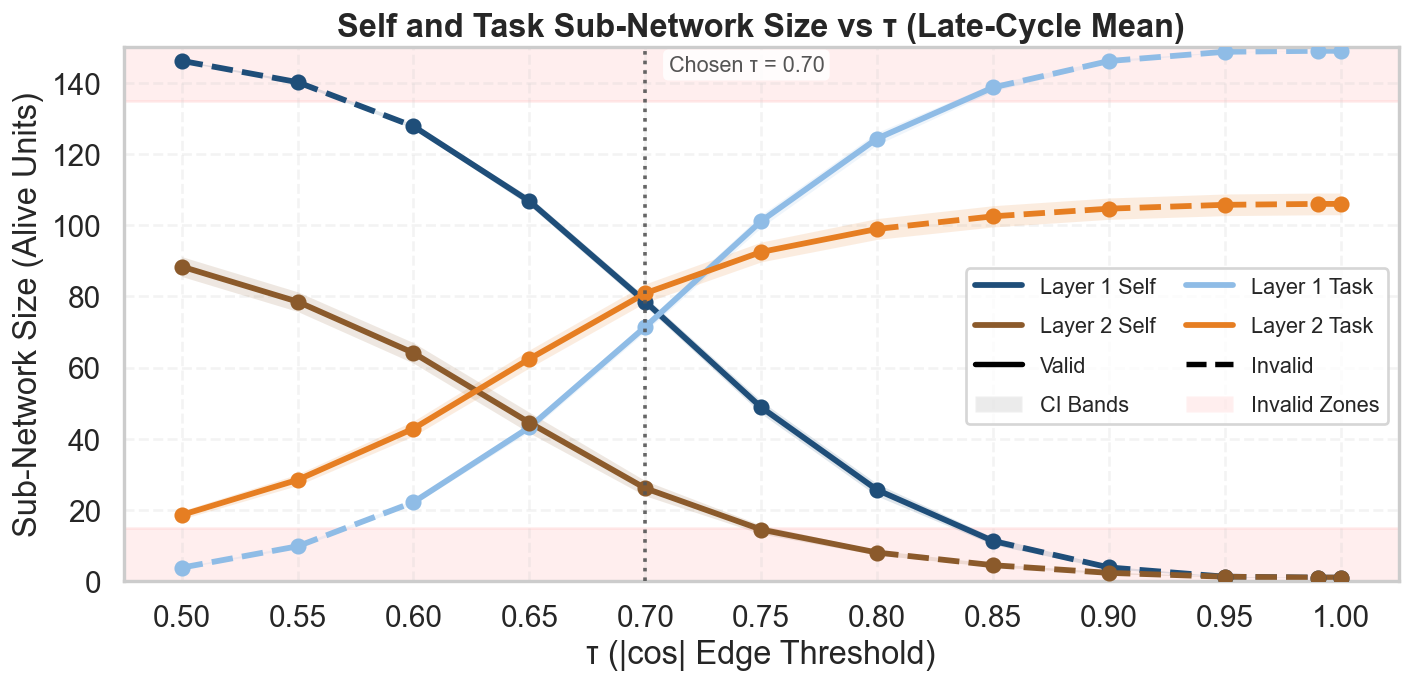

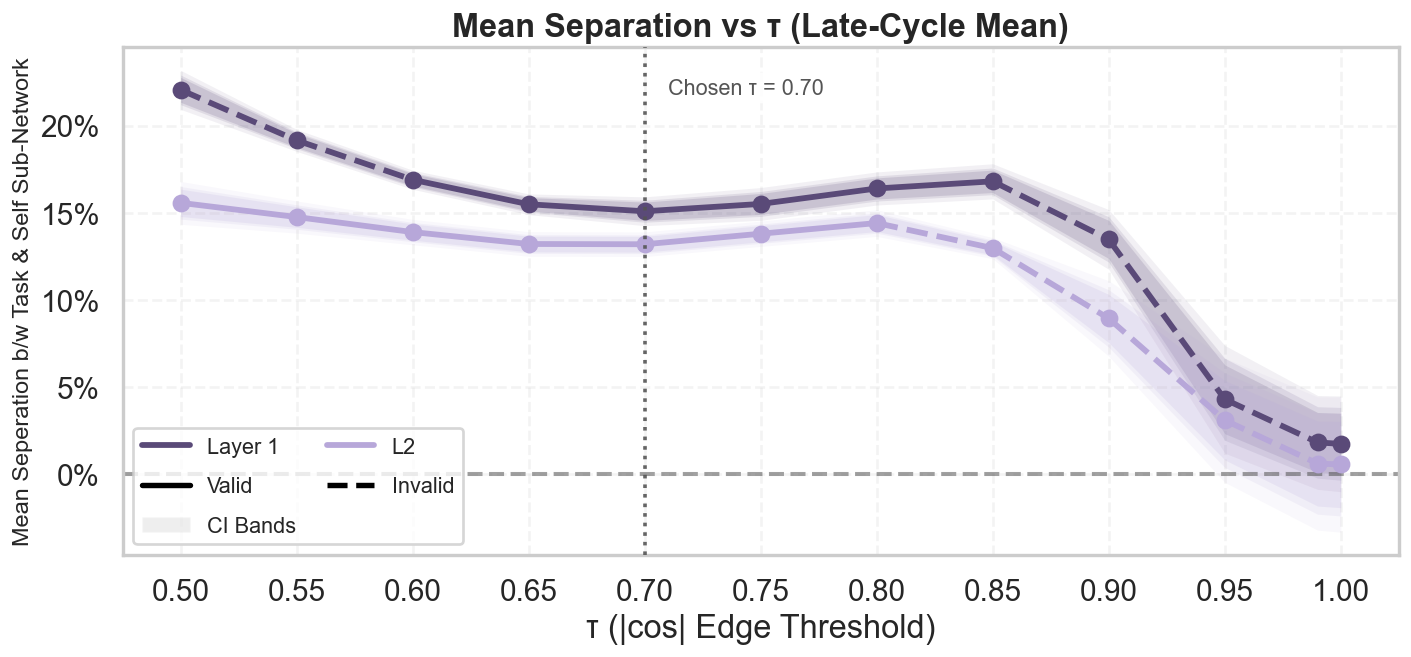

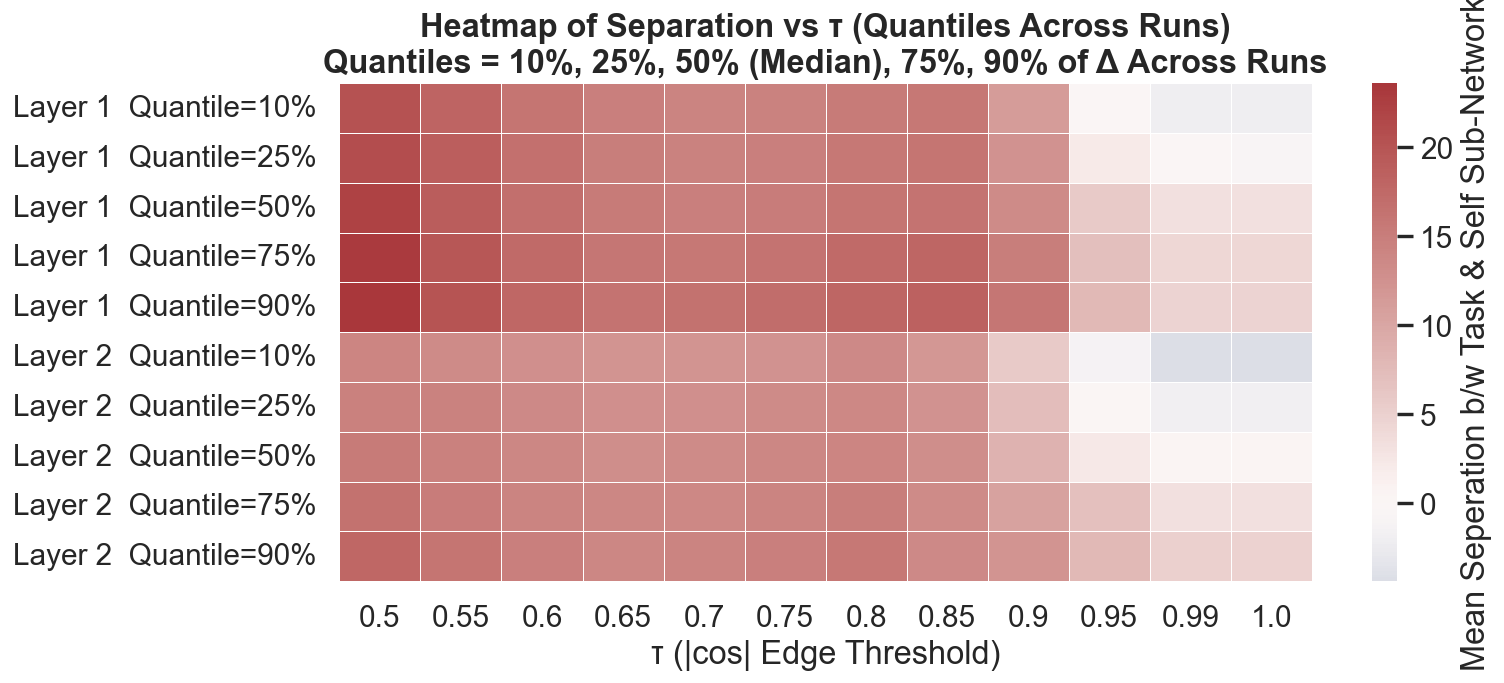


[Done]


In [10]:
# ============================================================
# ONE-CELL: TAU SWEEP FIGURES (WSJ ONLY) — SELF-CONTAINED
#
# This cell:
#   1) Loads tau sweep phase_summary.csv files from your WSJ runs
#   2) Builds df_run_tau_layer
#   3) Plots:
#        - Graph 1: Self and Task Module Size vs τ
#        - Graph 2: Mean Separation vs τ
#        - Heatmap: Separation Quantiles vs τ
#
# Requested updates applied (latest):
#   - Slightly larger graph headings (TITLE_FONTSIZE)
#   - Graph 1 legend order in rows:
#       Row 1: L1S, L1T
#       Row 2: L2S, L2T
#       Row 3: Valid, Invalid
#       Row 4: CI Band, Invalid Zones
#     (legend moved slightly down; smaller text)
#   - Graph 2 legend order/rows:
#       Row 1: L1, L2
#       Row 2: Valid, [blank]
#       Row 3: Invalid, CI Bands...
#     (legend font size = Graph 1 legend font size)
#   - Graph 2 y-axis title: "Mean Seperation Between Task and Self sub-network" (slightly smaller)
#   - Graph 3: remove "(Percentage Points)" from the colorbar label; instead show % on ticks
#     and set colorbar title to "Mean seperation between task and self sub-network"
#   - Graph 3: no chosen-τ marker/label
#   - Proper title case (not ALL CAPS) + bold titles
#   - Removes 0.99 tick if 1.00 exists
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# ============================================================
# CONFIG
# ============================================================

ROBUSTNESS_ROOT_CL = "/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu"
SWEEP_SELECT_MODE = "latest_per_run"   # "latest_per_run" or "all"
REQUIRED_BEHAVIORS = ["walk", "spin", "jump"]

LATE_START_CYCLE = 15
LATE_END_CYCLE   = 50   # exclusive

CHOSEN_TAU = 0.70

# --- Validity ---
MIN_SELF_FRAC = 0.05
MAX_SELF_FRAC = 0.92
MIN_TOTAL_FRAC = 0.90
MIN_RUN_FRAC_FOR_TAU_LAYER_VALID = 0.50

# --- Styling ---
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]

TITLE_FONTSIZE = 18  # slightly larger headings
LEGEND_FONTSIZE = 12  # Graph 1 + Graph 2 must match

# --- Graph 1 colors ---
L1_SELF = "#1F4E79"   # dark blue
L1_TASK = "#8FBCE6"   # light blue
L2_SELF = "#8B5A2B"   # brown
L2_TASK = "#E67E22"   # orange

# --- Graph 2 colors ---
SEP_L1 = "#5A4A78"
SEP_L2 = "#B7A7D9"

# --- Invalid zones for Graph 1 ---
SHOW_INVALID_ZONES = True
ZONE_COLOR = "#ff5a5a"
ZONE_ALPHA = 0.10
ZONE_LOW = (0, 15)
ZONE_HIGH = (135, 150)
SIZE_YLIM = (0, 150)

# ============================================================
# HELPERS: DISCOVERY + LOADING
# ============================================================

def _parse_sweep_datetime(sweep_name: str):
    m = re.search(r"tau_sweep_(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})", sweep_name)
    if not m:
        return None
    return f"{m.group(1)} {m.group(2).replace('-', ':')}"

def _discover_runs(root: str):
    pat = os.path.join(root, "WSJ_relu_*")
    runs = sorted([p for p in glob.glob(pat) if os.path.isdir(p)])
    if not runs:
        raise FileNotFoundError(f"No WSJ_relu_* runs found under: {root}")
    return runs

def _discover_sweeps_for_run(run_dir: str):
    sweep_parent = os.path.join(run_dir, "models", "_module_explorer_tau_sweep")
    if not os.path.isdir(sweep_parent):
        return []
    sweeps = sorted([
        p for p in glob.glob(os.path.join(sweep_parent, "tau_sweep_*"))
        if os.path.isdir(p) and ("__backup_" not in os.path.basename(p))
    ])
    return sweeps

def _select_sweeps(root: str, mode: str):
    runs = _discover_runs(root)
    chosen = []

    for rd in runs:
        sweeps = _discover_sweeps_for_run(rd)
        if not sweeps:
            continue

        if mode == "all":
            chosen.extend(sweeps)
        elif mode == "latest_per_run":
            scored = []
            for s in sweeps:
                dt = _parse_sweep_datetime(os.path.basename(s))
                scored.append((dt if dt is not None else "", s))
            scored.sort(key=lambda t: t[0])
            chosen.append(scored[-1][1])
        else:
            raise ValueError("SWEEP_SELECT_MODE must be 'latest_per_run' or 'all'")

    chosen = sorted(set(chosen))
    if not chosen:
        raise RuntimeError("No tau_sweep_* folders selected.")
    return chosen

def _run_name_from_sweep_root(sweep_root: str) -> str:
    parts = os.path.normpath(sweep_root).split(os.sep)
    for p in reversed(parts):
        if p.startswith("WSJ_relu_"):
            return p
    return os.path.basename(os.path.dirname(os.path.dirname(sweep_root)))

def _parse_cycle_num_from_cycle_id(cycle_id: str) -> int:
    m = re.search(r"(\d+)", str(cycle_id))
    return int(m.group(1)) if m else -1

def _safe_read_csv(path: str, min_bytes: int = 5):
    if not os.path.exists(path):
        return None, "missing file"
    if os.path.getsize(path) < min_bytes:
        return None, f"empty file (<{min_bytes} bytes)"
    try:
        df = pd.read_csv(path)
    except Exception as e:
        return None, f"read_csv failed: {type(e).__name__}: {e}"
    if df is None or df.shape[1] == 0:
        return None, "no columns after read"
    if len(df) == 0:
        return None, "valid header but 0 rows"
    return df, None

def load_module_rows_from_sweeps(sweep_roots, required_behaviors):
    dfs = []
    skipped = []
    req = [b.lower() for b in required_behaviors]

    for sweep_root in sweep_roots:
        run_name = _run_name_from_sweep_root(sweep_root)

        tau_dirs = sorted([p for p in glob.glob(os.path.join(sweep_root, "TAU_*")) if os.path.isdir(p)])
        if not tau_dirs:
            skipped.append((run_name, sweep_root, "no TAU_* dirs"))
            continue

        for td in tau_dirs:
            phase_csv = os.path.join(td, "phase_summary.csv")
            df, reason = _safe_read_csv(phase_csv)
            if df is None:
                skipped.append((run_name, phase_csv, reason))
                continue

            if "mean_persistence_score" in df.columns:
                SCORE_COL = "mean_persistence_score"
            elif "mean_self_score" in df.columns:
                SCORE_COL = "mean_self_score"
            elif "mean_persistence" in df.columns:
                SCORE_COL = "mean_persistence"
            else:
                skipped.append((run_name, phase_csv, "missing persistence score col"))
                continue

            need = ["tau", "behavior", "cycle_id", "layer_idx", "cluster_rank",
                    "cluster_size_neurons", "n_alive_units", SCORE_COL]
            missing = [c for c in need if c not in df.columns]
            if missing:
                skipped.append((run_name, phase_csv, f"missing cols: {missing}"))
                continue

            df = df.copy()
            df["run_name"] = df.get("run_name", run_name)
            df["run_name"] = df["run_name"].astype(str)
            df["tau"] = pd.to_numeric(df["tau"], errors="coerce")
            df["layer_idx"] = pd.to_numeric(df["layer_idx"], errors="coerce").fillna(-1).astype(int)
            df["cluster_rank"] = pd.to_numeric(df["cluster_rank"], errors="coerce").fillna(-1).astype(int)
            df["cluster_size_neurons"] = pd.to_numeric(df["cluster_size_neurons"], errors="coerce")
            df["n_alive_units"] = pd.to_numeric(df["n_alive_units"], errors="coerce")
            df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")

            df["behavior"] = df["behavior"].astype(str).str.strip().str.lower()
            df = df[df["behavior"].isin(req)].copy()
            df = df[df["cluster_rank"].isin([1, 2])].copy()
            if len(df) == 0:
                continue

            df["cycle_num"] = df["cycle_id"].apply(_parse_cycle_num_from_cycle_id).astype(int)
            df["module"] = df["cluster_rank"].map({1: "self", 2: "task"}).fillna("other")

            out = df[["run_name", "tau", "layer_idx", "behavior", "cycle_num", "module"]].copy()
            out["module_size"] = df["cluster_size_neurons"].astype(float)
            out["persistence"] = df[SCORE_COL].astype(float)
            out["n_alive_units"] = df["n_alive_units"].astype(float)
            dfs.append(out)

    if not dfs:
        raise RuntimeError("No valid module rows loaded from selected sweeps.")

    df_all = pd.concat(dfs, ignore_index=True)

    print("\n[Load]")
    print(f"  sweeps used: {len(sweep_roots)}")
    print(f"  rows loaded: {len(df_all)}")
    print(f"  runs: {df_all['run_name'].nunique()}")
    print(f"  taus: {sorted(df_all['tau'].dropna().unique().tolist())}")
    print(f"  layers: {sorted(df_all['layer_idx'].unique().tolist())}")

    if skipped:
        print(f"  skipped entries: {len(skipped)} (showing up to 8)")
        for s in skipped[:8]:
            print("   -", s)

    return df_all

# ============================================================
# BUILD df_run_tau_layer
# ============================================================

def make_cycle_level_combined(df_mod, required_behaviors):
    req = [b.lower() for b in required_behaviors]
    n_req = len(req)

    counts = (
        df_mod.groupby(["run_name", "tau", "layer_idx", "cycle_num", "module"])["behavior"]
              .nunique()
              .reset_index()
              .rename(columns={"behavior": "n_beh"})
    )
    good = counts[counts["n_beh"] == n_req][["run_name", "tau", "layer_idx", "cycle_num", "module"]]
    df = df_mod.merge(good, on=["run_name", "tau", "layer_idx", "cycle_num", "module"], how="inner").copy()

    df_cycle = (
        df.groupby(["run_name", "tau", "layer_idx", "cycle_num", "module"], as_index=False)
          .agg(
              module_size_cycle=("module_size", "mean"),
              persistence_cycle=("persistence", "mean"),
              n_alive_units_cycle=("n_alive_units", "mean"),
          )
    )
    return df_cycle

def make_late_window_per_run_tau_layer(df_cycle, late_start, late_end):
    sub = df_cycle[(df_cycle["cycle_num"] >= late_start) & (df_cycle["cycle_num"] < late_end)].copy()
    if len(sub) == 0:
        raise RuntimeError("No cycles in late window after completeness filtering.")

    df_late_mod = (
        sub.groupby(["run_name", "tau", "layer_idx", "module"], as_index=False)
           .agg(
               mean_size=("module_size_cycle", "mean"),
               mean_persistence=("persistence_cycle", "mean"),
               mean_alive=("n_alive_units_cycle", "mean"),
               n_cycles=("cycle_num", "nunique"),
           )
    )

    wide_size = df_late_mod.pivot_table(
        index=["run_name", "tau", "layer_idx"], columns="module", values="mean_size", aggfunc="mean"
    )
    wide_pers = df_late_mod.pivot_table(
        index=["run_name", "tau", "layer_idx"], columns="module", values="mean_persistence", aggfunc="mean"
    )
    wide_alive = df_late_mod.pivot_table(
        index=["run_name", "tau", "layer_idx"], columns="module", values="mean_alive", aggfunc="mean"
    )

    out = pd.DataFrame(index=wide_size.index).reset_index()
    out["self_size"] = wide_size.get("self", np.nan).to_numpy()
    out["task_size"] = wide_size.get("task", np.nan).to_numpy()
    out["self_persistence"] = wide_pers.get("self", np.nan).to_numpy()
    out["task_persistence"] = wide_pers.get("task", np.nan).to_numpy()
    out["separation_persistence"] = out["self_persistence"] - out["task_persistence"]

    a_self = wide_alive.get("self", np.nan).to_numpy()
    a_task = wide_alive.get("task", np.nan).to_numpy()
    out["alive_units"] = np.nanmean(np.stack([a_self, a_task], axis=0), axis=0)

    out = out.dropna(subset=["self_size", "task_size", "self_persistence", "task_persistence", "alive_units"]).copy()
    return out

# ============================================================
# VALIDITY
# ============================================================

def _compute_valid_row_mask(df: pd.DataFrame) -> pd.Series:
    alive = pd.to_numeric(df["alive_units"], errors="coerce").to_numpy(float)
    self_sz = pd.to_numeric(df["self_size"], errors="coerce").to_numpy(float)
    task_sz = pd.to_numeric(df["task_size"], errors="coerce").to_numpy(float)

    alive = np.where(np.isfinite(alive) & (alive > 0), alive, np.nan)
    self_frac = self_sz / alive
    total_frac = (self_sz + task_sz) / alive

    valid = (
        np.isfinite(self_frac) & np.isfinite(total_frac) &
        (self_frac >= MIN_SELF_FRAC) & (self_frac <= MAX_SELF_FRAC) &
        (total_frac >= MIN_TOTAL_FRAC)
    )
    return pd.Series(valid, index=df.index)

def _valid_tau_layer_majority(df: pd.DataFrame, valid_row_mask: pd.Series, thr: float = MIN_RUN_FRAC_FOR_TAU_LAYER_VALID) -> pd.DataFrame:
    tmp = df.copy()
    tmp["valid_row"] = valid_row_mask.values
    frac = (
        tmp.groupby(["tau", "layer_idx"], as_index=False)["valid_row"]
           .mean()
           .rename(columns={"valid_row": "frac_valid"})
    )
    frac["valid_tau_layer"] = frac["frac_valid"] >= float(thr)
    return frac

# ============================================================
# PLOTTING HELPERS
# ============================================================

def _layer_disp(layer_idx: int) -> int:
    return int(layer_idx) + 1

def _segment_plot(ax, x, y, valid, color, lw=3.0):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    valid = np.asarray(valid, bool)
    for i in range(len(x) - 1):
        seg_valid = bool(valid[i] and valid[i + 1])
        ls = "-" if seg_valid else "--"
        ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=lw, linestyle=ls)

def _agg_mean_ci(df: pd.DataFrame, value_col: str, alpha_two_sided: float, group_cols=("tau", "layer_idx")):
    z = float(stats.norm.ppf(1 - alpha_two_sided / 2))
    rows = []
    for keys, sub in df.groupby(list(group_cols)):
        x = pd.to_numeric(sub[value_col], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]
        n = int(x.size)
        if n == 0:
            continue
        mu = float(np.mean(x))
        sd = float(np.std(x, ddof=1)) if n >= 2 else 0.0
        se = sd / np.sqrt(n) if (n >= 2 and sd > 0) else 0.0
        ci = z * se if se > 0 else 0.0
        rec = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        rec.update({"mean": mu, "ci": ci, "n": n})
        rows.append(rec)
    return pd.DataFrame(rows)

def _add_chosen_tau_marker_data(ax, y_at, dx=0.01):
    ax.axvline(CHOSEN_TAU, linestyle=":", linewidth=2.0, color="#555555", alpha=0.9, zorder=4)
    ax.text(
        CHOSEN_TAU + dx, y_at, f"Chosen τ = {CHOSEN_TAU:.2f}",
        ha="left", va="center", fontsize=12, color="#555555",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
        zorder=5
    )

def _clean_tau_ticks(taus):
    taus = sorted([float(t) for t in taus])
    has_099 = any(np.isclose(t, 0.99) for t in taus)
    has_100 = any(np.isclose(t, 1.00) for t in taus)
    if has_099 and has_100:
        taus = [t for t in taus if not np.isclose(t, 0.99)]
    return taus

# ============================================================
# GRAPH 1: MODULE SIZE VS τ
# ============================================================

def plot_module_sizes_vs_tau(df_run_tau_layer: pd.DataFrame):
    df = df_run_tau_layer.copy()
    valid_row = _compute_valid_row_mask(df)
    valid_tau_layer = _valid_tau_layer_majority(df, valid_row)

    agg_self = _agg_mean_ci(df, "self_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
    agg_self["module"] = "self"
    agg_task = _agg_mean_ci(df, "task_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
    agg_task["module"] = "task"
    agg = pd.concat([agg_self, agg_task], ignore_index=True)

    agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
    agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

    taus = _clean_tau_ticks(agg["tau"].unique().tolist())

    fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.6))

    if SHOW_INVALID_ZONES:
        ax.axhspan(ZONE_LOW[0], ZONE_LOW[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)
        ax.axhspan(ZONE_HIGH[0], ZONE_HIGH[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)

    def color_for(L, module):
        if L == 0:
            return L1_SELF if module == "self" else L1_TASK
        return L2_SELF if module == "self" else L2_TASK

    for L in [0, 1]:
        for module in ["self", "task"]:
            sub = agg[(agg["layer_idx"] == L) & (agg["module"] == module)].sort_values("tau")
            if len(sub) == 0:
                continue

            x = sub["tau"].to_numpy(float)
            y = sub["mean"].to_numpy(float)
            ci = sub["ci"].to_numpy(float)
            v = sub["valid_tau_layer"].to_numpy(bool)
            c = color_for(L, module)

            ax.fill_between(x, y - ci, y + ci, color=c, alpha=0.14, linewidth=0, zorder=1)
            _segment_plot(ax, x, y, v, color=c, lw=3.2)
            ax.scatter(x, y, s=55, color=c, zorder=3)

    ax.set_title("Self and Task Sub-Network Size vs τ (Late-Cycle Mean)", fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("τ (|cos| Edge Threshold)")
    ax.set_ylabel("Sub-Network Size (Alive Units)")
    ax.set_xticks(taus)
    ax.set_ylim(SIZE_YLIM)
    ax.grid(True, alpha=0.22, linestyle="--")

    _add_chosen_tau_marker_data(ax, y_at=145, dx=0.01)

    # Row 1: L1S, L1T
    # Row 2: L2S, L2T
    # Row 3: Valid, Invalid
    # Row 4: CI Band, Invalid Zones
    legend_items = [
        Line2D([0], [0], color=L1_SELF, lw=3.2, label="Layer 1 Self"),
        Line2D([0], [0], color=L2_SELF, lw=3.2, label="Layer 2 Self"),
        Line2D([0], [0], color="black", lw=3, linestyle="-", label="Valid"),
        Patch(facecolor="#777777", alpha=0.14, label="CI Bands"),
        Line2D([0], [0], color=L1_TASK, lw=3.2, label="Layer 1 Task"),
        Line2D([0], [0], color=L2_TASK, lw=3.2, label="Layer 2 Task"),
        Line2D([0], [0], color="black", lw=3, linestyle="--", label="Invalid"),
        Patch(facecolor=ZONE_COLOR, alpha=ZONE_ALPHA, label="Invalid Zones"),
    ]
    ax.legend(
        handles=legend_items,
        frameon=True,
        ncol=2,
        loc="center right",
        bbox_to_anchor=(1.0, 0.44),  # slightly lower
        columnspacing=1.4,
        handlelength=2.2,
        labelspacing=0.9,
        fontsize=LEGEND_FONTSIZE
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# GRAPH 2: MEAN SEPARATION VS τ
# ============================================================

def plot_mean_delta_vs_tau_with_bands(df_run_tau_layer: pd.DataFrame):
    df = df_run_tau_layer.copy()
    valid_row = _compute_valid_row_mask(df)
    valid_tau_layer = _valid_tau_layer_majority(df, valid_row)

    df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

    agg90 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.10, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci90"})
    agg95 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.05, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci95"})
    agg99 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.01, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci99"})

    agg = agg95.merge(agg90[["tau", "layer_idx", "ci90"]], on=["tau", "layer_idx"], how="left")
    agg = agg.merge(agg99[["tau", "layer_idx", "ci99"]], on=["tau", "layer_idx"], how="left")
    agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
    agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

    taus = _clean_tau_ticks(agg["tau"].unique().tolist())

    fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.4))

    def layer_color(L):
        return SEP_L1 if L == 0 else SEP_L2

    for L in [0, 1]:
        sub = agg[agg["layer_idx"] == L].sort_values("tau")
        if len(sub) == 0:
            continue

        x = sub["tau"].to_numpy(float)
        y = sub["mean"].to_numpy(float)
        v = sub["valid_tau_layer"].to_numpy(bool)
        c = layer_color(L)

        ci90 = sub["ci90"].to_numpy(float)
        ci95 = sub["ci95"].to_numpy(float)
        ci99 = sub["ci99"].to_numpy(float)

        ax.fill_between(x, y - ci99, y + ci99, color=c, alpha=0.08, linewidth=0, zorder=1)
        ax.fill_between(x, y - ci95, y + ci95, color=c, alpha=0.12, linewidth=0, zorder=1)
        ax.fill_between(x, y - ci90, y + ci90, color=c, alpha=0.16, linewidth=0, zorder=1)

        _segment_plot(ax, x, y, v, color=c, lw=3.2)
        ax.scatter(x, y, s=70, color=c, zorder=3)

    ax.axhline(0.0, linestyle="--", alpha=0.55, color="#555555")
    ax.set_title("Mean Separation vs τ (Late-Cycle Mean)", fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("τ (|cos| Edge Threshold)")
    ax.set_ylabel("Mean Seperation b/w Task & Self Sub-Network", fontsize=13)
    ax.set_xticks(taus)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
    ax.grid(True, alpha=0.22, linestyle="--")

    y0, y1 = ax.get_ylim()
    y_label = y1 - 0.08 * (y1 - y0)
    _add_chosen_tau_marker_data(ax, y_at=y_label, dx=0.01)

    dummy = Line2D([0], [0], linestyle="None", linewidth=0, alpha=0, label="")

    # Row 1: L1, L2
    # Row 2: Valid, [blank]
    # Row 3: Invalid, CI Bands...
    legend_items = [
        Line2D([0], [0], color=SEP_L1, lw=3.2, label="Layer 1"),
        Line2D([0], [0], color="black", lw=3, linestyle="-", label="Valid"),
        Patch(facecolor="#777777", alpha=0.12, label="CI Bands"),
        Line2D([0], [0], color=SEP_L2, lw=3.2, label="L2"),
        Line2D([0], [0], color="black", lw=3, linestyle="--", label="Invalid"),

    ]
    ax.legend(
        handles=legend_items,
        frameon=True,
        ncol=2,
        loc="lower left",
        columnspacing=1.4,
        handlelength=2.2,
        labelspacing=0.9,
        fontsize=LEGEND_FONTSIZE
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# GRAPH 3: HEATMAP
# ============================================================

def plot_delta_quantile_heatmap(df_run_tau_layer: pd.DataFrame):
    df = df_run_tau_layer.copy()
    df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

    quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

    rows = []
    for (tau, L), sub in df.groupby(["tau", "layer_idx"]):
        x = pd.to_numeric(sub["delta_pp"], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            continue
        for q in quantiles:
            rows.append({
                "tau": float(tau),
                "y_label": f"Layer {_layer_disp(L)}  Quantile={int(round(100*q))}%",
                "value": float(np.quantile(x, q)),
            })

    hm = pd.DataFrame(rows)
    if len(hm) == 0:
        print("[warn] No data for heatmap.")
        return

    pivot = hm.pivot_table(index="y_label", columns="tau", values="value", aggfunc="mean")

    y_order = []
    for L in [1, 2]:
        for q in quantiles:
            y_order.append(f"Layer {L}  Quantile={int(round(100*q))}%")
    pivot = pivot.reindex(y_order)

    fig, ax = plt.subplots(1, 1, figsize=(12.4, 5.6))
    hm_ax = sns.heatmap(
        pivot,
        cmap="vlag",
        center=0.0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean Seperation b/w Task & Self Sub-Network"},
        ax=ax
    )

    ax.set_title(
        "Heatmap of Separation vs τ (Quantiles Across Runs)\n"
        "Quantiles = 10%, 25%, 50% (Median), 75%, 90% of Δ Across Runs",
        fontsize=TITLE_FONTSIZE,
        fontweight="bold"
    )
    ax.set_xlabel("τ (|cos| Edge Threshold)")
    ax.set_ylabel("")

    # Add % directly to colorbar tick numbers
    cbar = hm_ax.collections[0].colorbar
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
    cbar.update_ticks()

    # Requested: no chosen-τ marker/label on Graph 3

    plt.tight_layout()
    plt.show()

# ============================================================
# RUN
# ============================================================

if not os.path.isdir(ROBUSTNESS_ROOT_CL):
    raise FileNotFoundError(f"ROBUSTNESS_ROOT_CL not found: {ROBUSTNESS_ROOT_CL}")

sweep_roots = _select_sweeps(ROBUSTNESS_ROOT_CL, SWEEP_SELECT_MODE)

print("\n[Sweeps Selected]")
for s in sweep_roots:
    print("  -", s)

df_mod = load_module_rows_from_sweeps(sweep_roots, REQUIRED_BEHAVIORS)
df_cycle = make_cycle_level_combined(df_mod, REQUIRED_BEHAVIORS)

print("\n[Cycle-Level]")
print(f"  rows: {len(df_cycle)} | runs: {df_cycle['run_name'].nunique()} | taus: {df_cycle['tau'].nunique()} | layers: {df_cycle['layer_idx'].nunique()}")

df_run_tau_layer = make_late_window_per_run_tau_layer(df_cycle, LATE_START_CYCLE, LATE_END_CYCLE)

print("\n[Late Window]")
print(f"  cycles in [{LATE_START_CYCLE}, {LATE_END_CYCLE})")
print(f"  rows: {len(df_run_tau_layer)}")
print(f"  runs: {df_run_tau_layer['run_name'].nunique()} | taus: {df_run_tau_layer['tau'].nunique()} | layers: {df_run_tau_layer['layer_idx'].nunique()}")

req_cols = ["tau", "layer_idx", "self_size", "task_size", "alive_units", "separation_persistence"]
missing = [c for c in req_cols if c not in df_run_tau_layer.columns]
if missing:
    raise ValueError(f"df_run_tau_layer missing required columns: {missing}")

valid_row_mask = _compute_valid_row_mask(df_run_tau_layer)
valid_tau_layer = _valid_tau_layer_majority(df_run_tau_layer, valid_row_mask)

print("\n[Validity]")
print(f"  kept rows: {int(valid_row_mask.sum())}/{len(valid_row_mask)} ({100.0 * valid_row_mask.mean():.1f}%)")
for L in sorted(valid_tau_layer["layer_idx"].unique()):
    good = sorted(valid_tau_layer[(valid_tau_layer["layer_idx"] == L) & (valid_tau_layer["valid_tau_layer"])]["tau"].tolist())
    print(f"  layer {int(L)} valid taus: {good}")

plot_module_sizes_vs_tau(df_run_tau_layer)
plot_mean_delta_vs_tau_with_bands(df_run_tau_layer)
plot_delta_quantile_heatmap(df_run_tau_layer)

print("\n[Done]")


[Sweeps Selected]
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_0_2026-01-30_23-20-32/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_22-01-06
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_1_2026-01-30_23-24-17/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_22-23-13
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_22-47-27
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_3_2026-01-30_23-24-53/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_23-08-26
  - /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_4_2026-01-30_23-28-22/models/_module_explorer_tau_sweep/tau_sweep_2026-02-25_23-31-02
  - /Users/adi/Desktop/EmergentRobotSelf/

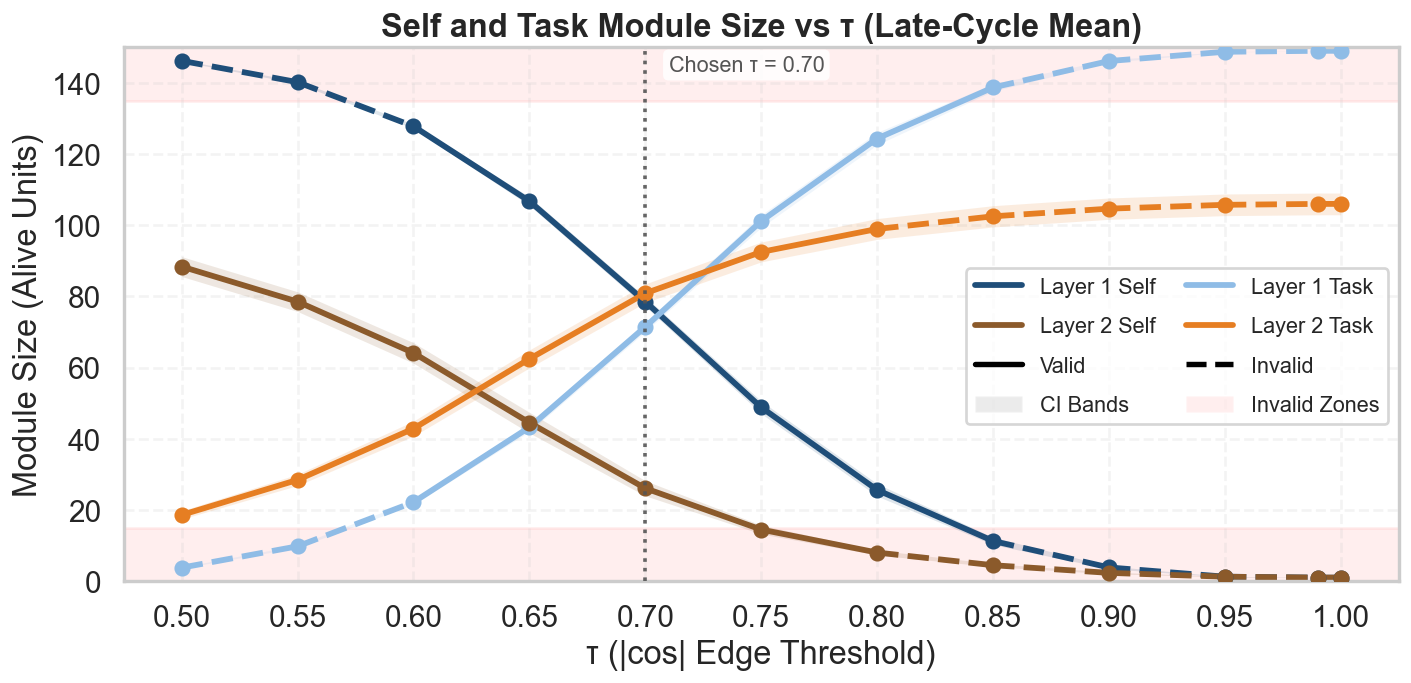

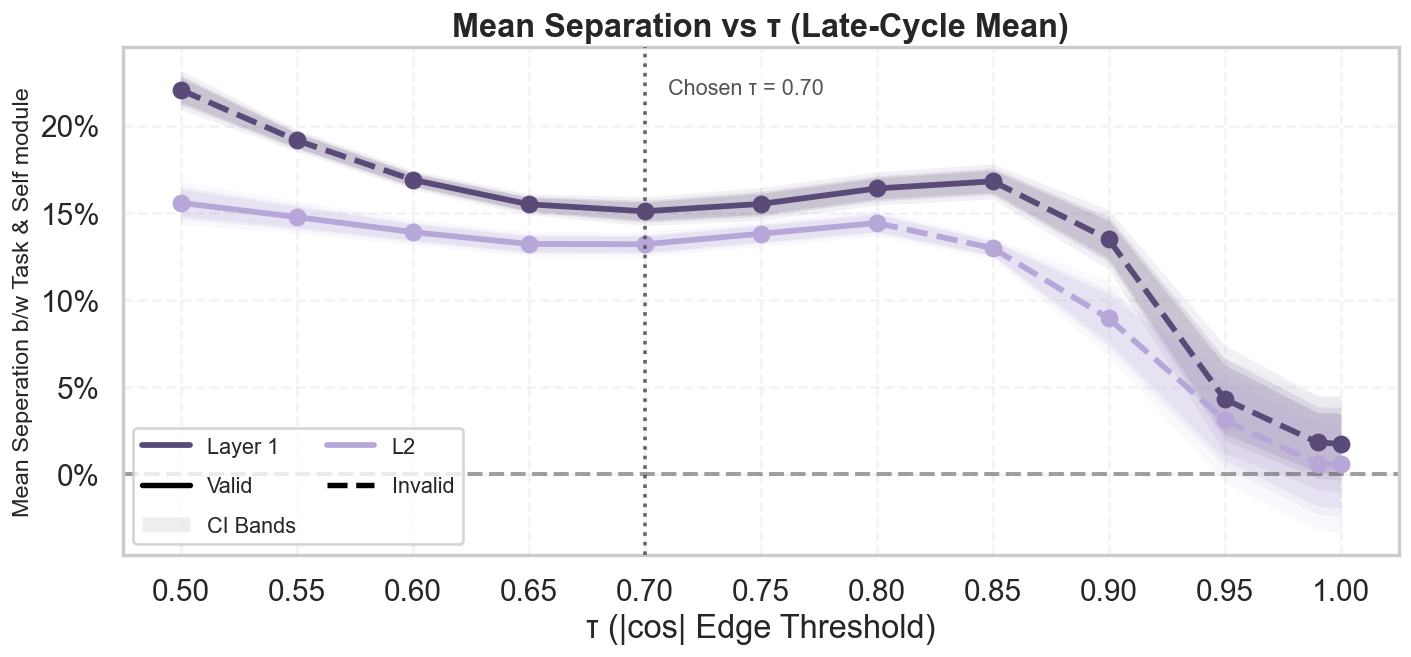

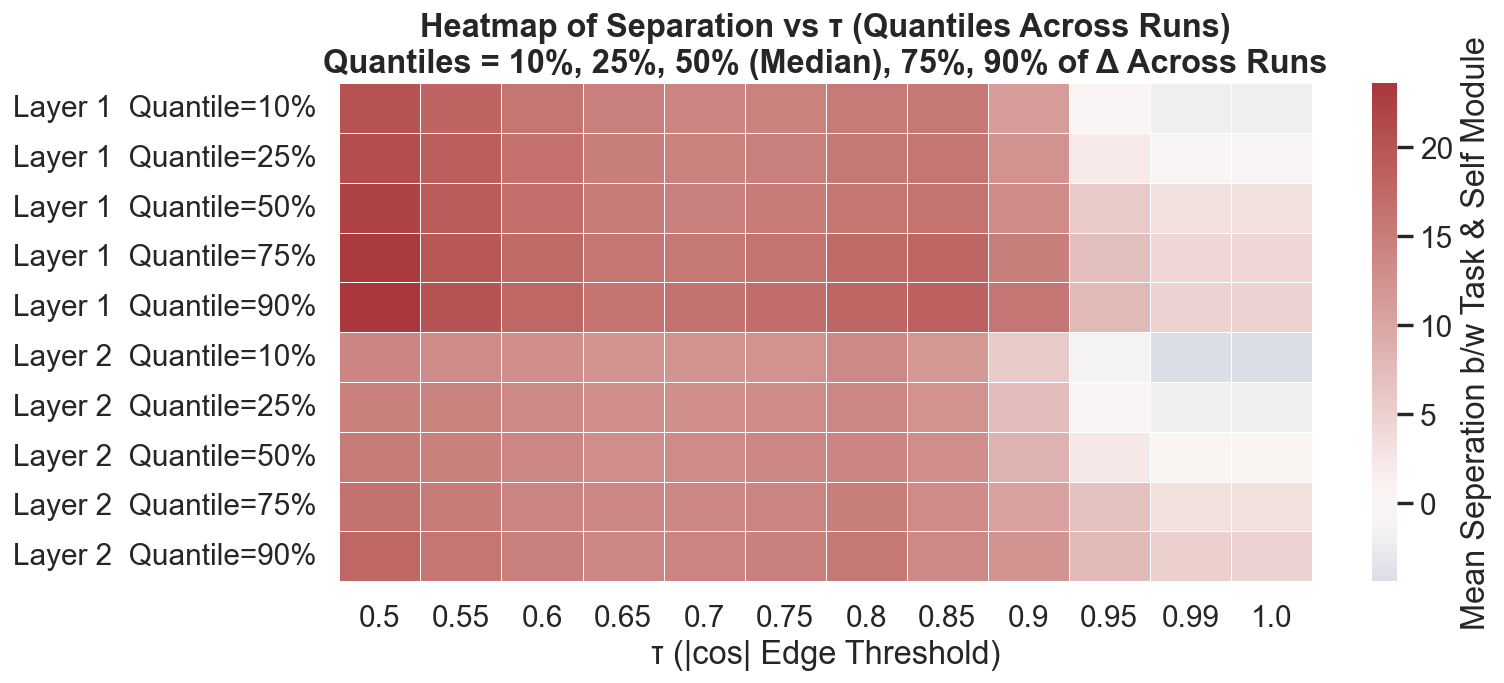


[Done]


In [1]:
# ============================================================
# ONE-CELL: TAU SWEEP FIGURES (WSJ ONLY) — SELF-CONTAINED
#
# This cell:
#   1) Loads tau sweep phase_summary.csv files from your WSJ runs
#   2) Builds df_run_tau_layer
#   3) Plots:
#        - Graph 1: Self and Task Module Size vs τ
#        - Graph 2: Mean Separation vs τ
#        - Heatmap: Separation Quantiles vs τ
#
# Requested updates applied (latest):
#   - Slightly larger graph headings (TITLE_FONTSIZE)
#   - Graph 1 legend order in rows:
#       Row 1: L1S, L1T
#       Row 2: L2S, L2T
#       Row 3: Valid, Invalid
#       Row 4: CI Band, Invalid Zones
#     (legend moved slightly down; smaller text)
#   - Graph 2 legend order/rows:
#       Row 1: L1, L2
#       Row 2: Valid, [blank]
#       Row 3: Invalid, CI Bands...
#     (legend font size = Graph 1 legend font size)
#   - Graph 2 y-axis title: "Mean Seperation Between Task and Self module" (slightly smaller)
#   - Graph 3: remove "(Percentage Points)" from the colorbar label; instead show % on ticks
#     and set colorbar title to "Mean seperation between task and self module"
#   - Graph 3: no chosen-τ marker/label
#   - Proper title case (not ALL CAPS) + bold titles
#   - Removes 0.99 tick if 1.00 exists
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# ============================================================
# CONFIG
# ============================================================

ROBUSTNESS_ROOT_CL = "/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu"
SWEEP_SELECT_MODE = "latest_per_run"   # "latest_per_run" or "all"
REQUIRED_BEHAVIORS = ["walk", "spin", "jump"]

LATE_START_CYCLE = 15
LATE_END_CYCLE   = 50   # exclusive

CHOSEN_TAU = 0.70

# --- Validity ---
MIN_SELF_FRAC = 0.05
MAX_SELF_FRAC = 0.92
MIN_TOTAL_FRAC = 0.90
MIN_RUN_FRAC_FOR_TAU_LAYER_VALID = 0.50

# --- Styling ---
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]

TITLE_FONTSIZE = 18  # slightly larger headings
LEGEND_FONTSIZE = 12  # Graph 1 + Graph 2 must match

# --- Graph 1 colors ---
L1_SELF = "#1F4E79"   # dark blue
L1_TASK = "#8FBCE6"   # light blue
L2_SELF = "#8B5A2B"   # brown
L2_TASK = "#E67E22"   # orange

# --- Graph 2 colors ---
SEP_L1 = "#5A4A78"
SEP_L2 = "#B7A7D9"

# --- Invalid zones for Graph 1 ---
SHOW_INVALID_ZONES = True
ZONE_COLOR = "#ff5a5a"
ZONE_ALPHA = 0.10
ZONE_LOW = (0, 15)
ZONE_HIGH = (135, 150)
SIZE_YLIM = (0, 150)

# ============================================================
# HELPERS: DISCOVERY + LOADING
# ============================================================

def _parse_sweep_datetime(sweep_name: str):
    m = re.search(r"tau_sweep_(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})", sweep_name)
    if not m:
        return None
    return f"{m.group(1)} {m.group(2).replace('-', ':')}"

def _discover_runs(root: str):
    pat = os.path.join(root, "WSJ_relu_*")
    runs = sorted([p for p in glob.glob(pat) if os.path.isdir(p)])
    if not runs:
        raise FileNotFoundError(f"No WSJ_relu_* runs found under: {root}")
    return runs

def _discover_sweeps_for_run(run_dir: str):
    sweep_parent = os.path.join(run_dir, "models", "_module_explorer_tau_sweep")
    if not os.path.isdir(sweep_parent):
        return []
    sweeps = sorted([
        p for p in glob.glob(os.path.join(sweep_parent, "tau_sweep_*"))
        if os.path.isdir(p) and ("__backup_" not in os.path.basename(p))
    ])
    return sweeps

def _select_sweeps(root: str, mode: str):
    runs = _discover_runs(root)
    chosen = []

    for rd in runs:
        sweeps = _discover_sweeps_for_run(rd)
        if not sweeps:
            continue

        if mode == "all":
            chosen.extend(sweeps)
        elif mode == "latest_per_run":
            scored = []
            for s in sweeps:
                dt = _parse_sweep_datetime(os.path.basename(s))
                scored.append((dt if dt is not None else "", s))
            scored.sort(key=lambda t: t[0])
            chosen.append(scored[-1][1])
        else:
            raise ValueError("SWEEP_SELECT_MODE must be 'latest_per_run' or 'all'")

    chosen = sorted(set(chosen))
    if not chosen:
        raise RuntimeError("No tau_sweep_* folders selected.")
    return chosen

def _run_name_from_sweep_root(sweep_root: str) -> str:
    parts = os.path.normpath(sweep_root).split(os.sep)
    for p in reversed(parts):
        if p.startswith("WSJ_relu_"):
            return p
    return os.path.basename(os.path.dirname(os.path.dirname(sweep_root)))

def _parse_cycle_num_from_cycle_id(cycle_id: str) -> int:
    m = re.search(r"(\d+)", str(cycle_id))
    return int(m.group(1)) if m else -1

def _safe_read_csv(path: str, min_bytes: int = 5):
    if not os.path.exists(path):
        return None, "missing file"
    if os.path.getsize(path) < min_bytes:
        return None, f"empty file (<{min_bytes} bytes)"
    try:
        df = pd.read_csv(path)
    except Exception as e:
        return None, f"read_csv failed: {type(e).__name__}: {e}"
    if df is None or df.shape[1] == 0:
        return None, "no columns after read"
    if len(df) == 0:
        return None, "valid header but 0 rows"
    return df, None

def load_module_rows_from_sweeps(sweep_roots, required_behaviors):
    dfs = []
    skipped = []
    req = [b.lower() for b in required_behaviors]

    for sweep_root in sweep_roots:
        run_name = _run_name_from_sweep_root(sweep_root)

        tau_dirs = sorted([p for p in glob.glob(os.path.join(sweep_root, "TAU_*")) if os.path.isdir(p)])
        if not tau_dirs:
            skipped.append((run_name, sweep_root, "no TAU_* dirs"))
            continue

        for td in tau_dirs:
            phase_csv = os.path.join(td, "phase_summary.csv")
            df, reason = _safe_read_csv(phase_csv)
            if df is None:
                skipped.append((run_name, phase_csv, reason))
                continue

            if "mean_persistence_score" in df.columns:
                SCORE_COL = "mean_persistence_score"
            elif "mean_self_score" in df.columns:
                SCORE_COL = "mean_self_score"
            elif "mean_persistence" in df.columns:
                SCORE_COL = "mean_persistence"
            else:
                skipped.append((run_name, phase_csv, "missing persistence score col"))
                continue

            need = ["tau", "behavior", "cycle_id", "layer_idx", "cluster_rank",
                    "cluster_size_neurons", "n_alive_units", SCORE_COL]
            missing = [c for c in need if c not in df.columns]
            if missing:
                skipped.append((run_name, phase_csv, f"missing cols: {missing}"))
                continue

            df = df.copy()
            df["run_name"] = df.get("run_name", run_name)
            df["run_name"] = df["run_name"].astype(str)
            df["tau"] = pd.to_numeric(df["tau"], errors="coerce")
            df["layer_idx"] = pd.to_numeric(df["layer_idx"], errors="coerce").fillna(-1).astype(int)
            df["cluster_rank"] = pd.to_numeric(df["cluster_rank"], errors="coerce").fillna(-1).astype(int)
            df["cluster_size_neurons"] = pd.to_numeric(df["cluster_size_neurons"], errors="coerce")
            df["n_alive_units"] = pd.to_numeric(df["n_alive_units"], errors="coerce")
            df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")

            df["behavior"] = df["behavior"].astype(str).str.strip().str.lower()
            df = df[df["behavior"].isin(req)].copy()
            df = df[df["cluster_rank"].isin([1, 2])].copy()
            if len(df) == 0:
                continue

            df["cycle_num"] = df["cycle_id"].apply(_parse_cycle_num_from_cycle_id).astype(int)
            df["module"] = df["cluster_rank"].map({1: "self", 2: "task"}).fillna("other")

            out = df[["run_name", "tau", "layer_idx", "behavior", "cycle_num", "module"]].copy()
            out["module_size"] = df["cluster_size_neurons"].astype(float)
            out["persistence"] = df[SCORE_COL].astype(float)
            out["n_alive_units"] = df["n_alive_units"].astype(float)
            dfs.append(out)

    if not dfs:
        raise RuntimeError("No valid module rows loaded from selected sweeps.")

    df_all = pd.concat(dfs, ignore_index=True)

    print("\n[Load]")
    print(f"  sweeps used: {len(sweep_roots)}")
    print(f"  rows loaded: {len(df_all)}")
    print(f"  runs: {df_all['run_name'].nunique()}")
    print(f"  taus: {sorted(df_all['tau'].dropna().unique().tolist())}")
    print(f"  layers: {sorted(df_all['layer_idx'].unique().tolist())}")

    if skipped:
        print(f"  skipped entries: {len(skipped)} (showing up to 8)")
        for s in skipped[:8]:
            print("   -", s)

    return df_all

# ============================================================
# BUILD df_run_tau_layer
# ============================================================

def make_cycle_level_combined(df_mod, required_behaviors):
    req = [b.lower() for b in required_behaviors]
    n_req = len(req)

    counts = (
        df_mod.groupby(["run_name", "tau", "layer_idx", "cycle_num", "module"])["behavior"]
              .nunique()
              .reset_index()
              .rename(columns={"behavior": "n_beh"})
    )
    good = counts[counts["n_beh"] == n_req][["run_name", "tau", "layer_idx", "cycle_num", "module"]]
    df = df_mod.merge(good, on=["run_name", "tau", "layer_idx", "cycle_num", "module"], how="inner").copy()

    df_cycle = (
        df.groupby(["run_name", "tau", "layer_idx", "cycle_num", "module"], as_index=False)
          .agg(
              module_size_cycle=("module_size", "mean"),
              persistence_cycle=("persistence", "mean"),
              n_alive_units_cycle=("n_alive_units", "mean"),
          )
    )
    return df_cycle

def make_late_window_per_run_tau_layer(df_cycle, late_start, late_end):
    sub = df_cycle[(df_cycle["cycle_num"] >= late_start) & (df_cycle["cycle_num"] < late_end)].copy()
    if len(sub) == 0:
        raise RuntimeError("No cycles in late window after completeness filtering.")

    df_late_mod = (
        sub.groupby(["run_name", "tau", "layer_idx", "module"], as_index=False)
           .agg(
               mean_size=("module_size_cycle", "mean"),
               mean_persistence=("persistence_cycle", "mean"),
               mean_alive=("n_alive_units_cycle", "mean"),
               n_cycles=("cycle_num", "nunique"),
           )
    )

    wide_size = df_late_mod.pivot_table(
        index=["run_name", "tau", "layer_idx"], columns="module", values="mean_size", aggfunc="mean"
    )
    wide_pers = df_late_mod.pivot_table(
        index=["run_name", "tau", "layer_idx"], columns="module", values="mean_persistence", aggfunc="mean"
    )
    wide_alive = df_late_mod.pivot_table(
        index=["run_name", "tau", "layer_idx"], columns="module", values="mean_alive", aggfunc="mean"
    )

    out = pd.DataFrame(index=wide_size.index).reset_index()
    out["self_size"] = wide_size.get("self", np.nan).to_numpy()
    out["task_size"] = wide_size.get("task", np.nan).to_numpy()
    out["self_persistence"] = wide_pers.get("self", np.nan).to_numpy()
    out["task_persistence"] = wide_pers.get("task", np.nan).to_numpy()
    out["separation_persistence"] = out["self_persistence"] - out["task_persistence"]

    a_self = wide_alive.get("self", np.nan).to_numpy()
    a_task = wide_alive.get("task", np.nan).to_numpy()
    out["alive_units"] = np.nanmean(np.stack([a_self, a_task], axis=0), axis=0)

    out = out.dropna(subset=["self_size", "task_size", "self_persistence", "task_persistence", "alive_units"]).copy()
    return out

# ============================================================
# VALIDITY
# ============================================================

def _compute_valid_row_mask(df: pd.DataFrame) -> pd.Series:
    alive = pd.to_numeric(df["alive_units"], errors="coerce").to_numpy(float)
    self_sz = pd.to_numeric(df["self_size"], errors="coerce").to_numpy(float)
    task_sz = pd.to_numeric(df["task_size"], errors="coerce").to_numpy(float)

    alive = np.where(np.isfinite(alive) & (alive > 0), alive, np.nan)
    self_frac = self_sz / alive
    total_frac = (self_sz + task_sz) / alive

    valid = (
        np.isfinite(self_frac) & np.isfinite(total_frac) &
        (self_frac >= MIN_SELF_FRAC) & (self_frac <= MAX_SELF_FRAC) &
        (total_frac >= MIN_TOTAL_FRAC)
    )
    return pd.Series(valid, index=df.index)

def _valid_tau_layer_majority(df: pd.DataFrame, valid_row_mask: pd.Series, thr: float = MIN_RUN_FRAC_FOR_TAU_LAYER_VALID) -> pd.DataFrame:
    tmp = df.copy()
    tmp["valid_row"] = valid_row_mask.values
    frac = (
        tmp.groupby(["tau", "layer_idx"], as_index=False)["valid_row"]
           .mean()
           .rename(columns={"valid_row": "frac_valid"})
    )
    frac["valid_tau_layer"] = frac["frac_valid"] >= float(thr)
    return frac

# ============================================================
# PLOTTING HELPERS
# ============================================================

def _layer_disp(layer_idx: int) -> int:
    return int(layer_idx) + 1

def _segment_plot(ax, x, y, valid, color, lw=3.0):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    valid = np.asarray(valid, bool)
    for i in range(len(x) - 1):
        seg_valid = bool(valid[i] and valid[i + 1])
        ls = "-" if seg_valid else "--"
        ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=lw, linestyle=ls)

def _agg_mean_ci(df: pd.DataFrame, value_col: str, alpha_two_sided: float, group_cols=("tau", "layer_idx")):
    z = float(stats.norm.ppf(1 - alpha_two_sided / 2))
    rows = []
    for keys, sub in df.groupby(list(group_cols)):
        x = pd.to_numeric(sub[value_col], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]
        n = int(x.size)
        if n == 0:
            continue
        mu = float(np.mean(x))
        sd = float(np.std(x, ddof=1)) if n >= 2 else 0.0
        se = sd / np.sqrt(n) if (n >= 2 and sd > 0) else 0.0
        ci = z * se if se > 0 else 0.0
        rec = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        rec.update({"mean": mu, "ci": ci, "n": n})
        rows.append(rec)
    return pd.DataFrame(rows)

def _add_chosen_tau_marker_data(ax, y_at, dx=0.01):
    ax.axvline(CHOSEN_TAU, linestyle=":", linewidth=2.0, color="#555555", alpha=0.9, zorder=4)
    ax.text(
        CHOSEN_TAU + dx, y_at, f"Chosen τ = {CHOSEN_TAU:.2f}",
        ha="left", va="center", fontsize=12, color="#555555",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
        zorder=5
    )

def _clean_tau_ticks(taus):
    taus = sorted([float(t) for t in taus])
    has_099 = any(np.isclose(t, 0.99) for t in taus)
    has_100 = any(np.isclose(t, 1.00) for t in taus)
    if has_099 and has_100:
        taus = [t for t in taus if not np.isclose(t, 0.99)]
    return taus

# ============================================================
# GRAPH 1: MODULE SIZE VS τ
# ============================================================

def plot_module_sizes_vs_tau(df_run_tau_layer: pd.DataFrame):
    df = df_run_tau_layer.copy()
    valid_row = _compute_valid_row_mask(df)
    valid_tau_layer = _valid_tau_layer_majority(df, valid_row)

    agg_self = _agg_mean_ci(df, "self_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
    agg_self["module"] = "self"
    agg_task = _agg_mean_ci(df, "task_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
    agg_task["module"] = "task"
    agg = pd.concat([agg_self, agg_task], ignore_index=True)

    agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
    agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

    taus = _clean_tau_ticks(agg["tau"].unique().tolist())

    fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.6))

    if SHOW_INVALID_ZONES:
        ax.axhspan(ZONE_LOW[0], ZONE_LOW[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)
        ax.axhspan(ZONE_HIGH[0], ZONE_HIGH[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)

    def color_for(L, module):
        if L == 0:
            return L1_SELF if module == "self" else L1_TASK
        return L2_SELF if module == "self" else L2_TASK

    for L in [0, 1]:
        for module in ["self", "task"]:
            sub = agg[(agg["layer_idx"] == L) & (agg["module"] == module)].sort_values("tau")
            if len(sub) == 0:
                continue

            x = sub["tau"].to_numpy(float)
            y = sub["mean"].to_numpy(float)
            ci = sub["ci"].to_numpy(float)
            v = sub["valid_tau_layer"].to_numpy(bool)
            c = color_for(L, module)

            ax.fill_between(x, y - ci, y + ci, color=c, alpha=0.14, linewidth=0, zorder=1)
            _segment_plot(ax, x, y, v, color=c, lw=3.2)
            ax.scatter(x, y, s=55, color=c, zorder=3)

    ax.set_title("Self and Task Module Size vs τ (Late-Cycle Mean)", fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("τ (|cos| Edge Threshold)")
    ax.set_ylabel("Module Size (Alive Units)")
    ax.set_xticks(taus)
    ax.set_ylim(SIZE_YLIM)
    ax.grid(True, alpha=0.22, linestyle="--")

    _add_chosen_tau_marker_data(ax, y_at=145, dx=0.01)

    # Row 1: L1S, L1T
    # Row 2: L2S, L2T
    # Row 3: Valid, Invalid
    # Row 4: CI Band, Invalid Zones
    legend_items = [
        Line2D([0], [0], color=L1_SELF, lw=3.2, label="Layer 1 Self"),
        Line2D([0], [0], color=L2_SELF, lw=3.2, label="Layer 2 Self"),
        Line2D([0], [0], color="black", lw=3, linestyle="-", label="Valid"),
        Patch(facecolor="#777777", alpha=0.14, label="CI Bands"),
        Line2D([0], [0], color=L1_TASK, lw=3.2, label="Layer 1 Task"),
        Line2D([0], [0], color=L2_TASK, lw=3.2, label="Layer 2 Task"),
        Line2D([0], [0], color="black", lw=3, linestyle="--", label="Invalid"),
        Patch(facecolor=ZONE_COLOR, alpha=ZONE_ALPHA, label="Invalid Zones"),
    ]
    ax.legend(
        handles=legend_items,
        frameon=True,
        ncol=2,
        loc="center right",
        bbox_to_anchor=(1.0, 0.44),  # slightly lower
        columnspacing=1.4,
        handlelength=2.2,
        labelspacing=0.9,
        fontsize=LEGEND_FONTSIZE
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# GRAPH 2: MEAN SEPARATION VS τ
# ============================================================

def plot_mean_delta_vs_tau_with_bands(df_run_tau_layer: pd.DataFrame):
    df = df_run_tau_layer.copy()
    valid_row = _compute_valid_row_mask(df)
    valid_tau_layer = _valid_tau_layer_majority(df, valid_row)

    df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

    agg90 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.10, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci90"})
    agg95 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.05, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci95"})
    agg99 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.01, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci99"})

    agg = agg95.merge(agg90[["tau", "layer_idx", "ci90"]], on=["tau", "layer_idx"], how="left")
    agg = agg.merge(agg99[["tau", "layer_idx", "ci99"]], on=["tau", "layer_idx"], how="left")
    agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
    agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

    taus = _clean_tau_ticks(agg["tau"].unique().tolist())

    fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.4))

    def layer_color(L):
        return SEP_L1 if L == 0 else SEP_L2

    for L in [0, 1]:
        sub = agg[agg["layer_idx"] == L].sort_values("tau")
        if len(sub) == 0:
            continue

        x = sub["tau"].to_numpy(float)
        y = sub["mean"].to_numpy(float)
        v = sub["valid_tau_layer"].to_numpy(bool)
        c = layer_color(L)

        ci90 = sub["ci90"].to_numpy(float)
        ci95 = sub["ci95"].to_numpy(float)
        ci99 = sub["ci99"].to_numpy(float)

        ax.fill_between(x, y - ci99, y + ci99, color=c, alpha=0.08, linewidth=0, zorder=1)
        ax.fill_between(x, y - ci95, y + ci95, color=c, alpha=0.12, linewidth=0, zorder=1)
        ax.fill_between(x, y - ci90, y + ci90, color=c, alpha=0.16, linewidth=0, zorder=1)

        _segment_plot(ax, x, y, v, color=c, lw=3.2)
        ax.scatter(x, y, s=70, color=c, zorder=3)

    ax.axhline(0.0, linestyle="--", alpha=0.55, color="#555555")
    ax.set_title("Mean Separation vs τ (Late-Cycle Mean)", fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("τ (|cos| Edge Threshold)")
    ax.set_ylabel("Mean Seperation b/w Task & Self module", fontsize=13)  # slightly smaller
    ax.set_xticks(taus)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
    ax.grid(True, alpha=0.22, linestyle="--")

    y0, y1 = ax.get_ylim()
    y_label = y1 - 0.08 * (y1 - y0)
    _add_chosen_tau_marker_data(ax, y_at=y_label, dx=0.01)

    dummy = Line2D([0], [0], linestyle="None", linewidth=0, alpha=0, label="")

    # Row 1: L1, L2
    # Row 2: Valid, [blank]
    # Row 3: Invalid, CI Bands...
    legend_items = [
        Line2D([0], [0], color=SEP_L1, lw=3.2, label="Layer 1"),
        Line2D([0], [0], color="black", lw=3, linestyle="-", label="Valid"),
        Patch(facecolor="#777777", alpha=0.12, label="CI Bands"),
        Line2D([0], [0], color=SEP_L2, lw=3.2, label="L2"),
        Line2D([0], [0], color="black", lw=3, linestyle="--", label="Invalid"),

    ]
    ax.legend(
        handles=legend_items,
        frameon=True,
        ncol=2,
        loc="lower left",
        columnspacing=1.4,
        handlelength=2.2,
        labelspacing=0.9,
        fontsize=LEGEND_FONTSIZE
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# GRAPH 3: HEATMAP
# ============================================================

def plot_delta_quantile_heatmap(df_run_tau_layer: pd.DataFrame):
    df = df_run_tau_layer.copy()
    df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

    quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

    rows = []
    for (tau, L), sub in df.groupby(["tau", "layer_idx"]):
        x = pd.to_numeric(sub["delta_pp"], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            continue
        for q in quantiles:
            rows.append({
                "tau": float(tau),
                "y_label": f"Layer {_layer_disp(L)}  Quantile={int(round(100*q))}%",
                "value": float(np.quantile(x, q)),
            })

    hm = pd.DataFrame(rows)
    if len(hm) == 0:
        print("[warn] No data for heatmap.")
        return

    pivot = hm.pivot_table(index="y_label", columns="tau", values="value", aggfunc="mean")

    y_order = []
    for L in [1, 2]:
        for q in quantiles:
            y_order.append(f"Layer {L}  Quantile={int(round(100*q))}%")
    pivot = pivot.reindex(y_order)

    fig, ax = plt.subplots(1, 1, figsize=(12.4, 5.6))
    hm_ax = sns.heatmap(
        pivot,
        cmap="vlag",
        center=0.0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean Seperation b/w Task & Self Module"},
        ax=ax
    )

    ax.set_title(
        "Heatmap of Separation vs τ (Quantiles Across Runs)\n"
        "Quantiles = 10%, 25%, 50% (Median), 75%, 90% of Δ Across Runs",
        fontsize=TITLE_FONTSIZE,
        fontweight="bold"
    )
    ax.set_xlabel("τ (|cos| Edge Threshold)")
    ax.set_ylabel("")

    # Add % directly to colorbar tick numbers
    cbar = hm_ax.collections[0].colorbar
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
    cbar.update_ticks()

    # Requested: no chosen-τ marker/label on Graph 3

    plt.tight_layout()
    plt.show()

# ============================================================
# RUN
# ============================================================

if not os.path.isdir(ROBUSTNESS_ROOT_CL):
    raise FileNotFoundError(f"ROBUSTNESS_ROOT_CL not found: {ROBUSTNESS_ROOT_CL}")

sweep_roots = _select_sweeps(ROBUSTNESS_ROOT_CL, SWEEP_SELECT_MODE)

print("\n[Sweeps Selected]")
for s in sweep_roots:
    print("  -", s)

df_mod = load_module_rows_from_sweeps(sweep_roots, REQUIRED_BEHAVIORS)
df_cycle = make_cycle_level_combined(df_mod, REQUIRED_BEHAVIORS)

print("\n[Cycle-Level]")
print(f"  rows: {len(df_cycle)} | runs: {df_cycle['run_name'].nunique()} | taus: {df_cycle['tau'].nunique()} | layers: {df_cycle['layer_idx'].nunique()}")

df_run_tau_layer = make_late_window_per_run_tau_layer(df_cycle, LATE_START_CYCLE, LATE_END_CYCLE)

print("\n[Late Window]")
print(f"  cycles in [{LATE_START_CYCLE}, {LATE_END_CYCLE})")
print(f"  rows: {len(df_run_tau_layer)}")
print(f"  runs: {df_run_tau_layer['run_name'].nunique()} | taus: {df_run_tau_layer['tau'].nunique()} | layers: {df_run_tau_layer['layer_idx'].nunique()}")

req_cols = ["tau", "layer_idx", "self_size", "task_size", "alive_units", "separation_persistence"]
missing = [c for c in req_cols if c not in df_run_tau_layer.columns]
if missing:
    raise ValueError(f"df_run_tau_layer missing required columns: {missing}")

valid_row_mask = _compute_valid_row_mask(df_run_tau_layer)
valid_tau_layer = _valid_tau_layer_majority(df_run_tau_layer, valid_row_mask)

print("\n[Validity]")
print(f"  kept rows: {int(valid_row_mask.sum())}/{len(valid_row_mask)} ({100.0 * valid_row_mask.mean():.1f}%)")
for L in sorted(valid_tau_layer["layer_idx"].unique()):
    good = sorted(valid_tau_layer[(valid_tau_layer["layer_idx"] == L) & (valid_tau_layer["valid_tau_layer"])]["tau"].tolist())
    print(f"  layer {int(L)} valid taus: {good}")

plot_module_sizes_vs_tau(df_run_tau_layer)
plot_mean_delta_vs_tau_with_bands(df_run_tau_layer)
plot_delta_quantile_heatmap(df_run_tau_layer)

print("\n[Done]")

In [7]:
# # =========================
# # 1) UPDATE THE TITLE SIZE
# # =========================
# TITLE_FONTSIZE = 15  # slightly larger than before


# # ============================================================
# # 2) REPLACE plot_module_sizes_vs_tau WITH THIS VERSION
# #    (Graph 1 legend order/text updated)
# # ============================================================

# def plot_module_sizes_vs_tau(df_run_tau_layer: pd.DataFrame):
#     df = df_run_tau_layer.copy()
#     valid_row = _compute_valid_row_mask(df)
#     valid_tau_layer = _valid_tau_layer_majority(df, valid_row)

#     agg_self = _agg_mean_ci(df, "self_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
#     agg_self["module"] = "self"
#     agg_task = _agg_mean_ci(df, "task_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
#     agg_task["module"] = "task"
#     agg = pd.concat([agg_self, agg_task], ignore_index=True)

#     agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
#     agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

#     taus = _clean_tau_ticks(agg["tau"].unique().tolist())

#     fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.6))

#     if SHOW_INVALID_ZONES:
#         ax.axhspan(ZONE_LOW[0], ZONE_LOW[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)
#         ax.axhspan(ZONE_HIGH[0], ZONE_HIGH[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)

#     def color_for(L, module):
#         if L == 0:
#             return L1_SELF if module == "self" else L1_TASK
#         return L2_SELF if module == "self" else L2_TASK

#     for L in [0, 1]:
#         for module in ["self", "task"]:
#             sub = agg[(agg["layer_idx"] == L) & (agg["module"] == module)].sort_values("tau")
#             if len(sub) == 0:
#                 continue

#             x = sub["tau"].to_numpy(float)
#             y = sub["mean"].to_numpy(float)
#             ci = sub["ci"].to_numpy(float)
#             v = sub["valid_tau_layer"].to_numpy(bool)
#             c = color_for(L, module)

#             ax.fill_between(x, y - ci, y + ci, color=c, alpha=0.14, linewidth=0, zorder=1)
#             _segment_plot(ax, x, y, v, color=c, lw=3.2)
#             ax.scatter(x, y, s=55, color=c, zorder=3)

#     ax.set_title("Self and Task Module Size vs τ (Late-Cycle Mean)", fontsize=TITLE_FONTSIZE, fontweight="bold")
#     ax.set_xlabel("τ (|cos| Edge Threshold)")
#     ax.set_ylabel("Module Size (Alive Units)")
#     ax.set_xticks(taus)
#     ax.set_ylim(SIZE_YLIM)
#     ax.grid(True, alpha=0.22, linestyle="--")

#     _add_chosen_tau_marker_data(ax, y_at=145, dx=0.01)

#     # Row 1: L1S, L1T
#     # Row 2: L2S, L2T
#     # Row 3: Valid, Invalid
#     # Row 4: CI Band, Invalid Zones
#     legend_items = [
#         Line2D([0], [0], color=L1_SELF, lw=3.2, label="L1S"),
#         Line2D([0], [0], color=L1_TASK, lw=3.2, label="L1T"),
#         Line2D([0], [0], color=L2_SELF, lw=3.2, label="L2S"),
#         Line2D([0], [0], color=L2_TASK, lw=3.2, label="L2T"),
#         Line2D([0], [0], color="black", lw=3, linestyle="-", label="Valid"),
#         Line2D([0], [0], color="black", lw=3, linestyle="--", label="Invalid"),
#         Patch(facecolor="#777777", alpha=0.14, label="CI Band"),
#         Patch(facecolor=ZONE_COLOR, alpha=ZONE_ALPHA, label="Invalid Zones"),
#     ]
#     ax.legend(
#         handles=legend_items,
#         frameon=True,
#         ncol=2,
#         loc="center right",
#         bbox_to_anchor=(1.0, 0.46),
#         columnspacing=1.4,
#         handlelength=2.2,
#         labelspacing=0.9,
#         fontsize=10
#     )

#     plt.tight_layout()
#     plt.show()


# # ============================================================
# # 3) REPLACE plot_mean_delta_vs_tau_with_bands WITH THIS
# #    (Graph 2 legend layout + ylabel updated)
# # ============================================================

# def plot_mean_delta_vs_tau_with_bands(df_run_tau_layer: pd.DataFrame):
#     df = df_run_tau_layer.copy()
#     valid_row = _compute_valid_row_mask(df)
#     valid_tau_layer = _valid_tau_layer_majority(df, valid_row)

#     df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

#     agg90 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.10, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci90"})
#     agg95 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.05, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci95"})
#     agg99 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.01, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci99"})

#     agg = agg95.merge(agg90[["tau", "layer_idx", "ci90"]], on=["tau", "layer_idx"], how="left")
#     agg = agg.merge(agg99[["tau", "layer_idx", "ci99"]], on=["tau", "layer_idx"], how="left")
#     agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
#     agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

#     taus = _clean_tau_ticks(agg["tau"].unique().tolist())

#     fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.4))

#     def layer_color(L):
#         return SEP_L1 if L == 0 else SEP_L2

#     for L in [0, 1]:
#         sub = agg[agg["layer_idx"] == L].sort_values("tau")
#         if len(sub) == 0:
#             continue

#         x = sub["tau"].to_numpy(float)
#         y = sub["mean"].to_numpy(float)
#         v = sub["valid_tau_layer"].to_numpy(bool)
#         c = layer_color(L)

#         ci90 = sub["ci90"].to_numpy(float)
#         ci95 = sub["ci95"].to_numpy(float)
#         ci99 = sub["ci99"].to_numpy(float)

#         ax.fill_between(x, y - ci99, y + ci99, color=c, alpha=0.08, linewidth=0, zorder=1)
#         ax.fill_between(x, y - ci95, y + ci95, color=c, alpha=0.12, linewidth=0, zorder=1)
#         ax.fill_between(x, y - ci90, y + ci90, color=c, alpha=0.16, linewidth=0, zorder=1)

#         _segment_plot(ax, x, y, v, color=c, lw=3.2)
#         ax.scatter(x, y, s=70, color=c, zorder=3)

#     ax.axhline(0.0, linestyle="--", alpha=0.55, color="#555555")
#     ax.set_title("Mean Separation vs τ (Late-Cycle Mean)", fontsize=TITLE_FONTSIZE, fontweight="bold")
#     ax.set_xlabel("τ (|cos| Edge Threshold)")
#     ax.set_ylabel("Mean Seperation Between Task and Self module", fontsize=13)
#     ax.set_xticks(taus)
#     ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
#     ax.grid(True, alpha=0.22, linestyle="--")

#     y0, y1 = ax.get_ylim()
#     y_label = y1 - 0.08 * (y1 - y0)
#     _add_chosen_tau_marker_data(ax, y_at=y_label, dx=0.01)

#     dummy = Line2D([0], [0], linestyle="None", linewidth=0, alpha=0, label="")

#     # Row 1: L1, L2
#     # Row 2: Valid, [blank]
#     # Row 3: Invalid, CI Bands...
#     legend_items = [
#         Line2D([0], [0], color=SEP_L1, lw=3.2, label="L1"),
#         Line2D([0], [0], color=SEP_L2, lw=3.2, label="L2"),
#         Line2D([0], [0], color="black", lw=3, linestyle="-", label="Valid"),
#         dummy,
#         Line2D([0], [0], color="black", lw=3, linestyle="--", label="Invalid"),
#         Patch(facecolor="#777777", alpha=0.12, label="CI Bands - 90%, 95%, 99%"),
#     ]
#     ax.legend(
#         handles=legend_items,
#         frameon=True,
#         ncol=2,
#         loc="lower left",
#         columnspacing=1.4,
#         handlelength=2.2,
#         labelspacing=0.9,
#         fontsize=10
#     )

#     plt.tight_layout()
#     plt.show()


# # ============================================================
# # 4) REPLACE plot_delta_quantile_heatmap WITH THIS
# #    (Graph 3 colorbar label + % tick labels)
# # ============================================================

# def plot_delta_quantile_heatmap(df_run_tau_layer: pd.DataFrame):
#     df = df_run_tau_layer.copy()
#     df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

#     quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

#     rows = []
#     for (tau, L), sub in df.groupby(["tau", "layer_idx"]):
#         x = pd.to_numeric(sub["delta_pp"], errors="coerce").to_numpy(float)
#         x = x[np.isfinite(x)]
#         if x.size == 0:
#             continue
#         for q in quantiles:
#             rows.append({
#                 "tau": float(tau),
#                 "y_label": f"Layer {_layer_disp(L)}  Quantile={int(round(100*q))}%",
#                 "value": float(np.quantile(x, q)),
#             })

#     hm = pd.DataFrame(rows)
#     if len(hm) == 0:
#         print("[warn] No data for heatmap.")
#         return

#     pivot = hm.pivot_table(index="y_label", columns="tau", values="value", aggfunc="mean")

#     y_order = []
#     for L in [1, 2]:
#         for q in quantiles:
#             y_order.append(f"Layer {L}  Quantile={int(round(100*q))}%")
#     pivot = pivot.reindex(y_order)

#     fig, ax = plt.subplots(1, 1, figsize=(12.4, 5.6))
#     hm_plot = sns.heatmap(
#         pivot,
#         cmap="vlag",
#         center=0.0,
#         linewidths=0.5,
#         linecolor="white",
#         cbar_kws={"label": "Mean seperation between task and self module"},
#         ax=ax
#     )

#     ax.set_title(
#         "Heatmap of Separation vs τ (Quantiles Across Runs)\n"
#         "Quantiles = 10%, 25%, 50% (Median), 75%, 90% of Δ Across Runs",
#         fontsize=TITLE_FONTSIZE,
#         fontweight="bold"
#     )
#     ax.set_xlabel("τ (|cos| Edge Threshold)")
#     ax.set_ylabel("")

#     # Add % signs directly to the colorbar numbers
#     cbar = hm_plot.collections[0].colorbar
#     cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
#     cbar.update_ticks()

#     plt.tight_layout()
#     plt.show()

In [8]:
# # ============================================================
# # TAU SWEEP FIGURES (WSJ ONLY) — SELF-CONTAINED PLOTTING CELL
# #
# # Assumes df_run_tau_layer already exists from your pipeline with columns:
# #   tau, layer_idx, self_size, task_size, alive_units, separation_persistence
# #
# # Updates per your requests:
# # 1) All headings same size (TITLE_FONTSIZE)
# # 2) "chosen τ" label placed next to the vertical line (in data coords)
# # 3) y-axis limits for Graph 1: [0, 150]
# # 4) Graph 1 legend restored + extended:
# #      4 rows (2 columns): L1 self, L1 task / L2 self, L2 task /
# #                          valid, invalid / CI bands, invalid zone
# # 5) Graph 2 legend layout:
# #      Row 1: Layer 1, Layer 2
# #      Row 2: valid, invalid
# #      Row 3: CI Bands - 90%, 95%, 99%
# #    y-axis label: "Self - Task (Persistence score)"
# # 6) Heatmap kept (with clearer quantile explanation), chosen τ marker next to line.
# # ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from scipy import stats
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch
# from matplotlib.ticker import FuncFormatter

# # ----------------------------
# # GLOBAL STYLE (ARIAL)
# # ----------------------------
# sns.set_theme(style="whitegrid", context="talk")
# plt.rcParams["figure.dpi"] = 130
# plt.rcParams["font.family"] = "Arial"
# plt.rcParams["font.sans-serif"] = ["Arial"]

# # ----------------------------
# # CONSISTENT HEADING SIZE
# # ----------------------------
# TITLE_FONTSIZE = 14  # applies to ALL titles/headings in this cell

# # ----------------------------
# # CHOSEN τ
# # ----------------------------
# CHOSEN_TAU = 0.70

# # ----------------------------
# # VALIDITY (Condition 1 only)
# # "valid" => self is not ~the whole layer (merge regime)
# # ----------------------------
# MIN_SELF_FRAC = 0.05   # optional tiny fragmentation guard
# MAX_SELF_FRAC = 0.92   # merge guard

# # ----------------------------
# # COLORS (requested for SIZE plot)
# # Backend layer_idx=0 -> display "Layer 1"
# # Backend layer_idx=1 -> display "Layer 2"
# # ----------------------------
# L1_SELF = "#1F4E79"   # dark blue
# L1_TASK = "#8FBCE6"   # light blue
# L2_SELF = "#8B5A2B"   # brown
# L2_TASK = "#E67E22"   # orange

# # Separation colors (neutral-ish)
# SEP_L1 = "#5A4A78"
# SEP_L2 = "#B7A7D9"

# # Invalid zone shading (requested rename: "Invalid zone")
# SHOW_INVALID_ZONES = True
# ZONE_COLOR = "#ff5a5a"
# ZONE_ALPHA = 0.10
# ZONE_LOW = (0, 15)
# ZONE_HIGH = (135, 150)

# # Graph 1 y-axis limits
# SIZE_YLIM = (0, 150)

# def _layer_disp(layer_idx: int) -> int:
#     return int(layer_idx) + 1  # show 1,2

# def _compute_valid_row_mask(df: pd.DataFrame) -> pd.Series:
#     alive = pd.to_numeric(df["alive_units"], errors="coerce").to_numpy(float)
#     self_sz = pd.to_numeric(df["self_size"], errors="coerce").to_numpy(float)
#     alive = np.where(np.isfinite(alive) & (alive > 0), alive, np.nan)
#     self_frac = self_sz / alive
#     valid = np.isfinite(self_frac) & (self_frac >= MIN_SELF_FRAC) & (self_frac <= MAX_SELF_FRAC)
#     return pd.Series(valid, index=df.index)

# def _valid_tau_layer_majority(df: pd.DataFrame, valid_row_mask: pd.Series, thr: float = 0.5) -> pd.DataFrame:
#     tmp = df.copy()
#     tmp["valid_row"] = valid_row_mask.values
#     frac = (
#         tmp.groupby(["tau", "layer_idx"], as_index=False)["valid_row"]
#            .mean()
#            .rename(columns={"valid_row": "frac_valid"})
#     )
#     frac["valid_tau_layer"] = frac["frac_valid"] >= float(thr)
#     return frac

# def _segment_plot(ax, x, y, valid, color, lw=3.0):
#     x = np.asarray(x, float)
#     y = np.asarray(y, float)
#     valid = np.asarray(valid, bool)
#     for i in range(len(x) - 1):
#         seg_valid = bool(valid[i] and valid[i + 1])
#         ls = "-" if seg_valid else "--"
#         ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=lw, linestyle=ls)

# def _agg_mean_ci(df: pd.DataFrame, value_col: str, alpha_two_sided: float, group_cols=("tau", "layer_idx")):
#     z = float(stats.norm.ppf(1 - alpha_two_sided / 2))
#     rows = []
#     for keys, sub in df.groupby(list(group_cols)):
#         x = pd.to_numeric(sub[value_col], errors="coerce").to_numpy(float)
#         x = x[np.isfinite(x)]
#         n = int(x.size)
#         if n == 0:
#             continue
#         mu = float(np.mean(x))
#         sd = float(np.std(x, ddof=1)) if n >= 2 else 0.0
#         se = sd / np.sqrt(n) if (n >= 2 and sd > 0) else 0.0
#         ci = z * se if se > 0 else 0.0
#         rec = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
#         rec.update({"mean": mu, "ci": ci, "n": n})
#         rows.append(rec)
#     return pd.DataFrame(rows)

# def _add_chosen_tau_marker_data(ax, y_at, dx=0.01):
#     """
#     Draw vertical line at CHOSEN_TAU and place label next to it (data coords).
#     dx is horizontal offset in tau-units.
#     """
#     ax.axvline(CHOSEN_TAU, linestyle=":", linewidth=2.0, color="#555555", alpha=0.9, zorder=4)
#     ax.text(CHOSEN_TAU + dx, y_at, f"chosen τ = {CHOSEN_TAU:.2f}",
#             ha="left", va="center", fontsize=12, color="#555555",
#             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
#             zorder=5)

# # ============================================================
# # Graph 1: Module size vs τ (both layers on ONE graph)
# # ============================================================

# def plot_module_sizes_vs_tau(df_run_tau_layer: pd.DataFrame):
#     df = df_run_tau_layer.copy()
#     valid_row = _compute_valid_row_mask(df)
#     valid_tau_layer = _valid_tau_layer_majority(df, valid_row, thr=0.5)

#     # aggregate mean + 95% CI (bands)
#     agg_self = _agg_mean_ci(df, "self_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
#     agg_self["module"] = "self"
#     agg_task = _agg_mean_ci(df, "task_size", alpha_two_sided=0.05, group_cols=("tau", "layer_idx"))
#     agg_task["module"] = "task"
#     agg = pd.concat([agg_self, agg_task], ignore_index=True)

#     agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
#     agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

#     taus = sorted(agg["tau"].unique().tolist())

#     fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.6))

#     # invalid zones shading
#     if SHOW_INVALID_ZONES:
#         ax.axhspan(ZONE_LOW[0], ZONE_LOW[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)
#         ax.axhspan(ZONE_HIGH[0], ZONE_HIGH[1], color=ZONE_COLOR, alpha=ZONE_ALPHA, zorder=0)

#     def color_for(L, module):
#         if L == 0:
#             return L1_SELF if module == "self" else L1_TASK
#         return L2_SELF if module == "self" else L2_TASK

#     for L in [0, 1]:
#         for module in ["self", "task"]:
#             sub = agg[(agg["layer_idx"] == L) & (agg["module"] == module)].sort_values("tau")
#             if len(sub) == 0:
#                 continue
#             x = sub["tau"].to_numpy(float)
#             y = sub["mean"].to_numpy(float)
#             ci = sub["ci"].to_numpy(float)
#             v = sub["valid_tau_layer"].to_numpy(bool)
#             c = color_for(L, module)

#             # CI band (95%)
#             ax.fill_between(x, y - ci, y + ci, color=c, alpha=0.14, linewidth=0, zorder=1)

#             # segmented line + markers
#             _segment_plot(ax, x, y, v, color=c, lw=3.2)
#             ax.scatter(x, y, s=55, color=c, zorder=3)

#     ax.set_title("Self and task module size vs τ (late-cycle mean)", fontsize=TITLE_FONTSIZE)
#     ax.set_xlabel("τ (|cos| edge threshold)")
#     ax.set_ylabel("module size (alive units)")
#     ax.set_xticks(taus)
#     ax.grid(True, alpha=0.22, linestyle="--")
#     ax.set_ylim(SIZE_YLIM)

#     # chosen tau label next to line (place around y=145 so it's visible)
#     _add_chosen_tau_marker_data(ax, y_at=145, dx=0.01)

#     # --- Legend: 4 rows x 2 columns (8 items)
#     # Row1: L1 self, L1 task
#     # Row2: L2 self, L2 task
#     # Row3: valid, invalid
#     # Row4: CI bands, Invalid zone
#     legend_items = [
#         Line2D([0], [0], color=L1_SELF, lw=3.2, label="Layer 1 self"),
#         Line2D([0], [0], color=L1_TASK, lw=3.2, label="Layer 1 task"),
#         Line2D([0], [0], color=L2_SELF, lw=3.2, label="Layer 2 self"),
#         Line2D([0], [0], color=L2_TASK, lw=3.2, label="Layer 2 task"),
#         Line2D([0], [0], color="black", lw=3, linestyle="-", label="valid"),
#         Line2D([0], [0], color="black", lw=3, linestyle="--", label="invalid"),
#         Patch(facecolor="#777777", alpha=0.14, label="CI bands"),
#         Patch(facecolor=ZONE_COLOR, alpha=ZONE_ALPHA, label="Invalid zone"),
#     ]
#     ax.legend(handles=legend_items, frameon=True, ncol=2, loc="upper left",
#               columnspacing=1.4, handlelength=2.2, labelspacing=0.9)

#     plt.tight_layout()
#     plt.show()

# # ============================================================
# # Graph 2: Mean Δ vs τ with 90/95/99% CI bands
# # ============================================================

# def plot_mean_delta_vs_tau_with_bands(df_run_tau_layer: pd.DataFrame):
#     df = df_run_tau_layer.copy()
#     valid_row = _compute_valid_row_mask(df)
#     valid_tau_layer = _valid_tau_layer_majority(df, valid_row, thr=0.5)

#     df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

#     agg90 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.10, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci90"})
#     agg95 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.05, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci95"})
#     agg99 = _agg_mean_ci(df, "delta_pp", alpha_two_sided=0.01, group_cols=("tau", "layer_idx")).rename(columns={"ci": "ci99"})

#     agg = agg95.merge(agg90[["tau", "layer_idx", "ci90"]], on=["tau", "layer_idx"], how="left")
#     agg = agg.merge(agg99[["tau", "layer_idx", "ci99"]], on=["tau", "layer_idx"], how="left")
#     agg = agg.merge(valid_tau_layer[["tau", "layer_idx", "valid_tau_layer"]], on=["tau", "layer_idx"], how="left")
#     agg["valid_tau_layer"] = agg["valid_tau_layer"].fillna(False)

#     taus = sorted(agg["tau"].unique().tolist())

#     fig, ax = plt.subplots(1, 1, figsize=(11.2, 5.4))

#     def layer_color(L):
#         return SEP_L1 if L == 0 else SEP_L2

#     for L in [0, 1]:
#         sub = agg[agg["layer_idx"] == L].sort_values("tau")
#         if len(sub) == 0:
#             continue

#         x = sub["tau"].to_numpy(float)
#         y = sub["mean"].to_numpy(float)
#         v = sub["valid_tau_layer"].to_numpy(bool)
#         c = layer_color(L)

#         ci90 = sub["ci90"].to_numpy(float)
#         ci95 = sub["ci95"].to_numpy(float)
#         ci99 = sub["ci99"].to_numpy(float)

#         # CI bands stack
#         ax.fill_between(x, y - ci99, y + ci99, color=c, alpha=0.08, linewidth=0, zorder=1)
#         ax.fill_between(x, y - ci95, y + ci95, color=c, alpha=0.12, linewidth=0, zorder=1)
#         ax.fill_between(x, y - ci90, y + ci90, color=c, alpha=0.16, linewidth=0, zorder=1)

#         _segment_plot(ax, x, y, v, color=c, lw=3.2)
#         ax.scatter(x, y, s=70, color=c, zorder=3)

#     ax.axhline(0.0, linestyle="--", alpha=0.55, color="#555555")
#     ax.set_title("Mean separation vs τ (late-cycle mean)", fontsize=TITLE_FONTSIZE)
#     ax.set_xlabel("τ (|cos| edge threshold)")
#     ax.set_ylabel("Self - Task (Persistence score)")
#     ax.set_xticks(taus)
#     ax.grid(True, alpha=0.22, linestyle="--")

#     # percent signs on y ticks
#     ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))

#     # chosen tau label next to line (place around top of axis)
#     y_max = ax.get_ylim()[1]
#     y_label = y_max - 0.08 * (y_max - ax.get_ylim()[0])
#     _add_chosen_tau_marker_data(ax, y_at=y_label, dx=0.01)

#     # Legend layout: 3 rows
#     # Row1: Layer 1, Layer 2
#     # Row2: valid, invalid
#     # Row3: CI bands
#     legend_items = [
#         Line2D([0], [0], color=SEP_L1, lw=3.2, label="Layer 1"),
#         Line2D([0], [0], color=SEP_L2, lw=3.2, label="Layer 2"),
#         Line2D([0], [0], color="black", lw=3, linestyle="-", label="valid"),
#         Line2D([0], [0], color="black", lw=3, linestyle="--", label="invalid"),
#         Patch(facecolor="#777777", alpha=0.12, label="CI Bands - 90%, 95%, 99%"),
#     ]
#     ax.legend(handles=legend_items, frameon=True, ncol=2, loc="upper left",
#               columnspacing=1.4, handlelength=2.2, labelspacing=0.9)

#     plt.tight_layout()
#     plt.show()

# # ============================================================
# # Heatmap: τ on x-axis; y-axis = Layer × quantiles of Δ across runs
# # ============================================================

# def plot_delta_quantile_heatmap(df_run_tau_layer: pd.DataFrame):
#     df = df_run_tau_layer.copy()
#     df["delta_pp"] = 100.0 * pd.to_numeric(df["separation_persistence"], errors="coerce")

#     taus = sorted(df["tau"].unique().tolist())
#     quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

#     rows = []
#     for (tau, L), sub in df.groupby(["tau", "layer_idx"]):
#         x = pd.to_numeric(sub["delta_pp"], errors="coerce").to_numpy(float)
#         x = x[np.isfinite(x)]
#         if x.size == 0:
#             continue
#         for q in quantiles:
#             rows.append({
#                 "tau": float(tau),
#                 "y_label": f"Layer {_layer_disp(L)}  quantile={int(round(100*q))}%",
#                 "value": float(np.quantile(x, q)),
#             })

#     hm = pd.DataFrame(rows)
#     if len(hm) == 0:
#         print("[warn] No data for heatmap.")
#         return

#     pivot = hm.pivot_table(index="y_label", columns="tau", values="value", aggfunc="mean")

#     # order y: Layer 1 quantiles then Layer 2
#     y_order = []
#     for L in [1, 2]:
#         for q in quantiles:
#             y_order.append(f"Layer {L}  quantile={int(round(100*q))}%")
#     pivot = pivot.reindex(y_order)

#     fig, ax = plt.subplots(1, 1, figsize=(12.4, 5.6))
#     sns.heatmap(
#         pivot,
#         cmap="vlag",
#         center=0.0,
#         linewidths=0.5,
#         linecolor="white",
#         cbar_kws={"label": "Δ (percentage points)"},
#         ax=ax
#     )

#     ax.set_title(
#         "Heatmap of separation vs τ (quantiles across runs)\n"
#         "Quantiles = percentiles of Δ across runs: 10%, 25%, 50% (median), 75%, 90%",
#         fontsize=TITLE_FONTSIZE
#     )
#     ax.set_xlabel("τ (|cos| edge threshold)")
#     ax.set_ylabel("")

#     # chosen τ vertical line + label next to it (heatmap uses column indices)
#     cols = list(pivot.columns)
#     if CHOSEN_TAU in cols:
#         j = cols.index(CHOSEN_TAU)
#         ax.axvline(j + 0.5, linestyle=":", linewidth=2.0, color="#555555", alpha=0.9)
#         ax.text(j + 0.6, -0.6, f"chosen τ={CHOSEN_TAU:.2f}",
#                 ha="left", va="center", fontsize=12, color="#555555",
#                 transform=ax.transData,
#                 bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))

#     plt.tight_layout()
#     plt.show()

# # ============================================================
# # RUN
# # ============================================================

# req_cols = ["tau", "layer_idx", "self_size", "task_size", "alive_units", "separation_persistence"]
# missing = [c for c in req_cols if c not in df_run_tau_layer.columns]
# if missing:
#     raise ValueError(f"df_run_tau_layer missing required columns: {missing}")

# plot_module_sizes_vs_tau(df_run_tau_layer)
# plot_mean_delta_vs_tau_with_bands(df_run_tau_layer)
# plot_delta_quantile_heatmap(df_run_tau_layer)

# print("\n[DONE]")

In [4]:
# # === Ant Actor (3 checkpoints) — TAU sensitivity (NO CACHE) ===
# # Jupyter SINGLE CELL
# # - Provide exactly 3 *_for_play.pth paths in MODEL_PATHS
# # - Computes activations + coactivation once
# # - For each {tau} (threshold), only re-runs block-diagonalization + plotting
# # - Shows plots inline (optionally with widgets)

# from __future__ import annotations

# from pathlib import Path

# # =========================
# # ========= CONFIG ========
# # =========================

# REPO_ROOT = Path.cwd().resolve()
# if REPO_ROOT.name == "AnalysisScripts":
#     REPO_ROOT = REPO_ROOT.parent

# # --- REQUIRED: set your 3 model paths here ---
# MODEL_PATHS = [
#     f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth",
#     f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth",
#     f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b03_jump_plateau_2026-02-04_15-21-06_for_play.pth",
# ]

# # --- States pool ---

# MODEL_NAMES = ["model_1", "model_2", "model_3"]  # shown in figure titles

# # --- TAU sweep values ---
# TAU_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# # --- States / inputs ---
# ALL_STATES_PATH = str(
#     (REPO_ROOT / "Checkpoints_States_selectedGraphs" / "StatesConcat" / "ALL_states_concat.npy").resolve()
# )
# N_ALL_STATES = 150_000
# SEED = 0

# # --- Analyze which hidden layers ---
# LAYER_INDICES = [0, 1]

# # --- Activation used in actor MLP ---
# ACTIVATION = "relu"  # {"elu","relu","tanh"}

# # alive-only control
# ALIVE_ONLY_CLUSTERING = True
# ALIVE_ONLY_PLOTTING = True
# MIN_STD = 1e-5
# EPS = 1e-8

# # --- block-diagonalization config ---
# BD_MIN_BLOCK_SIZE = 1  # merge blocks smaller than this into one misc block (if >1)
# VERSION = 3            # keep consistent with your existing script behavior

# # --- plotting ---
# CMAP = "RdBu_r"
# VMIN, VCENTER, VMAX = -1.0, 0.0, 1.0
# SHOW_WIDGETS = True    # uses ipywidgets if available, else prints static plots
# DEVICE = "cpu"

# # =========================
# # ======== IMPORTS ========
# # =========================

# import os
# import gc
# import pickle

# import numpy as np
# import pandas as pd
# import torch

# import matplotlib.pyplot as plt
# from matplotlib.colors import TwoSlopeNorm
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# from scipy.optimize import linear_sum_assignment
# from scipy.sparse import csr_matrix
# from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# try:
#     import ipywidgets as widgets
# except Exception:
#     widgets = None

# # =========================
# # ======== HELPERS ========
# # =========================

# def _seed_everything(seed: int):
#     import random
#     os.environ["PYTHONHASHSEED"] = str(seed)
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(seed)

# def _torch_load_compat(path: str):
#     try:
#         return torch.load(path, map_location="cpu", weights_only=True)
#     except TypeError:
#         return torch.load(path, map_location="cpu")
#     except (pickle.UnpicklingError, RuntimeError, EOFError, ValueError):
#         return torch.load(path, map_location="cpu", weights_only=False)

# def _load_rlg_forplay_state_dict(path: str) -> dict:
#     payload = _torch_load_compat(path)
#     if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
#         sd = {}
#         for k, v in payload["model"].items():
#             sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
#         return sd
#     raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

# def _discover_actor_mlp_layers(state_dict: dict):
#     candidates = []
#     for k in state_dict.keys():
#         if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
#             parts = k.split(".")
#             try:
#                 idx = int(parts[-2])
#                 bias_key = k[:-6] + "bias"
#                 if bias_key in state_dict:
#                     candidates.append((idx, k, bias_key))
#             except Exception:
#                 candidates.append((10**6, k, k[:-6] + "bias"))
#     candidates.sort(key=lambda t: (t[0], t[1]))
#     return candidates

# def _first_linear_in(actor_layers, sd):
#     if not actor_layers:
#         raise RuntimeError("No actor MLP layers found.")
#     _, wkey, _ = actor_layers[0]
#     W = sd[wkey]
#     if isinstance(W, torch.Tensor):
#         W = W.detach().cpu().numpy()
#     if W.ndim != 2:
#         raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
#     return W.shape[1], W.shape[0]  # in_dim, out_dim

# def _activation(x: np.ndarray, name: str) -> np.ndarray:
#     if name == "elu":
#         y = x.copy()
#         neg = x <= 0
#         y[neg] = np.expm1(x[neg])
#         return y
#     if name == "relu":
#         return np.maximum(0.0, x)
#     if name == "tanh":
#         return np.tanh(x)
#     raise ValueError(f"Unsupported ACTIVATION '{name}'")

# def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
#     if X.size == 0:
#         return X.astype(np.float32, copy=False)
#     mu = X.mean(axis=0, keepdims=True)
#     sd = X.std(axis=0, keepdims=True)
#     sd = np.where(sd < 1e-12, 1.0, sd)
#     return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

# def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
#     if acts_post.size == 0:
#         return np.array([], dtype=int), np.array([], dtype=int)
#     sd = acts_post.std(axis=0)
#     dead_mask = sd <= min_std
#     dead_idx = np.where(dead_mask)[0].astype(int)
#     alive_idx = np.where(~dead_mask)[0].astype(int)
#     return dead_idx, alive_idx

# def corr_matrix(X):
#     """
#     Cosine-similarity matrix between columns of X.
#     X: (T, N) activations. Returns (N, N), diag=1.
#     """
#     X = np.asarray(X, dtype=np.float32)
#     if X.ndim != 2:
#         raise ValueError("corr_matrix expects 2D array (T, N)")
#     n = X.shape[1]
#     if n == 0:
#         return np.zeros((0, 0), np.float32)
#     if n == 1:
#         return np.ones((1, 1), np.float32)

#     norms = np.linalg.norm(X, axis=0, keepdims=True).astype(np.float64)
#     norms = np.where(norms < 1e-12, 1.0, norms)
#     Xn = (X.astype(np.float64, copy=False) / norms)

#     S = (Xn.T @ Xn)
#     S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
#     S = np.clip(S, -1.0, 1.0)
#     np.fill_diagonal(S, 1.0)
#     return S.astype(np.float32, copy=False)

# def hungarian_match_cosine(A, B, eps=1e-8):
#     A = np.asarray(A, dtype=np.float32)
#     B = np.asarray(B, dtype=np.float32)

#     if A.size == 0 or B.size == 0:
#         sim = np.zeros((A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
#         return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

#     nA = np.linalg.norm(A, axis=0, keepdims=True)
#     nB = np.linalg.norm(B, axis=0, keepdims=True)
#     nA[nA < eps] = 1.0
#     nB[nB < eps] = 1.0

#     sim = (A.T @ B) / (nA.T @ nB)
#     sim = np.nan_to_num(sim)
#     sim = np.clip(sim, -1.0, 1.0)

#     i_idx, j_idx = linear_sum_assignment(-sim)
#     matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
#     return sim, i_idx, j_idx, matched_vals

# def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name):
#     outs = []
#     h = X
#     for _, wkey, bkey in actor_layers:
#         W = sd[wkey]
#         if isinstance(W, torch.Tensor):
#             W = W.detach().cpu().numpy()
#         b = sd[bkey]
#         if isinstance(b, torch.Tensor):
#             b = b.detach().cpu().numpy()
#         h = h @ W.T + b[None, :]
#         h = _activation(h, activation_name)
#         outs.append(h.astype(np.float32, copy=False))
#     return outs

# def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
#     X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
#     outs = _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name)
#     if layer_idx < 0 or layer_idx >= len(outs):
#         raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
#     return outs[layer_idx]

# def _safe_corr(a, b, eps: float = 1e-8):
#     """
#     Absolute cosine similarity between 1D vectors a and b.
#     """
#     a = np.asarray(a, dtype=np.float32).ravel()
#     b = np.asarray(b, dtype=np.float32).ravel()
#     if a.size != b.size or a.size == 0:
#         return 0.0

#     na = float(np.linalg.norm(a))
#     nb = float(np.linalg.norm(b))
#     if na < eps or nb < eps:
#         return 0.0

#     c = float((a.astype(np.float64) @ b.astype(np.float64)) / (na * nb))
#     if not np.isfinite(c):
#         return 0.0
#     c = max(-1.0, min(1.0, c))
#     return float(abs(c))

# def _order_by_cluster_size(labels, base_order=None):
#     labels = np.asarray(labels)
#     n = labels.size
#     if n == 0:
#         return np.arange(0, dtype=int)
#     if base_order is None:
#         base_order = np.arange(n, dtype=int)
#     base_order = np.asarray(base_order)
#     unique_cids = np.unique(labels)
#     sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
#     sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]
#     new_order_list = []
#     labels_in_base = labels[base_order]
#     for cid in sorted_cids:
#         mask = (labels_in_base == cid)
#         new_order_list.append(base_order[mask])
#     new_order = np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)
#     return new_order

# def _relabel_clusters_by_size(labels):
#     labels = np.asarray(labels)
#     if labels.size == 0:
#         return labels.astype(int)
#     unique_cids, counts = np.unique(labels, return_counts=True)
#     order = np.argsort(-counts)
#     sorted_cids = unique_cids[order]
#     cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
#     new_labels = np.array([cid_to_rank[c] for c in labels], dtype=int)
#     return new_labels

# def _cluster_bounds(labels, order):
#     lr = labels[order]
#     return [i - 0.5 for i in range(1, len(lr)) if lr[i] != lr[i - 1]]

# def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
#     """
#     Keep edges where |cos|>={tau}, blocks={connected components}, order=blocks by size + {RCM} inside.
#     Returns:
#       order (0-based), bd_ids (1-based)
#     """
#     R_abs = np.asarray(R_abs, dtype=np.float32)
#     n = int(R_abs.shape[0])
#     if n == 0:
#         return np.array([], dtype=int), np.array([], dtype=int)
#     if n == 1:
#         return np.array([0], dtype=int), np.array([1], dtype=int)

#     R_abs = 0.5 * (R_abs + R_abs.T)
#     R_abs = np.clip(R_abs, 0.0, 1.0)
#     np.fill_diagonal(R_abs, 0.0)

#     tau = float(max(0.0, min(1.0, tau)))
#     A = (R_abs >= tau).astype(np.int8)
#     np.fill_diagonal(A, 0)
#     G = csr_matrix(A)

#     n_comp, comp0 = connected_components(G, directed=False, connection="weak")  # 0-based
#     comp = comp0.copy()

#     # merge tiny into a single "misc" block
#     if min_block_size is not None and int(min_block_size) > 1:
#         sizes = np.bincount(comp, minlength=n_comp)
#         small = np.where(sizes < int(min_block_size))[0]
#         if small.size:
#             comp[np.isin(comp, small)] = -1
#             keep = [c for c in np.unique(comp) if c != -1]
#             remap = {c: i for i, c in enumerate(keep)}
#             comp2 = np.empty(n, dtype=int)
#             for i in range(n):
#                 c = comp[i]
#                 comp2[i] = remap[c] if c != -1 else len(keep)
#             comp = comp2
#             n_comp = int(comp.max()) + 1

#     # order blocks by size; RCM inside each block
#     sizes = [(c, int(np.sum(comp == c))) for c in range(n_comp)]
#     sizes.sort(key=lambda t: -t[1])

#     parts = []
#     for c, _ in sizes:
#         idxs = np.where(comp == c)[0]
#         if idxs.size <= 2:
#             parts.append(idxs)
#         else:
#             subG = G[idxs][:, idxs]
#             sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
#             parts.append(idxs[np.asarray(sub_ord, dtype=int)])

#     order = np.concatenate(parts).astype(int)
#     bd_ids_1based = (comp + 1).astype(int)
#     return order, bd_ids_1based

# # =========================
# # ======== PIPELINE =======
# # =========================

# _seed_everything(SEED)

# # ---- load models ----
# if len(MODEL_PATHS) != 3:
#     raise ValueError("MODEL_PATHS must contain exactly 3 checkpoint paths.")

# for p in MODEL_PATHS:
#     if not str(p).endswith("_for_play.pth"):
#         print(f"[warn] path does not end with _for_play.pth: {p}")
#     if not os.path.exists(p):
#         raise FileNotFoundError(f"Missing model file: {p}")

# state_dicts = []
# actor_layers_list = []
# obs_dims = []
# for p in MODEL_PATHS:
#     sd = _load_rlg_forplay_state_dict(p)
#     layers = _discover_actor_mlp_layers(sd)
#     if not layers:
#         raise RuntimeError(f"No actor MLP layers found in: {p}")
#     obs_dim, _ = _first_linear_in(layers, sd)
#     state_dicts.append(sd)
#     actor_layers_list.append(layers)
#     obs_dims.append(int(obs_dim))

# if len(set(obs_dims)) != 1:
#     raise RuntimeError(f"Obs dim mismatch across models: {obs_dims}")
# OBS_DIM = obs_dims[0]
# print(f"[OK] Loaded 3 models. OBS_DIM={OBS_DIM}")

# # ---- load states once ----
# if not os.path.exists(ALL_STATES_PATH):
#     raise FileNotFoundError(f"Missing ALL_STATES_PATH: {ALL_STATES_PATH}")

# all_states = np.load(ALL_STATES_PATH)
# if all_states.ndim != 2 or all_states.shape[1] != OBS_DIM:
#     raise ValueError(f"ALL_states shape {all_states.shape}, expected (*,{OBS_DIM})")

# n_avail = all_states.shape[0]
# rng = np.random.default_rng(SEED)
# if n_avail >= N_ALL_STATES:
#     idx = rng.choice(n_avail, size=N_ALL_STATES, replace=False)
# else:
#     idx = rng.choice(n_avail, size=N_ALL_STATES, replace=True)
# inputs_np = all_states[idx].astype(np.float32, copy=False)
# ref_inputs = torch.as_tensor(inputs_np, dtype=torch.float32, device=DEVICE)
# print(f"[OK] Sampled inputs: {inputs_np.shape} from ALL_states_concat.npy")

# # ---- heavy compute ONCE: per model + layer ----
# # store tau-independent things: A_z, R_signed, R_abs, persistence_by_neuron, etc.
# DATA = {}  # (m, layer) -> dict

# for m in range(3):
#     sd_m = state_dicts[m]
#     layers_m = actor_layers_list[m]
#     for layer_idx in LAYER_INDICES:
#         print(f"[COMPUTE] {MODEL_NAMES[m]} layer {layer_idx}: activations + R + persistence (tau-independent)")

#         acts_full = get_layer_output_batch_from_ckpt(sd_m, ref_inputs, layer_idx, layers_m, ACTIVATION)
#         total_n = int(acts_full.shape[1])
#         dead_idx, alive_idx = _dead_alive_indices(acts_full, MIN_STD)
#         dead_count = int(dead_idx.size)
#         alive_count = int(alive_idx.size)

#         if ALIVE_ONLY_CLUSTERING:
#             acts_use = acts_full[:, alive_idx] if alive_idx.size else acts_full[:, :0]
#         else:
#             acts_use = acts_full

#         A_z = _zscore_cols(acts_use, eps=EPS) if acts_use.size else acts_use.astype(np.float32, copy=False)
#         R_signed = corr_matrix(A_z)
#         R_abs = np.abs(R_signed).astype(np.float32, copy=False)

#         # importance from current layer weights
#         _, wkey_curr, _ = layers_m[layer_idx]
#         W_curr = sd_m[wkey_curr]
#         if isinstance(W_curr, torch.Tensor):
#             W_curr = W_curr.detach().cpu().numpy()
#         else:
#             W_curr = np.asarray(W_curr)
#         imp_full = np.linalg.norm(W_curr, axis=1).astype(np.float32)
#         if ALIVE_ONLY_PLOTTING:
#             imp_use = imp_full[alive_idx] if alive_idx.size else imp_full[:0]
#         else:
#             imp_use = imp_full

#         # persistence: use the OTHER TWO models as refs (tau-independent)
#         n_alive = int(R_signed.shape[0])
#         act_by_neuron = np.full(n_alive, np.nan, dtype=np.float32)
#         conn_by_neuron = np.full(n_alive, np.nan, dtype=np.float32)
#         persistence_by_neuron = np.full(n_alive, np.nan, dtype=np.float32)

#         ref_ms = [r for r in range(3) if r != m]
#         if n_alive > 0:
#             sum_act = np.zeros(n_alive, dtype=np.float64)
#             sum_con = np.zeros(n_alive, dtype=np.float64)
#             cnt = np.zeros(n_alive, dtype=np.int32)

#             for r in ref_ms:
#                 sd_r = state_dicts[r]
#                 layers_r = actor_layers_list[r]

#                 acts_full_r = get_layer_output_batch_from_ckpt(sd_r, ref_inputs, layer_idx, layers_r, ACTIVATION)
#                 _, alive_idx_r = _dead_alive_indices(acts_full_r, MIN_STD)

#                 if ALIVE_ONLY_CLUSTERING:
#                     acts_use_r = acts_full_r[:, alive_idx_r] if alive_idx_r.size else acts_full_r[:, :0]
#                 else:
#                     acts_use_r = acts_full_r

#                 A_z_r = _zscore_cols(acts_use_r, eps=EPS) if acts_use_r.size else acts_use_r.astype(np.float32, copy=False)
#                 R_signed_r = corr_matrix(A_z_r)

#                 _, i_idx, j_idx, _ = hungarian_match_cosine(A_z, A_z_r)
#                 if i_idx.size:
#                     i_idx = i_idx.astype(int, copy=False)
#                     j_idx = j_idx.astype(int, copy=False)

#                     Rt = R_signed[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
#                     Rr = R_signed_r[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
#                     np.fill_diagonal(Rt, 0.0)
#                     np.fill_diagonal(Rr, 0.0)

#                     dot = np.sum(Rt.astype(np.float64) * Rr.astype(np.float64), axis=1)
#                     den = (
#                         np.linalg.norm(Rt, axis=1).astype(np.float64)
#                         * np.linalg.norm(Rr, axis=1).astype(np.float64)
#                         + EPS
#                     )
#                     conn_row = np.abs(dot / den).astype(np.float32, copy=False)

#                     for p, (it, jr) in enumerate(zip(i_idx, j_idx)):
#                         a = float(_safe_corr(A_z[:, it], A_z_r[:, jr]))
#                         c = float(conn_row[p])
#                         if np.isfinite(a) and np.isfinite(c):
#                             sum_act[it] += a
#                             sum_con[it] += c
#                             cnt[it] += 1

#                 del acts_full_r
#                 gc.collect()

#             mask = cnt > 0
#             if np.any(mask):
#                 act_by_neuron[mask] = (sum_act[mask] / cnt[mask]).astype(np.float32)
#                 conn_by_neuron[mask] = (sum_con[mask] / cnt[mask]).astype(np.float32)
#                 persistence_by_neuron[mask] = 0.5 * (act_by_neuron[mask] + conn_by_neuron[mask])

#         DATA[(m, layer_idx)] = {
#             "A_z": A_z,
#             "R_signed": R_signed,
#             "R_abs": R_abs,
#             "alive_idx": alive_idx,
#             "dead_idx": dead_idx,
#             "total_n": total_n,
#             "alive_count": alive_count,
#             "dead_count": dead_count,
#             "importance": imp_use,
#             "persistence": persistence_by_neuron,
#             "act_stab": act_by_neuron,
#             "conn_stab": conn_by_neuron,
#         }

#         del acts_full
#         gc.collect()

# print("[OK] Heavy compute done once. Now tau-sweep plots are cheap (just block-diagonalization).")

# # =========================
# # ====== PLOTTING =========
# # =========================

# def _compute_tau_labels_order(m: int, layer_idx: int, tau: float):
#     d = DATA[(m, layer_idx)]
#     R_abs = d["R_abs"]
#     order, labels = blockdiag_rcm_blocks_from_abs(R_abs, tau=float(tau), min_block_size=BD_MIN_BLOCK_SIZE)
#     labels = _relabel_clusters_by_size(labels)
#     if VERSION in (3, 4, 5):
#         order = _order_by_cluster_size(labels, base_order=order)
#     return order, labels

# def _summarize_over_tau():
#     rows = []
#     for tau in TAU_VALUES:
#         for m in range(3):
#             for layer_idx in LAYER_INDICES:
#                 order, labels = _compute_tau_labels_order(m, layer_idx, tau)
#                 d = DATA[(m, layer_idx)]
#                 pers = d["persistence"]
#                 n = int(pers.shape[0])
#                 if n == 0:
#                     rows.append({
#                         "tau": float(tau),
#                         "model": MODEL_NAMES[m],
#                         "layer": int(layer_idx),
#                         "self_size": 0,
#                         "task_size": 0,
#                         "self_mean_persistence": np.nan,
#                         "task_mean_persistence": np.nan,
#                         "K_best": 0,
#                     })
#                     continue

#                 labels_full = np.asarray(labels, dtype=int)
#                 self_mask = (labels_full == 1) & np.isfinite(pers)
#                 task_mask = (labels_full != 1) & np.isfinite(pers)
#                 rows.append({
#                     "tau": float(tau),
#                     "model": MODEL_NAMES[m],
#                     "layer": int(layer_idx),
#                     "self_size": int(np.sum(labels_full == 1)),
#                     "task_size": int(np.sum(labels_full != 1)),
#                     "self_mean_persistence": float(np.nanmean(pers[self_mask])) if np.any(self_mask) else np.nan,
#                     "task_mean_persistence": float(np.nanmean(pers[task_mask])) if np.any(task_mask) else np.nan,
#                     "K_best": int(np.max(labels_full)) if labels_full.size else 0,
#                 })
#     return pd.DataFrame(rows)

# DF_TAU = _summarize_over_tau()

# def plot_tau_summary(df_tau: pd.DataFrame):
#     # One figure per layer: self vs task mean persistence vs tau (3 models overlaid)
#     layers = sorted(df_tau["layer"].unique().tolist())
#     for layer_idx in layers:
#         plt.figure(figsize=(8.5, 4.5))
#         subL = df_tau[df_tau["layer"] == layer_idx]
#         for i, name in enumerate(MODEL_NAMES):
#             subM = subL[subL["model"] == name].sort_values("tau")
#             plt.plot(subM["tau"], subM["self_mean_persistence"], marker="o", label=f"{name} self")
#             plt.plot(subM["tau"], subM["task_mean_persistence"], marker="o", alpha=0.35, label=f"{name} task")
#         plt.ylim(0.0, 1.0)
#         plt.grid(True, alpha=0.25, linestyle="--")
#         plt.xlabel("{tau} threshold")
#         plt.ylabel("Mean persistence")
#         plt.title(f"TAU sensitivity — Layer {layer_idx} (self vs task)")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

# plot_tau_summary(DF_TAU)

# def plot_model_layer_at_tau(m: int, layer_idx: int, tau: float):
#     d = DATA[(m, layer_idx)]
#     R_signed = d["R_signed"]
#     order, labels = _compute_tau_labels_order(m, layer_idx, tau)

#     pers = d["persistence"]
#     act = d["act_stab"]
#     con = d["conn_stab"]
#     imp = d["importance"]

#     # --- scatter (activation vs connectivity stability) ---
#     fam_mask = np.isfinite(pers)
#     fig_sc, ax_sc = plt.subplots(1, 1, figsize=(6, 5))
#     if np.any(fam_mask):
#         ax_sc.scatter(act[fam_mask], con[fam_mask], alpha=0.6, s=10)
#     ax_sc.set_xlabel("Activation stability (abs cosine)")
#     ax_sc.set_ylabel("Connectivity stability (abs cosine)")
#     ax_sc.set_title(f"{MODEL_NAMES[m]} — layer {layer_idx} — TAU={float(tau):.3f}\n(refs = other 2 models)")
#     ax_sc.set_xlim(0, 1.0)
#     ax_sc.set_ylim(0, 1.0)
#     ax_sc.grid(alpha=0.3, linestyle="--")
#     plt.tight_layout()
#     plt.show()

#     # --- heatmap + bottom strips ---
#     fig, ax = plt.subplots(1, 1, figsize=(6.8, 7.8))
#     R_for_plot = R_signed  # keep signed display; swap to np.abs(R_signed) if you want |R|
#     R_plot = R_for_plot[np.ix_(order, order)] if R_for_plot.size else R_for_plot

#     im = ax.imshow(
#         R_plot, cmap=CMAP,
#         norm=TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX),
#         interpolation="nearest", aspect="auto"
#     )
#     for b in _cluster_bounds(labels, order) if labels.size else []:
#         ax.axhline(b, color="k", lw=0.8)
#         ax.axvline(b, color="k", lw=0.8)
#     ax.set_xticks([])
#     ax.set_yticks([])

#     divider = make_axes_locatable(ax)
#     labels_ord = labels[order] if (labels.size and order.size) else labels
#     pers_ord = pers[order] if order.size else pers
#     imp_ord = imp[order] if (imp.size and order.size) else imp

#     ax_st = divider.append_axes("bottom", size="35%", pad=0.35)
#     x = np.arange(len(pers_ord))
#     ax_st.scatter(x, pers_ord, s=5, alpha=0.3)
#     ax_st.set_xlim(-0.5, len(pers_ord) - 0.5)
#     ax_st.set_ylim(0.0, 1.0)
#     ax_st.set_ylabel("persistence", fontsize=8)
#     ax_st.set_xticks([])

#     self_mask = (labels_ord == 1) & np.isfinite(pers_ord)
#     task_mask = (labels_ord != 1) & np.isfinite(pers_ord)
#     if np.any(self_mask):
#         ax_st.axhline(float(np.nanmean(pers_ord[self_mask])), linewidth=3.0, alpha=0.70)
#     if np.any(task_mask):
#         ax_st.axhline(float(np.nanmean(pers_ord[task_mask])), linewidth=3.0, alpha=0.35)

#     ax_imp = divider.append_axes("bottom", size="35%", pad=0.78)
#     ax_imp.scatter(x, imp_ord, s=5, alpha=0.3)
#     ax_imp.set_xlim(-0.5, len(imp_ord) - 0.5)
#     ax_imp.set_ylabel("importance", fontsize=8)
#     ax_imp.set_xticks([])

#     fig.colorbar(im, ax=ax, shrink=0.8)
#     fig.suptitle(
#         f"{MODEL_NAMES[m]} — layer {layer_idx} — signed corr (alive-only)\nTAU={float(tau):.3f}  |  blocks={int(np.max(labels)) if labels.size else 0}",
#         fontsize=12
#     )
#     plt.tight_layout(rect=[0, 0, 1, 0.93])
#     plt.show()

# def plot_all_models_at_tau(tau: float):
#     # grid: rows=models, cols=layers (heatmaps only, no scatter)
#     layers = list(LAYER_INDICES)
#     fig, axes = plt.subplots(3, len(layers), figsize=(5.2 * len(layers), 4.3 * 3))
#     if len(layers) == 1:
#         axes = np.array(axes).reshape(3, 1)

#     for mi in range(3):
#         for cj, layer_idx in enumerate(layers):
#             ax = axes[mi, cj]
#             d = DATA[(mi, layer_idx)]
#             R_signed = d["R_signed"]
#             order, labels = _compute_tau_labels_order(mi, layer_idx, tau)

#             R_plot = R_signed[np.ix_(order, order)] if R_signed.size else R_signed
#             im = ax.imshow(
#                 R_plot, cmap=CMAP,
#                 norm=TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX),
#                 interpolation="nearest", aspect="auto"
#             )
#             for b in _cluster_bounds(labels, order) if labels.size else []:
#                 ax.axhline(b, color="k", lw=0.6)
#                 ax.axvline(b, color="k", lw=0.6)
#             ax.set_xticks([])
#             ax.set_yticks([])
#             ax.set_title(f"{MODEL_NAMES[mi]} — L{layer_idx}  (K={int(np.max(labels)) if labels.size else 0})", fontsize=10)

#     fig.suptitle(f"All models — signed coactivation — TAU={float(tau):.3f}", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

# # ---- interactive viewer (best for many taus) ----
# if SHOW_WIDGETS and widgets is not None:
#     tau_slider = widgets.SelectionSlider(
#         options=[float(t) for t in TAU_VALUES],
#         value=float(TAU_VALUES[len(TAU_VALUES)//2]),
#         description="tau",
#         continuous_update=False,
#         readout_format=".3f",
#     )
#     model_dd = widgets.Dropdown(
#         options=[(MODEL_NAMES[i], i) for i in range(3)],
#         value=0,
#         description="model",
#     )
#     layer_dd = widgets.Dropdown(
#         options=[(f"layer {L}", L) for L in LAYER_INDICES],
#         value=LAYER_INDICES[0],
#         description="layer",
#     )
#     mode_dd = widgets.Dropdown(
#         options=[("single (scatter+heatmap)", "single"), ("grid (heatmaps only)", "grid")],
#         value="single",
#         description="view",
#     )

#     def _viewer(tau, model, layer, view):
#         if view == "grid":
#             plot_all_models_at_tau(tau)
#         else:
#             plot_model_layer_at_tau(model, layer, tau)

#     widgets.interact(_viewer, tau=tau_slider, model=model_dd, layer=layer_dd, view=mode_dd)
# else:
#     # fallback: show one representative tau
#     t0 = float(TAU_VALUES[len(TAU_VALUES)//2])
#     print(f"[no widgets] Showing grid at TAU={t0:.3f}")
#     plot_all_models_at_tau(t0)

In [2]:
# # ============================
# # (1) BACKUP ksense (tau-sweep) folders so nothing gets overwritten later
# # ============================
# from pathlib import Path
# import shutil
# import datetime

# # ---- CONFIG: point this at your WalkSpinJump_relu folder ----
# KSENSE_PARENT = Path("/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu").expanduser()

# # Backup tag = today's date
# date_tag = datetime.datetime.now().strftime("%Y-%m-%d")

# # Find all tau_sweep_* folders under each run's models/_module_explorer_tau_sweep/
# sweeps = sorted(KSENSE_PARENT.glob("WSJ_relu_*/models/_module_explorer_tau_sweep/tau_sweep_*"))

# if not sweeps:
#     raise RuntimeError(f"No tau_sweep_* folders found under: {KSENSE_PARENT}")

# print(f"[BACKUP] Found {len(sweeps)} sweep folders.")
# copied = []
# skipped = []

# for src in sweeps:
#     # Skip already-backed-up folders
#     if "__backup_" in src.name:
#         skipped.append(src)
#         continue

#     # Destination name: same folder name + __backup_YYYY-MM-DD (and uniquify if needed)
#     base_dst = src.with_name(f"{src.name}__backup_{date_tag}")
#     dst = base_dst
#     k = 2
#     while dst.exists():
#         dst = src.with_name(f"{src.name}__backup_{date_tag}__v{k}")
#         k += 1

#     print(f"\n[BACKUP] Copying:\n  SRC: {src}\n  DST: {dst}")
#     shutil.copytree(src, dst, dirs_exist_ok=False)
#     copied.append(dst)

# print("\n" + "=" * 80)
# print(f"[BACKUP] DONE. Copied {len(copied)} folders. Skipped {len(skipped)} already-backed-up folders.")
# if copied:
#     print("[BACKUP] Example copied folder:")
#     print(f"  {copied[0]}")

In [3]:
# # ============================
# # (2) IN-DEPTH K sensitivity analysis (lots of plots to choose from)
# # ============================
# from pathlib import Path
# import re
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # ---- CONFIG ----
# KSENSE_PARENT = Path("/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu").expanduser()

# # How to choose sweep folders:
# #   "latest_per_run"  -> pick the newest tau_sweep_* under each WSJ_relu_* run
# #   "all"             -> include ALL tau_sweep_* folders found
# SWEEP_SELECT_MODE = "latest_per_run"

# # Load checkpoint-level CSVs (phase_summary) for richer K_best and size distributions
# LOAD_CHECKPOINT_LEVEL = True

# # ---- Helpers ----
# def _parse_sweep_datetime(name: str):
#     # expects: tau_sweep_YYYY-MM-DD_HH-MM-SS
#     m = re.search(r"tau_sweep_(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})", name)
#     if not m:
#         return None
#     return f"{m.group(1)} {m.group(2).replace('-', ':')}"

# def _discover_sweeps(parent: Path, mode: str):
#     run_dirs = sorted(parent.glob("WSJ_relu_*"))
#     if not run_dirs:
#         raise RuntimeError(f"No WSJ_relu_* runs found under: {parent}")

#     sweep_roots = []
#     for rd in run_dirs:
#         sweep_parent = rd / "models" / "_module_explorer_tau_sweep"
#         if not sweep_parent.is_dir():
#             continue
#         sweeps = sorted([p for p in sweep_parent.glob("tau_sweep_*") if p.is_dir() and "__backup_" not in p.name])
#         if not sweeps:
#             continue

#         if mode == "all":
#             sweep_roots.extend(sweeps)
#         elif mode == "latest_per_run":
#             # choose newest by parsed datetime, else last lexicographically
#             scored = []
#             for s in sweeps:
#                 dt = _parse_sweep_datetime(s.name)
#                 scored.append((dt if dt is not None else "", s))
#             scored.sort(key=lambda t: t[0])
#             sweep_roots.append(scored[-1][1])
#         else:
#             raise ValueError("SWEEP_SELECT_MODE must be 'latest_per_run' or 'all'")

#     sweep_roots = sorted(set(sweep_roots))
#     if not sweep_roots:
#         raise RuntimeError("No sweep roots found (did you point KSENSE_PARENT correctly?).")
#     return sweep_roots

# def _infer_run_name_from_sweep_root(sweep_root: Path) -> str:
#     # .../WalkSpinJump_relu/WSJ_relu_X_.../models/_module_explorer_tau_sweep/tau_sweep_...
#     parts = sweep_root.parts
#     # Find the WSJ_relu_* segment
#     for p in reversed(parts):
#         if p.startswith("WSJ_relu_"):
#             return p
#     return sweep_root.parent.parent.parent.name  # fallback

# def _load_tau_sweep_deltas(sweep_root: Path) -> pd.DataFrame:
#     fp = sweep_root / "tau_sweep_deltas.csv"
#     if not fp.is_file():
#         raise FileNotFoundError(f"Missing: {fp}")
#     df = pd.read_csv(fp)
#     df["sweep_root"] = str(sweep_root)
#     df["run_name"] = _infer_run_name_from_sweep_root(sweep_root)
#     return df

# def _load_tau_sweep_summary(sweep_root: Path) -> pd.DataFrame:
#     fp = sweep_root / "tau_sweep_summary.csv"
#     if not fp.is_file():
#         raise FileNotFoundError(f"Missing: {fp}")
#     df = pd.read_csv(fp)
#     df["sweep_root"] = str(sweep_root)
#     df["run_name"] = _infer_run_name_from_sweep_root(sweep_root)
#     return df

# def _load_checkpoint_level_phase(sweep_root: Path) -> pd.DataFrame:
#     # loads ALL TAU_*/phase_summary.csv under this sweep_root
#     run_name = _infer_run_name_from_sweep_root(sweep_root)
#     tau_dirs = sorted([p for p in sweep_root.glob("TAU_*") if p.is_dir()])
#     rows = []
#     for td in tau_dirs:
#         fp = td / "phase_summary.csv"
#         if not fp.is_file():
#             continue
#         df = pd.read_csv(fp)
#         df["sweep_root"] = str(sweep_root)
#         df["run_name"] = run_name
#         rows.append(df)
#     if not rows:
#         raise RuntimeError(f"No phase_summary.csv found under: {sweep_root}")
#     return pd.concat(rows, ignore_index=True)

# # ---- Discover + load ----
# sweep_roots = _discover_sweeps(KSENSE_PARENT, SWEEP_SELECT_MODE)

# print(f"[K-SENSE] Using {len(sweep_roots)} sweep roots:")
# for s in sweep_roots:
#     print(f"  - {s}")

# df_delta_all = pd.concat([_load_tau_sweep_deltas(s) for s in sweep_roots], ignore_index=True)
# df_sum_all   = pd.concat([_load_tau_sweep_summary(s) for s in sweep_roots], ignore_index=True)

# df_phase_all = None
# if LOAD_CHECKPOINT_LEVEL:
#     df_phase_all = pd.concat([_load_checkpoint_level_phase(s) for s in sweep_roots], ignore_index=True)

# print("\n[K-SENSE] Loaded tables:")
# print("  df_delta_all:", df_delta_all.shape)
# print("  df_sum_all  :", df_sum_all.shape)
# if df_phase_all is not None:
#     print("  df_phase_all:", df_phase_all.shape)

# # ---- Normalize / convenience views ----
# # df_delta_all columns typically: tau, behavior, layer_idx, self, task, self_minus_task_persistence
# df_delta_all["tau"] = pd.to_numeric(df_delta_all["tau"], errors="coerce")
# df_delta_all = df_delta_all.dropna(subset=["tau"])

# # df_sum_all contains cluster_rank rows (1=self, 2=task), and mean cluster_size_neurons + K_best
# df_sum_all["tau"] = pd.to_numeric(df_sum_all["tau"], errors="coerce")
# df_sum_all = df_sum_all.dropna(subset=["tau"])

# # Build self/task summary tables from df_sum_all
# df_sum_self = df_sum_all[df_sum_all["cluster_rank"] == 1].copy()
# df_sum_task = df_sum_all[df_sum_all["cluster_rank"] == 2].copy()

# # ---- Plotting helpers ----
# def _mean_std_over_runs(df, value_col, group_cols):
#     g = df.groupby(group_cols, as_index=False)[value_col].agg(["mean", "std", "count"])
#     g.columns = list(group_cols) + [f"{value_col}_mean", f"{value_col}_std", f"{value_col}_count"]
#     return g

# def plot_delta_vs_tau():
#     """(1) self-task persistence delta vs tau, mean±std across runs, faceted by behavior/layer."""
#     df = df_delta_all.copy()
#     value_col = "self_minus_task_persistence"
#     if value_col not in df.columns:
#         raise RuntimeError(f"Missing '{value_col}' in df_delta_all (check tau_sweep_deltas.csv).")

#     df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
#     df = df.dropna(subset=[value_col])

#     behaviors = sorted(df["behavior"].unique().tolist())
#     layers = sorted(df["layer_idx"].unique().tolist())

#     nrows = len(behaviors)
#     ncols = len(layers)
#     fig, axes = plt.subplots(nrows, ncols, figsize=(4.8*ncols, 3.4*nrows), sharex=True, sharey=False)
#     axes = np.atleast_2d(axes)

#     for r, beh in enumerate(behaviors):
#         for c, L in enumerate(layers):
#             ax = axes[r, c]
#             sub = df[(df["behavior"] == beh) & (df["layer_idx"] == L)]
#             if len(sub) == 0:
#                 ax.axis("off")
#                 continue

#             g = _mean_std_over_runs(sub, value_col, ["tau"])
#             ax.plot(g["tau"], g[f"{value_col}_mean"], linewidth=2.5)
#             ax.fill_between(
#                 g["tau"],
#                 g[f"{value_col}_mean"] - g[f"{value_col}_std"],
#                 g[f"{value_col}_mean"] + g[f"{value_col}_std"],
#                 alpha=0.20
#             )
#             ax.axhline(0.0, linewidth=1.0, alpha=0.5, linestyle="--")
#             ax.set_title(f"{beh} — layer {L}")
#             ax.set_xlabel("tau (|cos| threshold)")
#             ax.set_ylabel("self − task persistence")
#             ax.grid(alpha=0.25, linestyle="--")

#     fig.suptitle("K-sensitivity: self−task persistence delta vs tau (mean±std over runs)", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

# def plot_Kbest_vs_tau_meanstd():
#     """(2) K_best vs tau (checkpoint-level), mean±std over runs, faceted by behavior/layer."""
#     if df_phase_all is None:
#         print("[plot_Kbest_vs_tau_meanstd] LOAD_CHECKPOINT_LEVEL=False; skipping.")
#         return

#     df = df_phase_all.copy()
#     df["tau"] = pd.to_numeric(df["tau"], errors="coerce")
#     df["K_best"] = pd.to_numeric(df["K_best"], errors="coerce")
#     df = df.dropna(subset=["tau", "K_best"])

#     # one K_best per checkpoint/layer/tau; present twice due to cluster_rank rows -> dedupe
#     df = df.drop_duplicates(["run_name", "behavior", "layer_idx", "global_idx", "tau"])[
#         ["run_name", "behavior", "layer_idx", "tau", "global_idx", "K_best"]
#     ]

#     # per-run mean over checkpoints
#     per_run = (
#         df.groupby(["run_name", "behavior", "layer_idx", "tau"], as_index=False)["K_best"]
#         .mean()
#         .rename(columns={"K_best": "K_best_mean_over_ckpts"})
#     )

#     behaviors = sorted(per_run["behavior"].unique().tolist())
#     layers = sorted(per_run["layer_idx"].unique().tolist())

#     fig, axes = plt.subplots(len(behaviors), len(layers), figsize=(4.8*len(layers), 3.4*len(behaviors)), sharex=True, sharey=False)
#     axes = np.atleast_2d(axes)

#     for r, beh in enumerate(behaviors):
#         for c, L in enumerate(layers):
#             ax = axes[r, c]
#             sub = per_run[(per_run["behavior"] == beh) & (per_run["layer_idx"] == L)]
#             if len(sub) == 0:
#                 ax.axis("off")
#                 continue
#             g = _mean_std_over_runs(sub, "K_best_mean_over_ckpts", ["tau"])
#             ax.plot(g["tau"], g["K_best_mean_over_ckpts_mean"], linewidth=2.5)
#             ax.fill_between(
#                 g["tau"],
#                 g["K_best_mean_over_ckpts_mean"] - g["K_best_mean_over_ckpts_std"],
#                 g["K_best_mean_over_ckpts_mean"] + g["K_best_mean_over_ckpts_std"],
#                 alpha=0.20
#             )
#             ax.set_title(f"{beh} — layer {L}")
#             ax.set_xlabel("tau (|cos| threshold)")
#             ax.set_ylabel("K_best (mean over ckpts)")
#             ax.grid(alpha=0.25, linestyle="--")

#     fig.suptitle("K-sensitivity: K_best vs tau (checkpoint-level; mean±std over runs)", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

# def plot_module_sizes_vs_tau():
#     """(3) Self size and Task size vs tau (means in tau_sweep_summary), mean±std over runs."""
#     # Use df_sum_self / df_sum_task, which already mean over checkpoints inside each run.
#     dfS = df_sum_self.copy()
#     dfT = df_sum_task.copy()

#     dfS["cluster_size_neurons"] = pd.to_numeric(dfS["cluster_size_neurons"], errors="coerce")
#     dfT["cluster_size_neurons"] = pd.to_numeric(dfT["cluster_size_neurons"], errors="coerce")
#     dfS = dfS.dropna(subset=["cluster_size_neurons"])
#     dfT = dfT.dropna(subset=["cluster_size_neurons"])

#     behaviors = sorted(dfS["behavior"].unique().tolist())
#     layers = sorted(dfS["layer_idx"].unique().tolist())

#     fig, axes = plt.subplots(len(behaviors), len(layers), figsize=(5.2*len(layers), 3.4*len(behaviors)), sharex=True, sharey=False)
#     axes = np.atleast_2d(axes)

#     for r, beh in enumerate(behaviors):
#         for c, L in enumerate(layers):
#             ax = axes[r, c]
#             sS = dfS[(dfS["behavior"] == beh) & (dfS["layer_idx"] == L)]
#             sT = dfT[(dfT["behavior"] == beh) & (dfT["layer_idx"] == L)]
#             if len(sS) == 0:
#                 ax.axis("off")
#                 continue

#             gS = _mean_std_over_runs(sS, "cluster_size_neurons", ["tau"])
#             ax.plot(gS["tau"], gS["cluster_size_neurons_mean"], linewidth=2.5, label="self size")
#             ax.fill_between(
#                 gS["tau"],
#                 gS["cluster_size_neurons_mean"] - gS["cluster_size_neurons_std"],
#                 gS["cluster_size_neurons_mean"] + gS["cluster_size_neurons_std"],
#                 alpha=0.20
#             )

#             if len(sT):
#                 gT = _mean_std_over_runs(sT, "cluster_size_neurons", ["tau"])
#                 ax.plot(gT["tau"], gT["cluster_size_neurons_mean"], linewidth=2.0, alpha=0.75, label="task size")
#                 ax.fill_between(
#                     gT["tau"],
#                     gT["cluster_size_neurons_mean"] - gT["cluster_size_neurons_std"],
#                     gT["cluster_size_neurons_mean"] + gT["cluster_size_neurons_std"],
#                     alpha=0.12
#                 )

#             ax.set_title(f"{beh} — layer {L}")
#             ax.set_xlabel("tau (|cos| threshold)")
#             ax.set_ylabel("module size (alive neurons)")
#             ax.grid(alpha=0.25, linestyle="--")
#             ax.legend()

#     fig.suptitle("K-sensitivity: module sizes vs tau (mean±std over runs)", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

# def plot_scatter_Kbest_vs_delta():
#     """(4) Scatter: K_best vs self-task persistence delta (one point per run/tau/behavior/layer)."""
#     # Build K_best from df_sum_self (it has K_best averaged over checkpoints per run)
#     if "K_best" not in df_sum_self.columns:
#         print("[plot_scatter_Kbest_vs_delta] Missing K_best in tau_sweep_summary.csv; skipping.")
#         return

#     dK = df_sum_self[["run_name","behavior","layer_idx","tau","K_best"]].copy()
#     dK["K_best"] = pd.to_numeric(dK["K_best"], errors="coerce")
#     dK = dK.dropna(subset=["K_best"])

#     dD = df_delta_all[["run_name","behavior","layer_idx","tau","self_minus_task_persistence"]].copy()
#     dD["self_minus_task_persistence"] = pd.to_numeric(dD["self_minus_task_persistence"], errors="coerce")
#     dD = dD.dropna(subset=["self_minus_task_persistence"])

#     m = dK.merge(dD, on=["run_name","behavior","layer_idx","tau"], how="inner")
#     if len(m) == 0:
#         print("[plot_scatter_Kbest_vs_delta] No mergeable rows; skipping.")
#         return

#     behaviors = sorted(m["behavior"].unique().tolist())
#     layers = sorted(m["layer_idx"].unique().tolist())

#     fig, axes = plt.subplots(len(behaviors), len(layers), figsize=(5.0*len(layers), 3.4*len(behaviors)), sharex=False, sharey=False)
#     axes = np.atleast_2d(axes)

#     for r, beh in enumerate(behaviors):
#         for c, L in enumerate(layers):
#             ax = axes[r, c]
#             sub = m[(m["behavior"] == beh) & (m["layer_idx"] == L)]
#             if len(sub) == 0:
#                 ax.axis("off")
#                 continue
#             ax.scatter(sub["K_best"], sub["self_minus_task_persistence"], s=35, alpha=0.7)
#             ax.axhline(0.0, linewidth=1.0, alpha=0.5, linestyle="--")
#             ax.set_title(f"{beh} — layer {L}")
#             ax.set_xlabel("K_best (mean over ckpts)")
#             ax.set_ylabel("self − task persistence")
#             ax.grid(alpha=0.25, linestyle="--")

#     fig.suptitle("K-sensitivity: K_best vs self−task persistence delta (points = run×tau)", fontsize=14)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

# def plot_Kbest_distribution_boxplots(max_taus=12):
#     """(5) Boxplots (by tau): distribution of K_best across checkpoints (all runs pooled), per behavior/layer."""
#     if df_phase_all is None:
#         print("[plot_Kbest_distribution_boxplots] LOAD_CHECKPOINT_LEVEL=False; skipping.")
#         return

#     df = df_phase_all.copy()
#     df["tau"] = pd.to_numeric(df["tau"], errors="coerce")
#     df["K_best"] = pd.to_numeric(df["K_best"], errors="coerce")
#     df = df.dropna(subset=["tau","K_best"])
#     df = df.drop_duplicates(["run_name","behavior","layer_idx","global_idx","tau"])[
#         ["run_name","behavior","layer_idx","tau","global_idx","K_best"]
#     ]

#     taus = sorted(df["tau"].unique().tolist())
#     if len(taus) > max_taus:
#         taus = taus[:max_taus]

#     behaviors = sorted(df["behavior"].unique().tolist())
#     layers = sorted(df["layer_idx"].unique().tolist())

#     for beh in behaviors:
#         for L in layers:
#             sub = df[(df["behavior"] == beh) & (df["layer_idx"] == L) & (df["tau"].isin(taus))]
#             if len(sub) == 0:
#                 continue

#             # build list-of-arrays for matplotlib boxplot
#             data = [sub[sub["tau"] == t]["K_best"].to_numpy() for t in taus]

#             plt.figure(figsize=(1.0*len(taus) + 3, 4.2))
#             plt.boxplot(data, labels=[f"{t:.2f}" for t in taus], showfliers=False)
#             plt.title(f"K_best distribution over checkpoints — {beh}, layer {L}")
#             plt.xlabel("tau")
#             plt.ylabel("K_best across checkpoints (all runs pooled)")
#             plt.grid(alpha=0.25, linestyle="--")
#             plt.tight_layout()
#             plt.show()

# def plot_heatmap_delta_tau_behavior_layer():
#     """(6) Heatmap: mean self-task delta by (behavior,layer) across tau (averaged over runs)."""
#     df = df_delta_all.copy()
#     df["self_minus_task_persistence"] = pd.to_numeric(df["self_minus_task_persistence"], errors="coerce")
#     df = df.dropna(subset=["self_minus_task_persistence"])

#     # mean over runs
#     g = df.groupby(["tau","behavior","layer_idx"], as_index=False)["self_minus_task_persistence"].mean()

#     # build a compact heatmap per layer (tau x behavior)
#     taus = sorted(g["tau"].unique().tolist())
#     behaviors = sorted(g["behavior"].unique().tolist())
#     layers = sorted(g["layer_idx"].unique().tolist())

#     for L in layers:
#         sub = g[g["layer_idx"] == L]
#         if len(sub) == 0:
#             continue
#         M = np.full((len(behaviors), len(taus)), np.nan, dtype=float)
#         for i, beh in enumerate(behaviors):
#             for j, t in enumerate(taus):
#                 v = sub[(sub["behavior"] == beh) & (sub["tau"] == t)]["self_minus_task_persistence"]
#                 if len(v):
#                     M[i, j] = float(v.iloc[0])

#         plt.figure(figsize=(0.55*len(taus) + 4, 0.7*len(behaviors) + 2.5))
#         plt.imshow(M, aspect="auto")
#         plt.xticks(np.arange(len(taus)), [f"{t:.2f}" for t in taus], rotation=45, ha="right")
#         plt.yticks(np.arange(len(behaviors)), behaviors)
#         plt.colorbar(label="mean(self − task persistence)")
#         plt.title(f"Heatmap: self−task delta vs tau — layer {L} (mean over runs)")
#         plt.tight_layout()
#         plt.show()

# # ---- Run a “big menu” of plots (more than you need, pick what you like) ----
# plot_delta_vs_tau()
# plot_module_sizes_vs_tau()
# plot_Kbest_vs_tau_meanstd()
# plot_scatter_Kbest_vs_delta()
# plot_Kbest_distribution_boxplots()
# plot_heatmap_delta_tau_behavior_layer()

# print("\n[K-SENSE] Finished generating plots.")
# print("Tip: set SWEEP_SELECT_MODE='all' if you want to include multiple sweeps per run.")